In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
!source /content/drive/MyDrive/colab_env/bin/activate

In [3]:
import pandas as pd
import numpy as np
import pyarrow
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score, KFold, RepeatedKFold
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor, AdaBoostRegressor, BaggingRegressor, ExtraTreesRegressor, HistGradientBoostingRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.svm import SVR
from sklearn.linear_model import LinearRegression, Ridge, RidgeCV, Lars, LarsCV
from sklearn.neighbors import KNeighborsRegressor
from sklearn.neural_network import MLPRegressor
import plotly.express as px
from sklearn.feature_selection import RFE, SelectKBest, f_regression, SelectFromModel
from sklearn.tree import DecisionTreeRegressor
import math
from scipy import stats
from sklearn.pipeline import Pipeline
from tqdm import tqdm
from numpy import mean, std
import matplotlib.pyplot as plt
from pandas.plotting import scatter_matrix
from matplotlib import pyplot
import seaborn as sns

In [4]:
monthly_dataset = pd.read_parquet("/content/drive/MyDrive/EC_Tower/monthly_dataset_3sep.parquet", engine='pyarrow')


# Clean Data

In [5]:
monthly_dataset = monthly_dataset.drop(["evaporation_from_bare_soil_max",
                                        "evaporation_from_bare_soil_min",
                                        "evaporation_from_bare_soil_sum",
                                        "evaporation_from_open_water_surfaces_excluding_oceans_max",
                                        "evaporation_from_open_water_surfaces_excluding_oceans_min",
                                        "evaporation_from_open_water_surfaces_excluding_oceans_sum",
                                        "evaporation_from_the_top_of_canopy_max",
                                        "evaporation_from_the_top_of_canopy_min",
                                        "evaporation_from_the_top_of_canopy_sum",
                                        "evaporation_from_vegetation_transpiration_max",
                                        "evaporation_from_vegetation_transpiration_min",
                                        "evaporation_from_vegetation_transpiration_sum",
                                        "forecast_albedo_min",
                                        "lake_bottom_temperature",
                                        "lake_bottom_temperature_max",
                                        "lake_bottom_temperature_min",
                                        "lake_ice_depth",
                                        "lake_ice_depth_max",
                                        "lake_ice_depth_min",
                                        "lake_ice_temperature",
                                        "lake_ice_temperature_max",
                                        "lake_ice_temperature_min",
                                        "lake_mix_layer_depth",
                                        "lake_mix_layer_depth_max",
                                        "lake_mix_layer_depth_min",
                                        "lake_mix_layer_temperature",
                                        "lake_mix_layer_temperature_max",
                                        "lake_mix_layer_temperature_min",
                                        "lake_shape_factor",
                                        "lake_shape_factor_max",
                                        "lake_shape_factor_min",
                                        "lake_total_layer_temperature",
                                        "lake_total_layer_temperature_max",
                                        "lake_total_layer_temperature_min",
                                        "potential_evaporation_max",
                                        "potential_evaporation_min",
                                        "potential_evaporation_sum",
                                        "runoff_max",
                                        "runoff_min",
                                        "runoff_sum",
                                        "skin_reservoir_content",
                                        "skin_reservoir_content_max",
                                        "skin_reservoir_content_min",
                                        "skin_temperature",
                                        "skin_temperature_max",
                                        "skin_temperature_min",
                                        "snow_albedo",
                                        "snow_albedo_max",
                                        "snow_albedo_min",
                                        "snow_cover",
                                        "snow_cover_max",
                                        "snow_cover_min",
                                        "snow_density",
                                        "snow_density_max",
                                        "snow_density_min",
                                        "snow_depth",
                                        "snow_depth_max",
                                        "snow_depth_min",
                                        "snow_depth_water_equivalent",
                                        "snow_depth_water_equivalent_max",
                                        "snow_depth_water_equivalent_min",
                                        "snow_evaporation_max",
                                        "snow_evaporation_min",
                                        "snow_evaporation_sum",
                                        "snowfall_max",
                                        "snowfall_min",
                                        "snowfall_sum",
                                        "snowmelt_max",
                                        "snowmelt_min",
                                        "snowmelt_sum",
                                        "sub_surface_runoff_max",
                                        "sub_surface_runoff_min",
                                        "sub_surface_runoff_sum",
                                        "surface_latent_heat_flux_max",
                                        "surface_latent_heat_flux_min",
                                        "surface_latent_heat_flux_sum",
                                        "surface_net_solar_radiation_min",
                                        "surface_net_thermal_radiation_max",
                                        "surface_net_thermal_radiation_min",
                                        "surface_net_thermal_radiation_sum",
                                        "surface_runoff_max",
                                        "surface_runoff_min",
                                        "surface_runoff_sum",
                                        "surface_sensible_heat_flux_min",
                                        "surface_sensible_heat_flux_sum",
                                        "surface_solar_radiation_downwards_min",
                                        "surface_solar_radiation_downwards_sum",
                                        "surface_thermal_radiation_downwards_sum",
                                        "temperature_of_snow_layer",
                                        "temperature_of_snow_layer_max",
                                        "temperature_of_snow_layer_min",
                                        "total_evaporation_max",
                                        "total_evaporation_min",
                                        "total_evaporation_sum",
                                        "total_precipitation_min",
                                        "total_precipitation_sum",
                                        "u_component_of_wind_10m",
                                        "u_component_of_wind_10m_min",
                                        "v_component_of_wind_10m",
                                        "v_component_of_wind_10m_min",
                                        "leaf_area_index_low_vegetation_max",
                                        "leaf_area_index_low_vegetation_min",
                                        "leaf_area_index_high_vegetation_max",
                                        "leaf_area_index_high_vegetation_min",
                                        "forecast_albedo_max",
                                        "soil_temperature_level_1_max",
                                        "soil_temperature_level_1_min",
                                        "soil_temperature_level_2_max",
                                        "soil_temperature_level_2_min",
                                        "soil_temperature_level_3_max",
                                        "soil_temperature_level_3_min",
                                        "soil_temperature_level_4_min",
                                        "soil_temperature_level_4_max",
                                        "volumetric_soil_water_layer_1_max",
                                        "volumetric_soil_water_layer_1_min",
                                        "volumetric_soil_water_layer_2_max",
                                        "volumetric_soil_water_layer_2_min",
                                        "volumetric_soil_water_layer_3_max",
                                        "volumetric_soil_water_layer_3_min",
                                        "volumetric_soil_water_layer_4_max",
                                        "volumetric_soil_water_layer_4_min",
                                        "swe"], axis = 1)

In [6]:
def subtract_lists(list1, list2):
    return list(set(list1) - set(list2))


def searchcv(param_dict, model, x, y, cv=5):

  # Perform RandomizedSearchCV to find the best hyperparameters
  grid_search = GridSearchCV(estimator=model, param_grid=param_dict, cv=cv, n_jobs=-1, scoring='r2')

  grid_search.fit(x, y)

  # Best parameters
  best_params = grid_search.best_params_
  print('Best parameters found: ', best_params)

  # Train the model with the best parameters
  best_model = grid_search.best_estimator_

  return best_params, best_model


def calculate_metrics(actual, predicted):

    actual = actual
    predicted = predicted

    rmse = np.sqrt(mean_squared_error(actual, predicted))

    nse = 1 - (np.sum((actual - predicted) ** 2) / np.sum((actual - np.mean(actual)) ** 2))

    nrmse = rmse / (np.max(actual) - np.min(actual))

    r = stats.pearsonr(predicted,actual)[0]
    r2= r**2

    mean_value = sum(predicted) / len(predicted)
    var_value = sum(pow(x-mean_value,2) for x in predicted) / len(predicted)  # variance
    std  = math.sqrt(var_value)  # standard deviation

    mbe = np.mean(predicted - actual)  # Mean Bias Error

    return rmse, nse, nrmse, r2, r, std, mbe


# Yearly data

In [ ]:


clean_monthly_dataset = monthly_dataset.drop(['General_classification',
                                              'Land_cover_details',
                                              'Land_cover_type',
                                              'time',
                                              'date',
                                              'Month',
                                              'Year',
                                              'Site_ID'], axis =1)

# List of columns to sum (replace with your actual column names)
sum_columns = ['evaporation_from_vegetation_transpiration_sum',
               'potential_evaporation_max',
               'potential_evaporation_min',
                'potential_evaporation_sum',
                'runoff_max',
                'runoff_min',
                'runoff_sum',
                'skin_reservoir_content',
                'skin_reservoir_content_max',
                'skin_reservoir_content_min',
                'snow_depth',
                'snow_depth_max',
                'snow_depth_min',
                'snow_depth_water_equivalent',
                'snow_depth_water_equivalent_max',
                'snow_depth_water_equivalent_min',
                'snow_evaporation_max',
                'snow_evaporation_min',
                'snow_evaporation_sum',
                'snowfall_max',
                'snowfall_min',
                'snowfall_sum',
                'snowmelt_max',
                'snowmelt_min',
                'snowmelt_sum',
                'sub_surface_runoff_max',
                'sub_surface_runoff_min',
                'sub_surface_runoff_sum',
                'surface_runoff_max',
                'surface_runoff_min',
                'surface_runoff_sum',
                'total_evaporation_max',
                'total_evaporation_min',
                'total_evaporation_sum',
                'total_precipitation_max',
                'total_precipitation_min',
                'total_precipitation_sum',
                'volumetric_soil_water_layer_1',
                'volumetric_soil_water_layer_1_max',
                'volumetric_soil_water_layer_1_min',
                'volumetric_soil_water_layer_2',
                'volumetric_soil_water_layer_2_max',
                'volumetric_soil_water_layer_2_min',
                'volumetric_soil_water_layer_3',
                'volumetric_soil_water_layer_3_max',
                'volumetric_soil_water_layer_3_min',
                'volumetric_soil_water_layer_4',
                'volumetric_soil_water_layer_4_max',
                'volumetric_soil_water_layer_4_min',
                'aet',
                'def',
                'pet',
                'pr',
                'ro',
                'soil',
                'swe',
                'delta_s']

mean_columns = subtract_lists(clean_monthly_dataset.columns.to_list(), sum_columns)

In [ ]:
monthly_dataset_1 = monthly_dataset.drop(['General_classification',
                                          'Land_cover_details',
                                          'Land_cover_type',
                                          'time',
                                          'date'], axis =1)

# yearly_dataset = monthly_dataset_1.groupby(['Site_ID', 'Year']).agg({
#     **{col: 'sum' for col in sum_columns},
#     **{col: 'mean' for col in mean_columns}
#     }).reset_index()

yearly_dataset = monthly_dataset_1.groupby(['Site_ID', 'Year']).agg('mean').reset_index()


In [ ]:
yearly_dataset_1 = yearly_dataset.drop(["Site_ID"], axis=1)
yearly_dataset_basin = yearly_dataset_1.groupby(['Year']).agg('median').reset_index()


X = yearly_dataset.drop(['Site_ID',
                         'ET_fill',
                         'eto_hargreaves',
                         'Month'], axis =1)

y = yearly_dataset['ET_fill']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=10)

# Anomaly data

In [ ]:
monthly_data_for_basin = monthly_dataset.groupby(['Year', 'Month']).agg('median').reset_index()

anomalydata = monthly_data_for_basin.groupby(['Month']).agg('mean').reset_index()

# Monthly data

In [7]:
X = monthly_dataset.drop(['ET_fill',
                          'Site_ID',
                          'General_classification',
                          'Land_cover_details',
                          'Land_cover_type',
                          'eto_hargreaves',
                          'time',
                          'date',
                          'aet',
                          'pet',
                          'delta_s',
                          'def'], axis =1)

# X = monthly_dataset.drop(['ET_fill',
#                        'Site_ID',
#                        'General_classification',
#                        'Land_cover_details',
#                        'Land_cover_type',
#                        'eto_hargreaves',
#                        'evaporation_from_bare_soil_max',
#                        'evaporation_from_bare_soil_min',
#                        'evaporation_from_bare_soil_sum',
#                        'evaporation_from_open_water_surfaces_excluding_oceans_max',
#                        'evaporation_from_open_water_surfaces_excluding_oceans_min',
#                        'evaporation_from_open_water_surfaces_excluding_oceans_sum',
#                        'evaporation_from_the_top_of_canopy_max',
#                        'evaporation_from_the_top_of_canopy_min',
#                        'evaporation_from_the_top_of_canopy_sum',
#                        'evaporation_from_vegetation_transpiration_max',
#                        'evaporation_from_vegetation_transpiration_min',
#                        'evaporation_from_vegetation_transpiration_sum',
#                        'potential_evaporation_max',
#                        'potential_evaporation_min',
#                        'potential_evaporation_sum',
#                        'total_evaporation_max',
#                        'total_evaporation_min',
#                        'total_evaporation_sum',
#                        'aet',
#                        'pet',
#                        'time',
#                        'date'], axis =1)

y = monthly_dataset['ET_fill']





In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=10)

# select good n feature

In [8]:
n_x = X.shape[1]
def get_models():
    models = dict()
    for i in range(2, n_x + 1):
        rfe = RFE(
            estimator=GradientBoostingRegressor(),
            n_features_to_select=i
        )
        model = GradientBoostingRegressor()
        models[str(i)] = Pipeline(steps=[('s',rfe),('m',model)])
    return models

def evaluate_model(model, x, y):
    cv = RepeatedKFold(
        n_splits=10,
        n_repeats=3,
        random_state=1
    )
    scores = cross_val_score(
        model,
        x,
        y,
        scoring='neg_root_mean_squared_error',
        cv=cv,
        n_jobs=-1,
        error_score='raise'
    )
    return scores

In [9]:
models = get_models()

In [14]:

models

{'2': Pipeline(steps=[('s',
                  RFE(estimator=GradientBoostingRegressor(),
                      n_features_to_select=2)),
                 ('m', GradientBoostingRegressor())]),
 '3': Pipeline(steps=[('s',
                  RFE(estimator=GradientBoostingRegressor(),
                      n_features_to_select=3)),
                 ('m', GradientBoostingRegressor())]),
 '4': Pipeline(steps=[('s',
                  RFE(estimator=GradientBoostingRegressor(),
                      n_features_to_select=4)),
                 ('m', GradientBoostingRegressor())]),
 '5': Pipeline(steps=[('s',
                  RFE(estimator=GradientBoostingRegressor(),
                      n_features_to_select=5)),
                 ('m', GradientBoostingRegressor())]),
 '6': Pipeline(steps=[('s',
                  RFE(estimator=GradientBoostingRegressor(),
                      n_features_to_select=6)),
                 ('m', GradientBoostingRegressor())]),
 '7': Pipeline(steps=[('s',
            

In [13]:
list_1 = dict(list(models.items())[20:])

#results, names = list(), list()
for name, model in list_1.items():
    scores = evaluate_model(model, X, y)
    results.append(scores)
    names.append(name)
    print('>%s %.3f (%.3f)' % (name, mean(scores), std(scores)))

>22 -5.353 (0.962)
>23 -5.372 (0.987)
>24 -5.323 (0.958)
>25 -5.330 (0.982)
>26 -5.337 (0.975)
>27 -5.330 (1.021)
>28 -5.349 (0.968)
>29 -5.330 (0.923)
>30 -5.333 (0.997)
>31 -5.322 (1.024)
>32 -5.278 (0.972)
>33 -5.288 (0.949)
>34 -5.281 (0.962)
>35 -5.264 (0.934)
>36 -5.242 (0.980)
>37 -5.271 (0.965)
>38 -5.315 (0.966)
>39 -5.283 (0.953)
>40 -5.294 (0.948)
>41 -5.322 (0.947)
>42 -5.310 (0.935)
>43 -5.313 (0.954)
>44 -5.295 (0.977)
>45 -5.302 (0.945)
>46 -5.294 (0.944)
>47 -5.304 (0.915)
>48 -5.286 (0.927)


In [17]:

result_chart = pd.DataFrame({
    'Name': names,
    'Result': results
})
result_chart.to_parquet("/content/drive/MyDrive/EC_Tower/result/result_XY_chart_GB_chartcv_23Oct.parquet",
                  engine="pyarrow")


In [ ]:
result_chart = pd.read_parquet("/content/drive/MyDrive/EC_Tower/result/result_XY_chart_rf_chartcv_23Oct.parquet", engine='pyarrow')
list(result_chart["Result"][0])

[-6.12602966181974,
 -7.836969692742014,
 -10.203853453940921,
 -8.14585891862378,
 -7.245396415217593,
 -6.374170068262533,
 -6.486934825823877,
 -6.669857839424313,
 -8.20270835728861,
 -6.536555391062588,
 -7.3614761280531615,
 -5.4032881472771725,
 -7.795269726628726,
 -7.8556895356293985,
 -8.961839599036809,
 -5.200206604442024,
 -7.8898042408456295,
 -10.60146711193637,
 -6.4872195932838155,
 -5.057215935507041,
 -7.508157789561214,
 -8.563112596731463,
 -5.072223293060394,
 -8.26936695727889,
 -7.369054186377835,
 -7.092857583894454,
 -8.31009425720202,
 -6.079427232702477,
 -5.687184183546984,
 -7.748468260388926]

In [18]:
result_chart['result_list'] = None
for i in range(0,len(result_chart)):
  result_chart['result_list'][i] = list(result_chart["Result"][i])

<ipython-input-18-7d908abeb81f>:3: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  result_chart['result_list'][i] = list(result_chart["Result"][i])
<ipython-input-18-7d908abeb81f>:3: FutureWarning: ChainedAssignmentError: behaviour will change

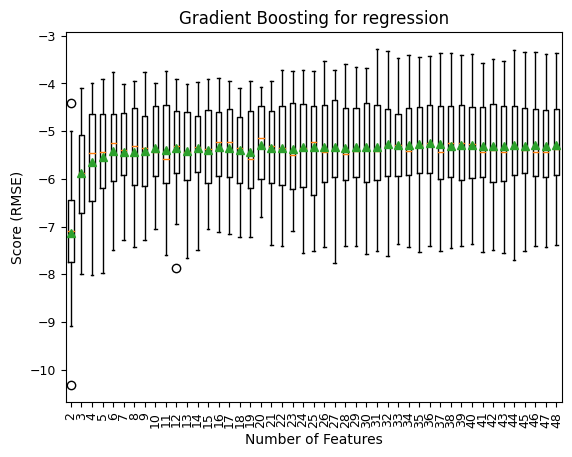

In [19]:

pyplot.boxplot(
    list(result_chart["result_list"]),
    labels=list(result_chart["Name"]),
    showmeans=True
)

pyplot.title("Gradient Boosting for regression")
pyplot.xlabel("Number of Features")
pyplot.ylabel("Score (RMSE)")
plt.xticks(rotation=90, fontsize=9)
plt.yticks(fontsize=9)
pyplot.show()

# Plot Coorelation Features

In [ ]:
#terra - 13
# df = monthly_dataset[[
#     'aet',
#  'def',
#  'pdsi',
#  'pet',
#  'pr',
#  'ro',
#  'soil',
#  'srad',
#  'tmmx',
#  'tmmn',
#  'vap',
#  'vpd',
#  'vs']]


#Era5 - 15
df = monthly_dataset.drop(['ET_fill',
                           'aet',
                           'def',
                           'pdsi',
                           'pet',
                           'pr',
                           'ro',
                           'soil',
                           'srad',
                           'tmmx',
                           'tmmn',
                           'vap',
                           'vpd',
                           'vs',
                           'Site_ID',
                           'General_classification',
                           'Land_cover_details',
                           'Land_cover_type',
                           'time',
                           'date',
                           "category_encoded_Site_ID",
                           "category_encoded_General_classification",
                           "category_encoded_Land_cover_details",
                           "category_encoded_Land_cover_type"], axis =1)

df = df.rename(columns={'dewpoint_temperature_2m': 'dewT2m',
                        'dewpoint_temperature_2m_max': 'dewT2m_max',
                        'dewpoint_temperature_2m_min': 'dewT2m_min',
                        'leaf_area_index_high_vegetation': 'lai_high',
                        'leaf_area_index_low_vegetation': 'lai_low',
                        'soil_temperature_level_1': 'soilT_1',
                        'soil_temperature_level_2': 'soilT_2',
                        'soil_temperature_level_3': 'soilT_3',
                        'soil_temperature_level_4': 'soilT_4',
                        'surface_net_solar_radiation_max': 'r_max',
                        'surface_net_solar_radiation_sum': 'r_sum',
                        'surface_pressure': 's_pressure',
                        'surface_pressure_max': 's_p_max',
                        'surface_pressure_min': 's_p_min',
                        'surface_sensible_heat_flux_max': 'ss_heat_flux_max',
                        'surface_solar_radiation_downwards_max': 'ss_r_d_max',
                        'surface_thermal_radiation_downwards_max': 'st_r_d_max',
                        'surface_thermal_radiation_downwards_min': 'st_r_d_min',
                        'temperature_2m': 'T_2m',
                        'temperature_2m_max': 'T_2m_max',
                        'temperature_2m_min': 'T_2m_min',
                        'total_precipitation_max': 'pr_max',
                        'u_component_of_wind_10m_max': 'u_wind_10m_max',
                        'v_component_of_wind_10m_max': 'v_wind_10m_max',
                        'volumetric_soil_water_layer_1': 'soil_water_1',
                        'volumetric_soil_water_layer_2': 'soil_water_2',
                        'volumetric_soil_water_layer_3': 'soil_water_3',
                        'volumetric_soil_water_layer_4': 'soil_water_4'})

## Correlation Matrix

In [ ]:
# Function to plot correlation matrix
def plot_correlation_matrix(data, n_features=10):
    # Calculate the correlation matrix
    corr_matrix = data.corr()

    # Get the upper triangle of the correlation matrix
    upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

    # Find the top n_features pairs with the highest absolute correlation
    top_corr = upper.abs().unstack().sort_values(ascending=False).head(n_features)

    # Get unique features from top correlations
    unique_features = list(set(top_corr.index.get_level_values(0)) | set(top_corr.index.get_level_values(1)))

    # Create a subset of the correlation matrix with only the top correlated features
    corr_subset = corr_matrix.loc[unique_features, unique_features]

    # Set up the matplotlib figure
    plt.figure(figsize=(12, 10))

    # Create a heatmap
    sns.heatmap(corr_subset, annot=True, cmap='coolwarm', vmin=-1, vmax=1, center=0)

    plt.title(f'Correlation Matrix of Top {n_features} Correlated Feature Pairs')
    plt.tight_layout()
    plt.show()

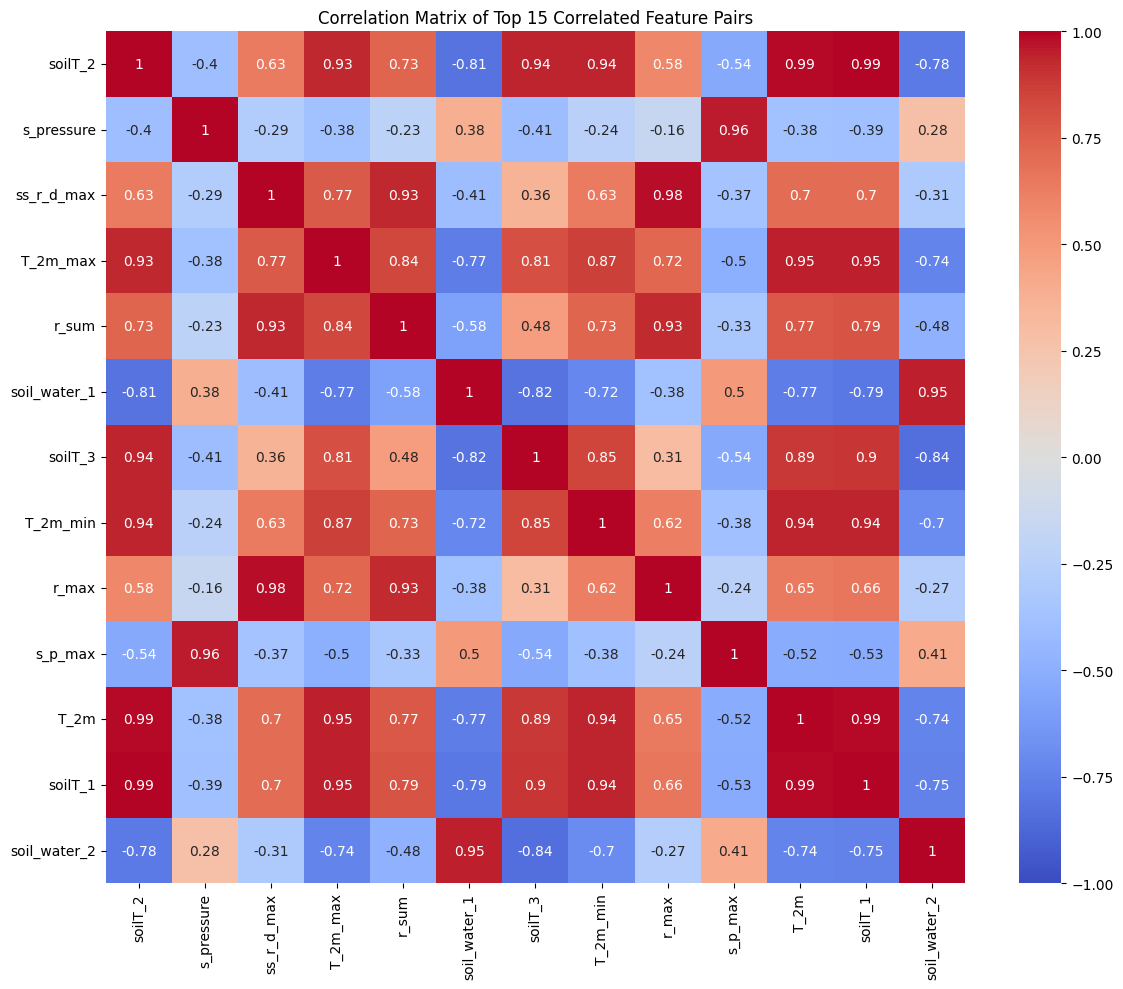

In [ ]:
plot_correlation_matrix(df, n_features=15)

## Scatter Matrix

In [ ]:
def plot_scatter_matrix_highest(data, n_features=5):
    # Calculate the correlation matrix
    corr_matrix = data.corr().abs()

    # Select upper triangle of correlation matrix
    upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

    # Find index of feature columns with correlation greater than 0.5
    to_drop = [column for column in upper.columns if any(upper[column] > 0.5)]


    # Sort to_drop by correlation in descending order
    to_drop = sorted(to_drop, key=lambda x: upper[x].max(), reverse=True)

    # Select top n_features
    top_features = to_drop[:n_features]

    # Create a subset of the dataframe with only the top correlated features
    df_subset = data[top_features]

    # Create the scatter matrix plot
    fig, axes = plt.subplots(nrows=n_features, ncols=n_features, figsize=(12, 10))

    for i, feature1 in enumerate(top_features):
        for j, feature2 in enumerate(top_features):
            ax = axes[i, j]

            if i != j:
                # Scatter plot
                ax.scatter(df_subset[feature2], df_subset[feature1], alpha=0.5)

                # Calculate and plot trend line
                z = np.polyfit(df_subset[feature2], df_subset[feature1], 1)
                p = np.poly1d(z)
                ax.plot(df_subset[feature2], p(df_subset[feature2]), "r--", alpha=0.8)

                if i == n_features - 1:
                    ax.set_xlabel(feature2)
                if j == 0:
                    ax.set_ylabel(feature1)
            else:
                # Histogram on diagonal
                ax.hist(df_subset[feature1], bins=20)

            # Remove top and right spines
            ax.spines['top'].set_visible(False)
            ax.spines['right'].set_visible(False)

            # Remove x ticks for all but bottom row
            if i < n_features - 1:
                ax.set_xticks([])

            # Remove y ticks for all but left column
            if j > 0:
                ax.set_yticks([])

    # Adjust the layout and display the plot
    plt.tight_layout()
    plt.suptitle(f'Scatter Matrix of Top {n_features} Correlated Features', y=1.02)
    plt.show()

def plot_scatter_matrix_lowest(data, n_features=5):
    # Calculate the correlation matrix
    corr_matrix = data.corr().abs()

    # Select upper triangle of correlation matrix
    upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

    # Find index of feature columns with the lowest correlations
    to_keep = [column for column in upper.columns if any(upper[column] < 0.5)]

    # Sort to_keep by correlation in ascending order
    to_keep = sorted(to_keep, key=lambda x: upper[x].max())

    # Select top n_features with the lowest correlations
    lowest_features = to_keep[:n_features]

    # Create a subset of the dataframe with only the lowest correlated features
    df_subset = data[lowest_features]

    # Create the scatter matrix plot
    fig, axes = plt.subplots(nrows=n_features, ncols=n_features, figsize=(12, 10))

    for i, feature1 in enumerate(lowest_features):
        for j, feature2 in enumerate(lowest_features):
            ax = axes[i, j]

            if i != j:
                # Scatter plot
                ax.scatter(df_subset[feature2], df_subset[feature1], alpha=0.5)

                # Calculate and plot trend line
                z = np.polyfit(df_subset[feature2], df_subset[feature1], 1)
                p = np.poly1d(z)
                ax.plot(df_subset[feature2], p(df_subset[feature2]), "r--", alpha=0.8)

                if i == n_features - 1:
                    ax.set_xlabel(feature2)
                if j == 0:
                    ax.set_ylabel(feature1)
            else:
                # Histogram on diagonal
                ax.hist(df_subset[feature1], bins=20)

            # Remove top and right spines
            ax.spines['top'].set_visible(False)
            ax.spines['right'].set_visible(False)

            # Remove x ticks for all but bottom row
            if i < n_features - 1:
                ax.set_xticks([])

            # Remove y ticks for all but left column
            if j > 0:
                ax.set_yticks([])

    # Adjust the layout and display the plot
    plt.tight_layout()
    plt.suptitle(f'Scatter Matrix of Top {n_features} Least Correlated Features', y=1.02)
    plt.show()

### Highest Features

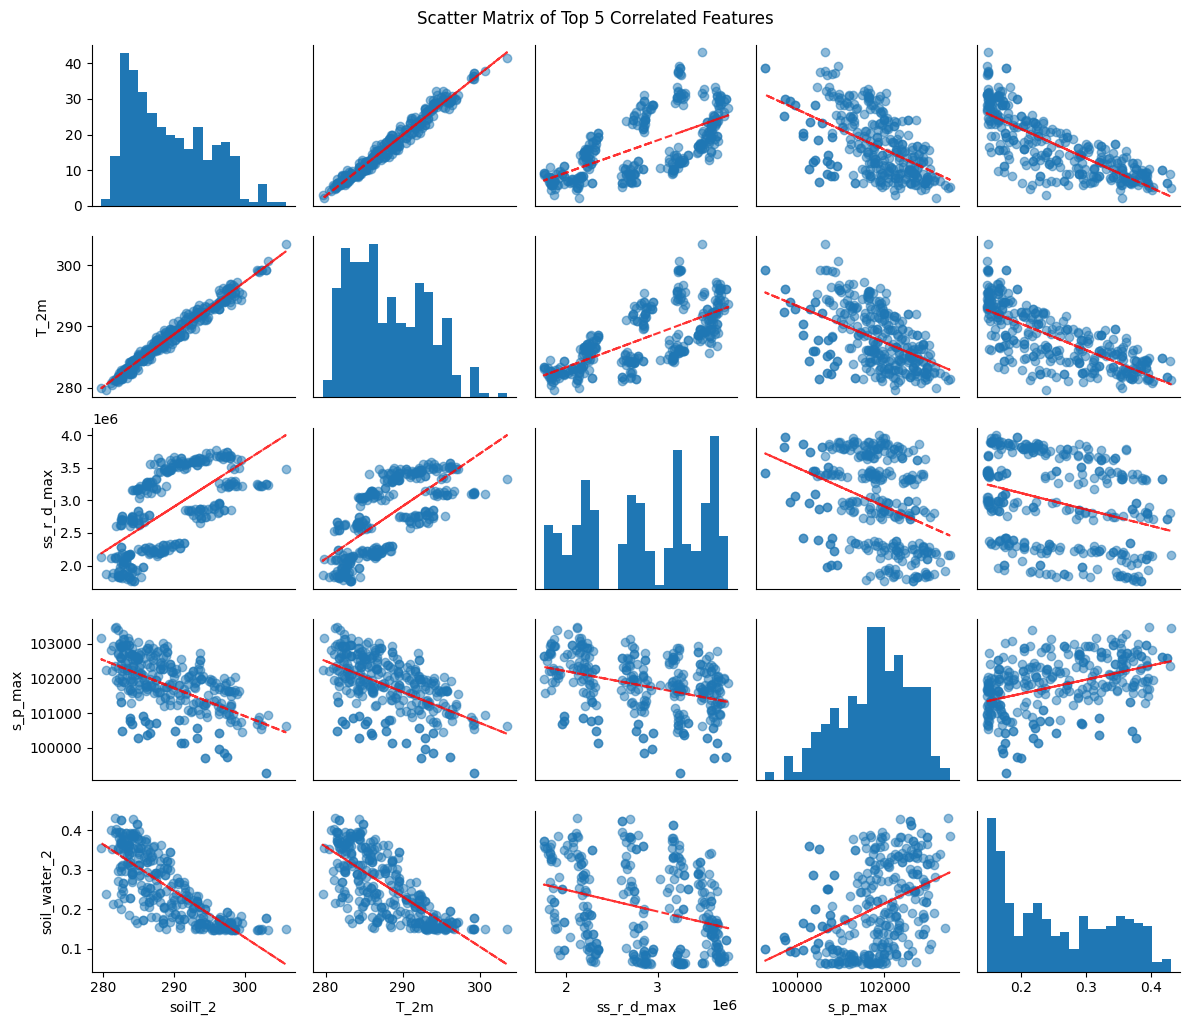

In [ ]:
plot_scatter_matrix_highest(df, n_features=5)

### Lowest Features

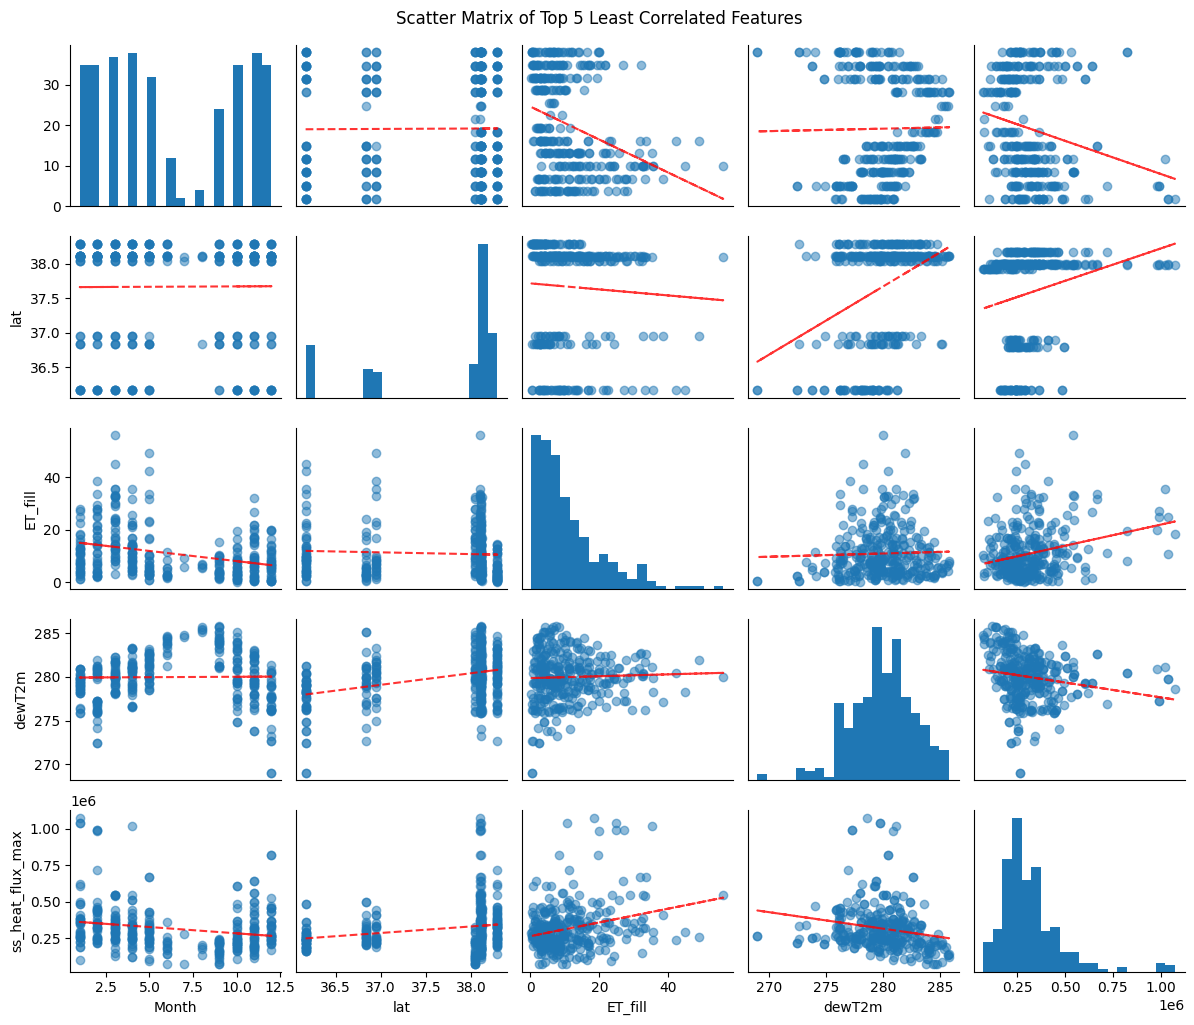

In [ ]:
plot_scatter_matrix_lowest(df, n_features=5)

# RandomForestRegressor

## search best hyperparameters

In [ ]:
param_dist_rf = {
    'max_depth': [2, 4, 6, 8, 10, None],
    'n_estimators': [10, 50, 100, 200],
    'min_samples_split': [2, 3, 4, 5],
    'max_leaf_nodes': [5, 10, 20, None],
    'random_state': [22, None]
}

best_param_rf, best_model_rf = searchcv(
    param_dict =param_dist_rf,
    model = RandomForestRegressor(),
    x = X_train,
    y = y_train,
    cv = KFold(n_splits=10, shuffle=True))


Best parameters found:  {'max_depth': None, 'max_leaf_nodes': 20, 'min_samples_split': 5, 'n_estimators': 50, 'random_state': None}


In [ ]:
def create_model_with_n_features_cv(X, y, n_features):

    # selector = SelectFromModel(
    #     best_model_rf,
    #     max_features=n_features,
    #     threshold=-np.inf
    # )
    selector = RFE(estimator=best_model_rf, n_features_to_select=n_features)
    selector.fit(X, y)
    base_model = RandomForestRegressor(n_estimators=10)

    model = Pipeline(steps=[
        ('feature_selection', selector),
        ('regressor', base_model)
    ])

    selected_features = X.columns[selector.support_]
    cv = KFold(n_splits=10, shuffle=True)


    scores = cross_val_score(model, X, y, scoring='neg_root_mean_squared_error', cv=cv, n_jobs=-1)

    r2 = cross_val_score(model, X, y, scoring='r2', cv=cv, n_jobs=-1)
    rmse_scores = -scores

    return model, rmse_scores, r2, selected_features
result = dict()
# index_result = pd.DataFrame()
# for n_features in range(2,X.shape[1]+1):
n_features = 6
model, rmse_scores, r2, selected_features = create_model_with_n_features_cv(X, y, n_features)
print(f"Model trained with top {n_features} features, Cross-Validation RMSE: {np.mean(rmse_scores):.3f} ± {np.std(rmse_scores):.3f}")
print(f"Model trained with top {n_features} features, Cross-Validation R2: {np.mean(r2):.3f} ± {np.std(r2):.3f}")
print(f"Model trained with top {n_features} features, Features selection: {selected_features}")

result = {
    'Model': [f'RF_{n_features}'],
    'R-squared': [r2],
    'Standard_Deviation for R2': [np.std(r2)],
    'RMSE': [rmse_scores],
    'Standard_Deviation for RMSE': [np.std(rmse_scores)],
    'NRMSE': [rmse_scores / (np.max(y) - np.min(y))],
    'Selected Features': [selected_features]
  }
result
  # rf = pd.DataFrame(result)
  # index_result = pd.concat([index_result, rf], ignore_index=True)

Model trained with top 6 features, Cross-Validation RMSE: 6.241 ± 0.951
Model trained with top 6 features, Cross-Validation R2: 0.502 ± 0.173
Model trained with top 6 features, Features selection: Index(['ppt', 'lat', 'forecast_albedo', 'surface_net_solar_radiation_max',
       'surface_thermal_radiation_downwards_max', 'pdsi'],
      dtype='object')


{'Model': ['RF_6'],
 'R-squared': [array([0.20270157, 0.36687969, 0.60694346, 0.43793909, 0.66613016,
         0.32206895, 0.51698203, 0.43267579, 0.7584773 , 0.71407781])],
 'Standard_Deviation for R2': [0.17264223207341223],
 'RMSE': [array([7.55312718, 5.9149371 , 5.79221269, 6.94529297, 5.50104131,
         7.56238614, 6.55462735, 4.72039859, 6.83433152, 5.03011736])],
 'Standard_Deviation for RMSE': [0.9512046675945639],
 'NRMSE': [array([0.13580558, 0.10635084, 0.10414425, 0.12487669, 0.09890898,
         0.13597205, 0.1178525 , 0.08487299, 0.1228816 , 0.09044174])],
 'Selected Features': [Index(['ppt', 'lat', 'forecast_albedo', 'surface_net_solar_radiation_max',
         'surface_thermal_radiation_downwards_max', 'pdsi'],
        dtype='object')]}

## cross validation

In [ ]:
# Define the KFold object
# kf = KFold(n_splits=5, shuffle=True, random_state=42)
cv_scores_mse = cross_val_score(best_model_rf, X, y, cv=5, scoring='neg_root_mean_squared_error')
cv_scores_mse = cv_scores_mse  # convert to positive MSE scores

print(f"Cross-Validation Scores_mse: {cv_scores_mse}")
print(f"Mean CV Score_mse: {cv_scores_mse.mean()}")

cv_scores_r2 = cross_val_score(best_model_rf, X, y, cv=5, scoring='r2')


print(f"Cross-Validation Scores_r2: {cv_scores_r2}")
print(f"Mean CV Score_r2: {cv_scores_r2.mean()}")

Cross-Validation Scores_mse: [-10.09088539  -5.04024422  -9.26290225  -6.84100048  -5.63650348]
Mean CV Score_mse: -7.374307163104369
Cross-Validation Scores_r2: [0.03333704 0.6134984  0.28888234 0.63963283 0.34079802]
Mean CV Score_r2: 0.3832297239805828


## evaluate model in train and tset

In [ ]:
index_result = pd.DataFrame()
# Define the range of n_features_to_select with a step size
n_features_range = np.arange(2, X.shape[1]+1)  # Adjust the step size as needed
models = dict()
# Loop through each value in the range
for n_features_to_select in tqdm(n_features_range, desc="Feature Selection Progress"):
    selector = RFE(estimator=best_model_rf, n_features_to_select=n_features_to_select)
    selector.fit(X_train, y_train)

    selected_features = X.columns[selector.support_]

    y_train_pred = selector.predict(X_train)
    y_test_pred = selector.predict(X_test)

    # base_model = RandomForestRegressor(n_estimators=10)
    # models[str(n_features_to_select)] = Pipeline(steps=[('s',selector),('m',base_model)])

    rmse_train, nse_train, nrmse_train, r2_train, r_train, std_train, mbe_train = calculate_metrics(actual=y_train, predicted=y_train_pred)
    rmse_test, nse_test, nrmse_test, r2_test, r_test, std_test, mbe_test = calculate_metrics(actual=y_test, predicted=y_test_pred)


    metrics_rf = {
        'Model': [f'RF_{n_features_to_select}'],
        'best_model': [best_model_rf],
        'best_hyperparam' : [best_param_rf],
        'selector' : [selector],
        'X_train' : [X_train],
        'y_train' : [y_train],
        'X_test' : [X_test],
        'y_test' : [y_test],
        'y_train_pred' : [y_train_pred],
        'y_test_pred' : [y_test_pred],
        'R_train': [r_train],
        'R-squared_train': [r2_train],
        'RMSE_train': [rmse_train],
        'NRMSE_train': [nrmse_train],
        'NSE_train': [nse_train],
        'Standard_Deviation_train': [std_train],
        'MBE_train': [mbe_train],
        'R_test': [r_test],
        'R-squared_test': [r2_test],
        'RMSE_test': [rmse_test],
        'NRMSE_test': [nrmse_test],
        'NSE_test': [nse_test],
        'Standard_Deviation_test': [std_test],
        'Selected Features': [selected_features],
        'MBE_test': [mbe_test]
    }

    rf = pd.DataFrame(metrics_rf)
    index_result = pd.concat([index_result, rf], ignore_index=True)

# Identify the optimum n_features_to_select based on the highest R-squared_test
optimum_n_features = index_result.loc[index_result['R-squared_test'].idxmax(), 'Model']
index_result

Feature Selection Progress: 100%|██████████| 47/47 [04:02<00:00,  5.17s/it]


,Model,best_model,best_hyperparam,selector,X_train,y_train,X_test,y_test,y_train_pred,y_test_pred,...,Standard_Deviation_train,MBE_train,R_test,R-squared_test,RMSE_test,NRMSE_test,NSE_test,Standard_Deviation_test,Selected Features,MBE_test
0,RF_2,"(DecisionTreeRegressor(max_features=1.0, max_l...","{'max_depth': None, 'max_leaf_nodes': 20, 'min...",RFE(estimator=RandomForestRegressor(max_leaf_n...,Year Month ppt lat l...,111 7.150572 247 5.450234 233 19.96...,Year Month ppt lat lo...,147 0.686685 279 7.626561 274 21.79...,"[15.418088355995621, 7.036841893521807, 12.973...","[4.878511849233028, 11.970910036820579, 11.862...",...,7.183603,0.027448,0.678736,0.460683,6.843375,0.163500,0.452540,7.108925,"Index(['ppt', 'surface_net_solar_radiation_max...",0.074473
1,RF_3,"(DecisionTreeRegressor(max_features=1.0, max_l...","{'max_depth': None, 'max_leaf_nodes': 20, 'min...",RFE(estimator=RandomForestRegressor(max_leaf_n...,Year Month ppt lat l...,111 7.150572 247 5.450234 233 19.96...,Year Month ppt lat lo...,147 0.686685 279 7.626561 274 21.79...,"[9.835799258856042, 4.338152491652287, 13.0602...","[3.2089285725558536, 11.822459212830779, 12.18...",...,7.549695,-0.012152,0.835635,0.698286,5.098456,0.121811,0.696129,7.983436,"Index(['ppt', 'lat', 'surface_net_solar_radiat...",0.345918
2,RF_4,"(DecisionTreeRegressor(max_features=1.0, max_l...","{'max_depth': None, 'max_leaf_nodes': 20, 'min...",RFE(estimator=RandomForestRegressor(max_leaf_n...,Year Month ppt lat l...,111 7.150572 247 5.450234 233 19.96...,Year Month ppt lat lo...,147 0.686685 279 7.626561 274 21.79...,"[14.078040390258042, 7.046631042894493, 14.027...","[7.426610827362577, 11.92153081312448, 11.8657...",...,7.388543,-0.041371,0.762649,0.581633,5.985993,0.143015,0.581125,6.873875,"Index(['ppt', 'surface_net_solar_radiation_max...",0.105626
3,RF_5,"(DecisionTreeRegressor(max_features=1.0, max_l...","{'max_depth': None, 'max_leaf_nodes': 20, 'min...",RFE(estimator=RandomForestRegressor(max_leaf_n...,Year Month ppt lat l...,111 7.150572 247 5.450234 233 19.96...,Year Month ppt lat lo...,147 0.686685 279 7.626561 274 21.79...,"[9.209581306066454, 6.77774782892478, 16.12297...","[2.9231164356494435, 11.440146979179717, 15.07...",...,7.467550,0.062462,0.815976,0.665817,5.381820,0.128581,0.661413,7.507205,"Index(['ppt', 'lat', 'forecast_albedo', 'surfa...",0.612524
4,RF_6,"(DecisionTreeRegressor(max_features=1.0, max_l...","{'max_depth': None, 'max_leaf_nodes': 20, 'min...",RFE(estimator=RandomForestRegressor(max_leaf_n...,Year Month ppt lat l...,111 7.150572 247 5.450234 233 19.96...,Year Month ppt lat lo...,147 0.686685 279 7.626561 274 21.79...,"[12.30078002284596, 6.420120973035324, 14.8490...","[6.555209806901747, 10.34321775974906, 12.6010...",...,7.113241,-0.089482,0.772887,0.597355,5.878711,0.140452,0.596005,6.831709,"Index(['ppt', 'leaf_area_index_high_vegetation...",0.123152
5,RF_7,"(DecisionTreeRegressor(max_features=1.0, max_l...","{'max_depth': None, 'max_leaf_nodes': 20, 'min...",RFE(estimator=RandomForestRegressor(max_leaf_n...,Year Month ppt lat l...,111 7.150572 247 5.450234 233 19.96...,Year Month ppt lat lo...,147 0.686685 279 7.626561 274 21.79...,"[10.667738780120239, 6.814065048496471, 15.798...","[3.1331522588432326, 10.673479048542111, 13.41...",...,7.498808,0.024445,0.826093,0.682430,5.231909,0.124999,0.680013,7.661683,"Index(['ppt', 'lat', 'forecast_albedo', 'leaf_...",0.454244
6,RF_8,"(DecisionTreeRegressor(max_features=1.0, max_l...","{'max_depth': None, 'max_leaf_nodes': 20, 'min...",RFE(estimator=RandomForestRegressor(max_leaf_n...,Year Month ppt lat l...,111 7.150572 247 5.450234 233 19.96...,Year Month ppt lat lo...,147 0.686685 279 7.626561 274 21.79...,"[8.10946730142508, 7.55637687373444, 16.531866...","[3.998861715352488, 10.478157677012817, 12.355...",...,7.429651,0.063636,0.803124,0.645008,5.552202,0.132651,0.639635,7.683292,"Index(['ppt', 'lat', 'forecast_albedo', 'leaf_...",0.628087
7,RF_9,"(DecisionTreeRegressor(max_features=1.0, max_l

In [ ]:
index_result.to_csv('/content/drive/MyDrive/EC_Tower/result/index_rf28oct_edited.csv')

In [ ]:
index_result = pd.read_csv('/content/drive/MyDrive/EC_Tower/result/index_rf28oct_edited.csv')

## plot

### train

In [ ]:
fig = px.scatter(
    x = y_train_pred,
    y = y_train,
)

fig.add_shape(
    type='line',
    x0 = 0,
    y0 = 0,
    x1 = 60,
    y1 = 60,
    line = dict(
        color = 'Red',
    )
)

fig.update_layout(
    autosize = False,
    width = 600,
    height = 600,
    # xaxis_range = [0, 12],
    # yaxis_range = [0, 12],
    xaxis_title = dict(text = 'ET Predicted'),
    yaxis_title = dict(text = 'ET')
)

fig.show()

### test

In [ ]:
fig = px.scatter(
    x = numbers,
    y =list(y_test),
)

fig.add_shape(
    type='line',
    x0 = 0,
    y0 = 0,
    x1 = 50,
    y1 = 50,
    line = dict(
        color = 'Red',
    )
)

fig.update_layout(
    autosize = False,
    width = 600,
    height = 600,
    # xaxis_range = [0, 12],
    # yaxis_range = [0, 12],
    xaxis_title = dict(text = 'ET Predicted'),
    yaxis_title = dict(text = 'ET')
)

fig.show()

# AdaBoostRegressor

## search best hyperparameters

In [ ]:
param_dist_Ada = {'n_estimators': [10, 50, 100, 200],
                  'learning_rate': [0.25, 0.5, 0.75 , 1, 10, 50, 100],
                  'loss': ('linear', 'square', 'exponential')
                  }

best_param_Ada, best_model_Ada = searchcv(
    param_dict = param_dist_Ada,
    model = AdaBoostRegressor(),
    x = X_train,
    y = y_train,
    cv = KFold(n_splits=10, shuffle=True))

Best parameters found:  {'learning_rate': 0.25, 'loss': 'linear', 'n_estimators': 50}


## cross validation

In [ ]:
# Define the KFold object
# kf = KFold(n_splits=5, shuffle=True, random_state=42)
cv_scores_mse = cross_val_score(best_model_Ada, X, y, cv=5, scoring='neg_mean_squared_error')
cv_scores_mse = -cv_scores_mse  # convert to positive MSE scores

print(f"Cross-Validation Scores_mse: {cv_scores_mse}")
print(f"Mean CV Score_mse: {cv_scores_mse.mean()}")

cv_scores_r2 = cross_val_score(best_model_Ada, X, y, cv=5, scoring='r2')


print(f"Cross-Validation Scores_r2: {cv_scores_r2}")
print(f"Mean CV Score_r2: {cv_scores_r2.mean()}")

Cross-Validation Scores_mse: [107.08674647  32.81309773  98.45246932  28.60023765  27.16342949]
Mean CV Score_mse: 58.82319613181187
Cross-Validation Scores_r2: [0.11453906 0.39667996 0.2436771  0.62317886 0.32678259]
Mean CV Score_r2: 0.3409715133560711


## evaluate model in train and tset

In [ ]:
index_result = pd.DataFrame()
# Define the range of n_features_to_select with a step size
n_features_range = np.arange(2, X.shape[1]+1)  # Adjust the step size as needed
models = dict()
# Loop through each value in the range
for n_features_to_select in tqdm(n_features_range, desc="Feature Selection Progress"):
    selector = RFE(estimator=best_model_Ada, n_features_to_select=n_features_to_select)
    selector.fit(X_train, y_train)

    selected_features = X.columns[selector.support_]

    y_train_pred = selector.predict(X_train)
    y_test_pred = selector.predict(X_test)

    rmse_train, nse_train, nrmse_train, r2_train, r_train, std_train, mbe_train = calculate_metrics(actual=y_train, predicted=y_train_pred)
    rmse_test, nse_test, nrmse_test, r2_test, r_test, std_test, mbe_test = calculate_metrics(actual=y_test, predicted=y_test_pred)

    metrics_Ada = {
        'Model': [f'Ada_{n_features_to_select}'],
        'best_model': [best_model_Ada],
        'best_hyperparam' : [best_model_Ada],
        'selector' : [selector],
        'X_train' : [X_train],
        'y_train' : [y_train],
        'X_test' : [X_test],
        'y_test' : [y_test],
        'y_train_pred' : [y_train_pred],
        'y_test_pred' : [y_test_pred],
        'R_train': [r_train],
        'R-squared_train': [r2_train],
        'RMSE_train': [rmse_train],
        'NRMSE_train': [nrmse_train],
        'NSE_train': [nse_train],
        'Standard_Deviation_train': [std_train],
        'MBE_train': [mbe_train],
        'R_test': [r_test],
        'R-squared_test': [r2_test],
        'RMSE_test': [rmse_test],
        'NRMSE_test': [nrmse_test],
        'NSE_test': [nse_test],
        'Standard_Deviation_test': [std_test],
        'Selected Features': [selected_features],
        'MBE_test': [mbe_test]
    }

    Ada = pd.DataFrame(metrics_Ada)
    index_result = pd.concat([index_result, Ada], ignore_index=True)

# Identify the optimum n_features_to_select based on the highest R-squared_test
optimum_n_features = index_result.loc[index_result['R-squared_test'].idxmax(), 'Model']
index_result

Feature Selection Progress: 100%|██████████| 47/47 [03:11<00:00,  4.08s/it]


,Model,best_model,best_hyperparam,selector,X_train,y_train,X_test,y_test,y_train_pred,y_test_pred,...,Standard_Deviation_train,MBE_train,R_test,R-squared_test,RMSE_test,NRMSE_test,NSE_test,Standard_Deviation_test,Selected Features,MBE_test
0,Ada_2,"(DecisionTreeRegressor(max_depth=3, random_sta...","(DecisionTreeRegressor(max_depth=3, random_sta...",RFE(estimator=AdaBoostRegressor(learning_rate=...,Year Month ppt lat l...,111 7.150572 247 5.450234 233 19.96...,Year Month ppt lat lo...,147 0.686685 279 7.626561 274 21.79...,"[17.319806720500242, 6.741751146849118, 18.610...","[6.032716310044758, 10.729119898929902, 9.2116...",...,6.192973,0.561911,0.661098,0.437050,6.943716,0.165897,0.436367,6.260473,"Index(['ppt', 'surface_thermal_radiation_downw...",0.192554
1,Ada_3,"(DecisionTreeRegressor(max_depth=3, random_sta...","(DecisionTreeRegressor(max_depth=3, random_sta...",RFE(estimator=AdaBoostRegressor(learning_rate=...,Year Month ppt lat l...,111 7.150572 247 5.450234 233 19.96...,Year Month ppt lat lo...,147 0.686685 279 7.626561 274 21.79...,"[17.572293710920427, 7.355377299015467, 19.030...","[6.60148585232539, 10.547608604715673, 9.48529...",...,6.265432,0.993106,0.675585,0.456416,6.840930,0.163441,0.452931,6.139613,"Index(['ppt', 'surface_thermal_radiation_downw...",0.535031
2,Ada_4,"(DecisionTreeRegressor(max_depth=3, random_sta...","(DecisionTreeRegressor(max_depth=3, random_sta...",RFE(estimator=AdaBoostRegressor(learning_rate=...,Year Month ppt lat l...,111 7.150572 247 5.450234 233 19.96...,Year Month ppt lat lo...,147 0.686685 279 7.626561 274 21.79...,"[16.638738229111713, 6.49491726174731, 13.0413...","[5.169559649293274, 14.125474981510651, 13.294...",...,6.407274,1.121955,0.791382,0.626285,5.938196,0.141874,0.587787,5.899019,"Index(['ppt', 'lat', 'surface_net_solar_radiat...",1.129390
3,Ada_5,"(DecisionTreeRegressor(max_depth=3, random_sta...","(DecisionTreeRegressor(max_depth=3, random_sta...",RFE(estimator=AdaBoostRegressor(learning_rate=...,Year Month ppt lat l...,111 7.150572 247 5.450234 233 19.96...,Year Month ppt lat lo...,147 0.686685 279 7.626561 274 21.79...,"[14.881446631265502, 5.602545755200372, 14.159...","[4.663141052014067, 14.13045408415459, 12.3603...",...,6.580808,1.183447,0.768256,0.590217,6.087669,0.145445,0.566774,6.723015,"Index(['ppt', 'lat', 'surface_net_solar_radiat...",1.363449
4,Ada_6,"(DecisionTreeRegressor(max_depth=3, random_sta...","(DecisionTreeRegressor(max_depth=3, random_sta...",RFE(estimator=AdaBoostRegressor(learning_rate=...,Year Month ppt lat l...,111 7.150572 247 5.450234 233 19.96...,Year Month ppt lat lo...,147 0.686685 279 7.626561 274 21.79...,"[13.175297510570442, 5.61358216874944, 12.3029...","[4.920430824633412, 13.291541041846857, 11.837...",...,6.486380,0.799281,0.796949,0.635128,5.770181,0.137859,0.610784,6.181689,"Index(['ppt', 'lat', 'surface_net_solar_radiat...",0.817401
5,Ada_7,"(DecisionTreeRegressor(max_depth=3, random_sta...","(DecisionTreeRegressor(max_depth=3, random_sta...",RFE(estimator=AdaBoostRegressor(learning_rate=...,Year Month ppt lat l...,111 7.150572 247 5.450234 233 19.96...,Year Month ppt lat lo...,147 0.686685 279 7.626561 274 21.79...,"[14.460824105530348, 7.59066654107675, 12.3749...","[7.578656173786913, 14.889793372239815, 10.088...",...,6.625426,1.025033,0.770120,0.593085,6.078858,0.145234,0.568027,6.158162,"Index(['ppt', 'lat', 'soil_temperature_level_4...",1.101340
6,Ada_8,"(DecisionTreeRegressor(max_depth=3, random_sta...","(DecisionTreeRegressor(max_depth=3, random_sta...",RFE(estimator=AdaBoostRegressor(learning_rate=...,Year Month ppt lat l...,111 7.150572 247 5.450234 233 19.96...,Year Month ppt lat lo...,147 0.686685 279 7.626561 274 21.79...,"[13.849704751169275, 6.853525721890489, 12.554...","[5.841929673492584, 14.234230086785251, 9.9400...",...,6.703109,0.953825,0.758537,0.575379,6.166811,0.147336,0.555437,6.271591,"Index(['ppt', 'lat', 'soil_temperature_level_4...",1.073412
7,Ada_9,"(DecisionTreeRegressor(max_depth=3, rando

## plot

### train

In [ ]:
fig = px.scatter(
    x = y_train_pred,
    y = y_train,
)

fig.add_shape(
    type='line',
    x0 = 0,
    y0 = 0,
    x1 = 60,
    y1 = 60,
    line = dict(
        color = 'Red',
    )
)

fig.update_layout(
    autosize = False,
    width = 600,
    height = 600,
    # xaxis_range = [0, 12],
    # yaxis_range = [0, 12],
    xaxis_title = dict(text = 'ET Predicted'),
    yaxis_title = dict(text = 'ET')
)

fig.show()

### test

In [ ]:
fig = px.scatter(
    x = y_test_pred,
    y = y_test,
)

fig.add_shape(
    type='line',
    x0 = 0,
    y0 = 0,
    x1 = 60,
    y1 = 60,
    line = dict(
        color = 'Red',
    )
)

fig.update_layout(
    autosize = False,
    width = 600,
    height = 600,
    # xaxis_range = [0, 12],
    # yaxis_range = [0, 12],
    xaxis_title = dict(text = 'ET Predicted'),
    yaxis_title = dict(text = 'ET')
)

fig.show()

# BaggingRegressor

## search best hyperparameters

In [ ]:
param_dist_Bagging = {'n_estimators': [10, 50, 100, 200],
                      'max_samples' : [0.2, 0.5, 0.75, 1],
                      'max_features': [0.5, 0.75, 1],
                      'bootstrap':[True, False]}



best_param_Bagging, best_model_Bagging = searchcv(
    param_dict = param_dist_Bagging,
    model = BaggingRegressor(),
    x = X_train,
    y = y_train,
    cv = KFold(n_splits=10, shuffle=True))

Best parameters found:  {'bootstrap': False, 'max_features': 0.75, 'max_samples': 0.75, 'n_estimators': 100}


## cross validation

In [ ]:
# Define the KFold object
# kf = KFold(n_splits=5, shuffle=True, random_state=42)
cv_scores_mse = cross_val_score(best_model_Bagging, X, y, cv=5, scoring='neg_mean_squared_error')
cv_scores_mse = -cv_scores_mse  # convert to positive MSE scores

print(f"Cross-Validation Scores_mse: {cv_scores_mse}")
print(f"Mean CV Score_mse: {cv_scores_mse.mean()}")

cv_scores_r2 = cross_val_score(best_model_Bagging, X, y, cv=5, scoring='r2')


print(f"Cross-Validation Scores_r2: {cv_scores_r2}")
print(f"Mean CV Score_r2: {cv_scores_r2.mean()}")

Cross-Validation Scores_mse: [101.10185848  21.9176078   79.91669334  30.72985267  26.7305068 ]
Mean CV Score_mse: 52.079303817411684
Cross-Validation Scores_r2: [0.1312167  0.65926142 0.35877986 0.61327164 0.40654488]
Mean CV Score_r2: 0.4338149001341793


## evaluate model in train and tset

In [ ]:
# Define the range of n_features_to_select with a step size
n_features_range = np.arange(2, X.shape[1]+1)  # Adjust the step size as needed

# Loop through each value in the range
for n_features_to_select in tqdm(n_features_range, desc="Feature Selection Progress"):
    pipeline = Pipeline([
    ('feature_selection', SelectKBest(score_func=f_regression, k = n_features_to_select)),
    ('regressor', best_model_Bagging)
    ])
    pipeline.fit(X_train, y_train)

    y_train_pred = pipeline.predict(X_train)

    # Get the boolean mask of selected features
    selected_features_mask = pipeline.named_steps['feature_selection'].get_support()

    # Get the feature names
    feature_names = X.columns
    # Print the selected feature names
    selected_features = feature_names[selected_features_mask]


    y_test_pred = pipeline.predict(X_test)

    print('Selected Features: ', selected_features)

    rmse_train, nse_train, nrmse_train, r2_train, r_train, std_train, mbe_train = calculate_metrics(actual=y_train, predicted=y_train_pred)
    rmse_test, nse_test, nrmse_test, r2_test, r_test, std_test, mbe_test = calculate_metrics(actual=y_test, predicted=y_test_pred)

    metrics_bagging = {
        'Model': [f'Bagging_{n_features_to_select}'],
        'best_model': [best_model_Bagging],
        'best_hyperparam' : [best_param_Bagging],
        'selector' : [selector],
        'X_train' : [X_train],
        'y_train' : [y_train],
        'X_test' : [X_test],
        'y_test' : [y_test],
        'y_train_pred' : [y_train_pred],
        'y_test_pred' : [y_test_pred],
        'R_train': [r_train],
        'R-squared_train': [r2_train],
        'RMSE_train': [rmse_train],
        'NRMSE_train': [nrmse_train],
        'NSE_train': [nse_train],
        'Standard_Deviation_train': [std_train],
        'MBE_train': [mbe_train],
        'R_test': [r_test],
        'R-squared_test': [r2_test],
        'RMSE_test': [rmse_test],
        'NRMSE_test': [nrmse_test],
        'NSE_test': [nse_test],
        'Standard_Deviation_test': [std_test],
        'Selected Features': [selected_features],
        'MBE_test': [mbe_test]
    }

    bagging = pd.DataFrame(metrics_bagging)
    index_result = pd.concat([index_result, bagging], ignore_index=True)

# Identify the optimum n_features_to_select based on the highest R-squared_test
optimum_n_features = index_result.loc[index_result['R-squared_test'].idxmax(), 'Model']
index_result

Feature Selection Progress:   2%|▏         | 1/47 [00:00<00:14,  3.20it/s]

Selected Features:  Index(['ppt', 'volumetric_soil_water_layer_2'], dtype='object')


Feature Selection Progress:   4%|▍         | 2/47 [00:00<00:13,  3.37it/s]

Selected Features:  Index(['ppt', 'volumetric_soil_water_layer_1',
       'volumetric_soil_water_layer_2'],
      dtype='object')


Feature Selection Progress:   6%|▋         | 3/47 [00:00<00:13,  3.32it/s]

...

Feature Selection Progress:  98%|█████████▊| 46/47 [00:24<00:00,  1.49it/s]

Selected Features:  Index(['Year', 'Month', 'ppt', 'lat', 'lon', 'dewpoint_temperature_2m',
       'dewpoint_temperature_2m_min', 'forecast_albedo',
       'leaf_area_index_high_vegetation', 'leaf_area_index_low_vegetation',
       'soil_temperature_level_1', 'soil_temperature_level_2',
       'soil_temperature_level_3', 'soil_temperature_level_4',
       'surface_net_solar_radiation_max', 'surface_net_solar_radiation_sum',
       'surface_pressure', 'surface_pressure_max', 'surface_pressure_min',
       'surface_sensible_heat_flux_max',
       'surface_solar_radiation_downwards_max',
       'surface_thermal_radiation_downwards_max',
       'surface_thermal_radiation_downwards_min', 'temperature_2m',
       'temperature_2m_max', 'temperature_2m_min', 'total_precipitation_max',
       'u_component_of_wind_10m_max', 'v_component_of_wind_10m_max',
       'volumetric_soil_water_layer_1', 'volumetric_soil_water_layer_2',
       'volumetric_soil_water_layer_3', 'volumetric_soil_water_layer_4

Feature Selection Progress: 100%|██████████| 47/47 [00:25<00:00,  1.84it/s]

Selected Features:  Index(['Year', 'Month', 'ppt', 'lat', 'lon', 'dewpoint_temperature_2m',
       'dewpoint_temperature_2m_max', 'dewpoint_temperature_2m_min',
       'forecast_albedo', 'leaf_area_index_high_vegetation',
       'leaf_area_index_low_vegetation', 'soil_temperature_level_1',
       'soil_temperature_level_2', 'soil_temperature_level_3',
       'soil_temperature_level_4', 'surface_net_solar_radiation_max',
       'surface_net_solar_radiation_sum', 'surface_pressure',
       'surface_pressure_max', 'surface_pressure_min',
       'surface_sensible_heat_flux_max',
       'surface_solar_radiation_downwards_max',
       'surface_thermal_radiation_downwards_max',
       'surface_thermal_radiation_downwards_min', 'temperature_2m',
       'temperature_2m_max', 'temperature_2m_min', 'total_precipitation_max',
       'u_component_of_wind_10m_max', 'v_component_of_wind_10m_max',
       'volumetric_soil_water_layer_1', 'volumetric_soil_water_layer_2',
       'volumetric_soil_water_la

,Model,best_model,best_hyperparam,selector,X_train,y_train,X_test,y_test,y_train_pred,y_test_pred,...,Standard_Deviation_train,MBE_train,R_test,R-squared_test,RMSE_test,NRMSE_test,NSE_test,Standard_Deviation_test,Selected Features,MBE_test
0,Ada_2,"(DecisionTreeRegressor(max_depth=3, random_sta...","(DecisionTreeRegressor(max_depth=3, random_sta...",RFE(estimator=AdaBoostRegressor(learning_rate=...,Year Month ppt lat l...,111 7.150572 247 5.450234 233 19.96...,Year Month ppt lat lo...,147 0.686685 279 7.626561 274 21.79...,"[17.319806720500242, 6.741751146849118, 18.610...","[6.032716310044758, 10.729119898929902, 9.2116...",...,6.192973,0.561911,0.661098,0.437050,6.943716,0.165897,0.436367,6.260473,"Index(['ppt', 'surface_thermal_radiation_downw...",0.192554
1,Ada_3,"(DecisionTreeRegressor(max_depth=3, random_sta...","(DecisionTreeRegressor(max_depth=3, random_sta...",RFE(estimator=AdaBoostRegressor(learning_rate=...,Year Month ppt lat l...,111 7.150572 247 5.450234 233 19.96...,Year Month ppt lat lo...,147 0.686685 279 7.626561 274 21.79...,"[17.572293710920427, 7.355377299015467, 19.030...","[6.60148585232539, 10.547608604715673, 9.48529...",...,6.265432,0.993106,0.675585,0.456416,6.840930,0.163441,0.452931,6.139613,"Index(['ppt', 'surface_thermal_radiation_downw...",0.535031
2,Ada_4,"(DecisionTreeRegressor(max_depth=3, random_sta...","(DecisionTreeRegressor(max_depth=3, random_sta...",RFE(estimator=AdaBoostRegressor(learning_rate=...,Year Month ppt lat l...,111 7.150572 247 5.450234 233 19.96...,Year Month ppt lat lo...,147 0.686685 279 7.626561 274 21.79...,"[16.638738229111713, 6.49491726174731, 13.0413...","[5.169559649293274, 14.125474981510651, 13.294...",...,6.407274,1.121955,0.791382,0.626285,5.938196,0.141874,0.587787,5.899019,"Index(['ppt', 'lat', 'surface_net_solar_radiat...",1.129390
3,Ada_5,"(DecisionTreeRegressor(max_depth=3, random_sta...","(DecisionTreeRegressor(max_depth=3, random_sta...",RFE(estimator=AdaBoostRegressor(learning_rate=...,Year Month ppt lat l...,111 7.150572 247 5.450234 233 19.96...,Year Month ppt lat lo...,147 0.686685 279 7.626561 274 21.79...,"[14.881446631265502, 5.602545755200372, 14.159...","[4.663141052014067, 14.13045408415459, 12.3603...",...,6.580808,1.183447,0.768256,0.590217,6.087669,0.145445,0.566774,6.723015,"Index(['ppt', 'lat', 'surface_net_solar_radiat...",1.363449
4,Ada_6,"(DecisionTreeRegressor(max_depth=3, random_sta...","(DecisionTreeRegressor(max_depth=3, random_sta...",RFE(estimator=AdaBoostRegressor(learning_rate=...,Year Month ppt lat l...,111 7.150572 247 5.450234 233 19.96...,Year Month ppt lat lo...,147 0.686685 279 7.626561 274 21.79...,"[13.175297510570442, 5.61358216874944, 12.3029...","[4.920430824633412, 13.291541041846857, 11.837...",...,6.486380,0.799281,0.796949,0.635128,5.770181,0.137859,0.610784,6.181689,"Index(['ppt', 'lat', 'surface_net_solar_radiat...",0.817401
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
89,Bagging_44,(DecisionTreeRegressor(random_state=1637181136...,"{'bootstrap': False, 'max_features': 0.75, 'ma...",RFE(estimator=AdaBoostRegressor(learning_rate=...,Year Month ppt lat l...,111 7.150572 247 5.450234 233 19.96...,Year Month ppt lat lo...,147 0.686685 279 7.626561 274 21.79...,"[9.274748939120888, 6.284741839908466, 18.0366...","[5.227290320730649, 12.612563978743545, 11.803...",...,8.456094,0.078834,0.762080,0.580766,6.003140,0.143425,0.578722,6.942656,"Index(['Year', 'Month', 'ppt', 'lon', 'dewpoin...",0.404628
90,Bagging_45,(DecisionTreeRegressor(random_state=1637181136...,"{'bootstrap': False, 'max_features': 0.75, 'ma...",RFE(estimator=AdaBoostRegressor(learning_rate=...,Year Month ppt lat l...,111 7.150572 247 5.450234 233 19.96...,Year Month ppt lat lo...,147 0.686685 279 7.626561 274 21.79...,"[10.184625782326044, 7.164223463583561, 18.379...","[4.653585720804572, 13.399891355291347, 12.359...",...,8.365577,0.077552,0.779694,0.607922,5.828653,0.139256,0.602856,7.092047,"Index(['Year',

## plot

### train

In [ ]:
fig = px.scatter(
    x = y_train_pred,
    y = y_train,
)

fig.add_shape(
    type='line',
    x0 = 0,
    y0 = 0,
    x1 = 60,
    y1 = 60,
    line = dict(
        color = 'Red',
    )
)

fig.update_layout(
    autosize = False,
    width = 600,
    height = 600,
    # xaxis_range = [0, 12],
    # yaxis_range = [0, 12],
    xaxis_title = dict(text = 'ET Predicted'),
    yaxis_title = dict(text = 'ET')
)

fig.show()

### test

In [ ]:
fig = px.scatter(
    x = y_test_pred,
    y = y_test,
)

fig.add_shape(
    type='line',
    x0 = 0,
    y0 = 0,
    x1 = 60,
    y1 = 60,
    line = dict(
        color = 'Red',
    )
)

fig.update_layout(
    autosize = False,
    width = 600,
    height = 600,
    # xaxis_range = [0, 12],
    # yaxis_range = [0, 12],
    xaxis_title = dict(text = 'ET Predicted'),
    yaxis_title = dict(text = 'ET')
)

fig.show()

# ExtraTreesRegressor

## search best hyperparameters

In [ ]:
param_dist_ExtraTrees = {
    'n_estimators': [10, 50, 100, 200],
    "max_features": ["auto", "sqrt", "log2", 0.5, 1, 100],
    'max_depth': [2, 4, 6, 8, 10, None],
    'min_samples_split': [2, 3, 4, 5],
    "min_impurity_decrease": [0, 0.1, 0.2],
    "bootstrap": [True, False]
}

best_param_ExtraTrees, best_model_ExtraTrees = searchcv(
    param_dict = param_dist_ExtraTrees,
    model = ExtraTreesRegressor(),
    x = X_train,
    y = y_train,
    cv = KFold(n_splits=10, shuffle=True))

/usr/local/lib/python3.10/dist-packages/sklearn/model_selection/_validation.py:540: FitFailedWarning:


5760 fits failed out of a total of 34560.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
2462 fits failed with the following error:
Traceback (most recent call last):
  File "/usr/local/lib/python3.10/dist-packages/sklearn/model_selection/_validation.py", line 888, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/usr/local/lib/python3.10/dist-packages/sklearn/base.py", line 1466, in wrapper
    estimator._validate_params()
  File "/usr/local/lib/python3.10/dist-packages/sklearn/base.py", line 666, in _validate_params
    validate_parameter_constraints(
  File "/usr/local/lib/python3.10/dist-packages/sklearn

Best parameters found:  {'bootstrap': True, 'max_depth': 10, 'max_features': 0.5, 'min_impurity_decrease': 0.1, 'min_samples_split': 5, 'n_estimators': 50}


## cross validation

In [ ]:
# Define the KFold object
# kf = KFold(n_splits=5, shuffle=True, random_state=42)
cv_scores_mse = cross_val_score(best_model_ExtraTrees, X, y, cv=5, scoring='neg_mean_squared_error')
cv_scores_mse = -cv_scores_mse  # convert to positive MSE scores

print(f"Cross-Validation Scores_mse: {cv_scores_mse}")
print(f"Mean CV Score_mse: {cv_scores_mse.mean()}")

cv_scores_r2 = cross_val_score(best_model_ExtraTrees, X, y, cv=5, scoring='r2')


print(f"Cross-Validation Scores_r2: {cv_scores_r2}")
print(f"Mean CV Score_r2: {cv_scores_r2.mean()}")

Cross-Validation Scores_mse: [124.59228008  31.84978748  81.72719306  35.18113192  31.59803476]
Mean CV Score_mse: 60.98968545729921
Cross-Validation Scores_r2: [-0.12217711  0.49427568  0.34387133  0.56124775  0.34699963]
Mean CV Score_r2: 0.32484345439623813


## evaluate model in train and tset

In [ ]:
# Define the range of n_features_to_select with a step size
n_features_range = np.arange(2, X.shape[1]+1)  # Adjust the step size as needed

# Loop through each value in the range
for n_features_to_select in tqdm(n_features_range, desc="Feature Selection Progress"):
    selector = RFE(estimator=best_model_ExtraTrees, n_features_to_select=n_features_to_select)
    selector.fit(X_train, y_train)

    selected_features = X.columns[selector.support_]

    y_train_pred = selector.predict(X_train)
    y_test_pred = selector.predict(X_test)

    rmse_train, nse_train, nrmse_train, r2_train, r_train, std_train, mbe_train = calculate_metrics(actual=y_train, predicted=y_train_pred)
    rmse_test, nse_test, nrmse_test, r2_test, r_test, std_test, mbe_test = calculate_metrics(actual=y_test, predicted=y_test_pred)

    metrics_Etratrees = {
        'Model': [f'Etratrees_{n_features_to_select}'],
        'best_model': [best_model_ExtraTrees],
        'best_hyperparam' : [best_param_ExtraTrees],
        'selector' : [selector],
        'X_train' : [X_train],
        'y_train' : [y_train],
        'X_test' : [X_test],
        'y_test' : [y_test],
        'y_train_pred' : [y_train_pred],
        'y_test_pred' : [y_test_pred],
        'R_train': [r_train],
        'R-squared_train': [r2_train],
        'RMSE_train': [rmse_train],
        'NRMSE_train': [nrmse_train],
        'NSE_train': [nse_train],
        'Standard_Deviation_train': [std_train],
        'MBE_train': [mbe_train],
        'R_test': [r_test],
        'R-squared_test': [r2_test],
        'RMSE_test': [rmse_test],
        'NRMSE_test': [nrmse_test],
        'NSE_test': [nse_test],
        'Standard_Deviation_test': [std_test],
        'Selected Features': [selected_features],
        'MBE_test': [mbe_test]
    }

    Etratrees = pd.DataFrame(metrics_Etratrees)
    index_result = pd.concat([index_result, Etratrees], ignore_index=True)

# Identify the optimum n_features_to_select based on the highest R-squared_test
optimum_n_features = index_result.loc[index_result['R-squared_test'].idxmax(), 'Model']
index_result

Feature Selection Progress: 100%|██████████| 47/47 [02:01<00:00,  2.58s/it]


,Model,best_model,best_hyperparam,selector,X_train,y_train,X_test,y_test,y_train_pred,y_test_pred,...,Standard_Deviation_train,MBE_train,R_test,R-squared_test,RMSE_test,NRMSE_test,NSE_test,Standard_Deviation_test,Selected Features,MBE_test
0,Ada_2,"(DecisionTreeRegressor(max_depth=3, random_sta...","(DecisionTreeRegressor(max_depth=3, random_sta...",RFE(estimator=AdaBoostRegressor(learning_rate=...,Year Month ppt lat l...,111 7.150572 247 5.450234 233 19.96...,Year Month ppt lat lo...,147 0.686685 279 7.626561 274 21.79...,"[17.319806720500242, 6.741751146849118, 18.610...","[6.032716310044758, 10.729119898929902, 9.2116...",...,6.192973,0.561911,0.661098,0.437050,6.943716,0.165897,0.436367,6.260473,"Index(['ppt', 'surface_thermal_radiation_downw...",0.192554
1,Ada_3,"(DecisionTreeRegressor(max_depth=3, random_sta...","(DecisionTreeRegressor(max_depth=3, random_sta...",RFE(estimator=AdaBoostRegressor(learning_rate=...,Year Month ppt lat l...,111 7.150572 247 5.450234 233 19.96...,Year Month ppt lat lo...,147 0.686685 279 7.626561 274 21.79...,"[17.572293710920427, 7.355377299015467, 19.030...","[6.60148585232539, 10.547608604715673, 9.48529...",...,6.265432,0.993106,0.675585,0.456416,6.840930,0.163441,0.452931,6.139613,"Index(['ppt', 'surface_thermal_radiation_downw...",0.535031
2,Ada_4,"(DecisionTreeRegressor(max_depth=3, random_sta...","(DecisionTreeRegressor(max_depth=3, random_sta...",RFE(estimator=AdaBoostRegressor(learning_rate=...,Year Month ppt lat l...,111 7.150572 247 5.450234 233 19.96...,Year Month ppt lat lo...,147 0.686685 279 7.626561 274 21.79...,"[16.638738229111713, 6.49491726174731, 13.0413...","[5.169559649293274, 14.125474981510651, 13.294...",...,6.407274,1.121955,0.791382,0.626285,5.938196,0.141874,0.587787,5.899019,"Index(['ppt', 'lat', 'surface_net_solar_radiat...",1.129390
3,Ada_5,"(DecisionTreeRegressor(max_depth=3, random_sta...","(DecisionTreeRegressor(max_depth=3, random_sta...",RFE(estimator=AdaBoostRegressor(learning_rate=...,Year Month ppt lat l...,111 7.150572 247 5.450234 233 19.96...,Year Month ppt lat lo...,147 0.686685 279 7.626561 274 21.79...,"[14.881446631265502, 5.602545755200372, 14.159...","[4.663141052014067, 14.13045408415459, 12.3603...",...,6.580808,1.183447,0.768256,0.590217,6.087669,0.145445,0.566774,6.723015,"Index(['ppt', 'lat', 'surface_net_solar_radiat...",1.363449
4,Ada_6,"(DecisionTreeRegressor(max_depth=3, random_sta...","(DecisionTreeRegressor(max_depth=3, random_sta...",RFE(estimator=AdaBoostRegressor(learning_rate=...,Year Month ppt lat l...,111 7.150572 247 5.450234 233 19.96...,Year Month ppt lat lo...,147 0.686685 279 7.626561 274 21.79...,"[13.175297510570442, 5.61358216874944, 12.3029...","[4.920430824633412, 13.291541041846857, 11.837...",...,6.486380,0.799281,0.796949,0.635128,5.770181,0.137859,0.610784,6.181689,"Index(['ppt', 'lat', 'surface_net_solar_radiat...",0.817401
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
136,Etratrees_44,"(ExtraTreeRegressor(max_depth=10, max_features...","{'bootstrap': True, 'max_depth': 10, 'max_feat...",RFE(estimator=ExtraTreesRegressor(bootstrap=Tr...,Year Month ppt lat l...,111 7.150572 247 5.450234 233 19.96...,Year Month ppt lat lo...,147 0.686685 279 7.626561 274 21.79...,"[7.948118370966253, 8.782248220496086, 17.0728...","[5.66099442097889, 15.409271210363158, 12.9750...",...,7.335110,0.248078,0.797241,0.635594,5.828879,0.139262,0.602825,5.775813,"Index(['Year', 'Month', 'ppt', 'lat', 'lon', '...",0.500046
137,Etratrees_45,"(ExtraTreeRegressor(max_depth=10, max_features...","{'bootstrap': True, 'max_depth': 10, 'max_feat...",RFE(estimator=ExtraTreesRegressor(bootstrap=Tr...,Year Month ppt lat l...,111 7.150572 247 5.450234 233 19.96...,Year Month ppt lat lo...,147 0.686685 279 7.626561 274 21.79...,"[8.161271039616448, 6.290523158680262, 16.4926...","[4.456257358958416, 16.840839268552248, 14.944...",...,7.278596,0.111192,0.805530,0.648879,5.680939,0.135727,0.622730,6.049727,"Inde

## plot

### train

In [ ]:
fig = px.scatter(
    x = y_train_pred,
    y = y_train,
)

fig.add_shape(
    type='line',
    x0 = 0,
    y0 = 0,
    x1 = 60,
    y1 = 60,
    line = dict(
        color = 'Red',
    )
)

fig.update_layout(
    autosize = False,
    width = 600,
    height = 600,
    # xaxis_range = [0, 12],
    # yaxis_range = [0, 12],
    xaxis_title = dict(text = 'ET Predicted'),
    yaxis_title = dict(text = 'ET')
)

fig.show()

### test

In [ ]:
fig = px.scatter(
    x = y_test_pred,
    y = y_test,
)

fig.add_shape(
    type='line',
    x0 = 0,
    y0 = 0,
    x1 = 60,
    y1 = 60,
    line = dict(
        color = 'Red',
    )
)

fig.update_layout(
    autosize = False,
    width = 600,
    height = 600,
    # xaxis_range = [0, 12],
    # yaxis_range = [0, 12],
    xaxis_title = dict(text = 'ET Predicted'),
    yaxis_title = dict(text = 'ET')
)

fig.show()

# GradientBoostingRegressor

## search best hyperparameters

In [ ]:
param_dist_GB = {'learning_rate': [0.1, 0.25, 0.5, 0.75 , 1, 10, 50, 100],
                 'subsample': [0.25, 0.5, 0.75, 1],
                 'n_estimators': [10, 50, 100, 200],
                 'max_depth': [2, 3, 4, 6, 8, 10, None]}



best_param_GB, best_model_GB = searchcv(
    param_dict = param_dist_GB,
    model = GradientBoostingRegressor(),
    x = X_train,
    y = y_train,
    cv = KFold(n_splits=10, shuffle=True))

/usr/local/lib/python3.10/dist-packages/sklearn/model_selection/_search.py:1103: UserWarning:

One or more of the test scores are non-finite: [ 1.55626660e-001  2.66551651e-001  2.31733730e-001  2.70499591e-001
  2.95137012e-001  4.44139073e-001  4.07727294e-001  4.29978542e-001
  3.34611984e-001  4.13489582e-001  4.34732773e-001  4.18923002e-001
  3.52570088e-001  3.61694830e-001  4.15141060e-001  3.89935572e-001
  1.83267381e-001  2.86744756e-001  3.00587071e-001  3.04602544e-001
  3.62545801e-001  4.25608802e-001  4.44268622e-001  4.02453119e-001
  3.74731819e-001  4.27052665e-001  4.21645173e-001  3.88600762e-001
  3.23280600e-001  3.90269072e-001  4.16613017e-001  3.65923293e-001
  2.73061473e-001  3.42180217e-001  3.65621111e-001  2.89567181e-001
  2.75794829e-001  4.05452158e-001  4.28471526e-001  3.66411610e-001
  3.41908878e-001  4.42899147e-001  4.09474688e-001  3.32922021e-001
  3.10157755e-001  4.69533301e-001  4.14207112e-001  3.39035252e-001
  2.76046957e-001  3.54249335e

Best parameters found:  {'learning_rate': 0.1, 'max_depth': 6, 'n_estimators': 200, 'subsample': 0.75}


## cross validation

In [ ]:
# Define the KFold object
# kf = KFold(n_splits=5, shuffle=True, random_state=42)
cv_scores_mse = cross_val_score(best_model_GB, X, y, cv=5, scoring='neg_mean_squared_error')
cv_scores_mse = -cv_scores_mse  # convert to positive MSE scores

print(f"Cross-Validation Scores_mse: {cv_scores_mse}")
print(f"Mean CV Score_mse: {cv_scores_mse.mean()}")

cv_scores_r2 = cross_val_score(best_model_GB, X, y, cv=5, scoring='r2')


print(f"Cross-Validation Scores_r2: {cv_scores_r2}")
print(f"Mean CV Score_r2: {cv_scores_r2.mean()}")

Cross-Validation Scores_mse: [103.3717807   12.72463665  79.68515702  34.78772746  29.18177473]
Mean CV Score_mse: 51.950215312552814
Cross-Validation Scores_r2: [0.06304133 0.68974703 0.34238713 0.61037319 0.51224954]
Mean CV Score_r2: 0.44355964512999063


## evaluate model in train and tset

In [ ]:
# Define the range of n_features_to_select with a step size
n_features_range = np.arange(2, X.shape[1]+1)  # Adjust the step size as needed

# Loop through each value in the range
for n_features_to_select in tqdm(n_features_range, desc="Feature Selection Progress"):
    selector = RFE(estimator=best_model_GB, n_features_to_select=n_features_to_select)
    selector.fit(X_train, y_train)

    selected_features = X.columns[selector.support_]

    y_train_pred = selector.predict(X_train)
    y_test_pred = selector.predict(X_test)

    rmse_train, nse_train, nrmse_train, r2_train, r_train, std_train, mbe_train = calculate_metrics(actual=y_train, predicted=y_train_pred)
    rmse_test, nse_test, nrmse_test, r2_test, r_test, std_test, mbe_test = calculate_metrics(actual=y_test, predicted=y_test_pred)

    metrics_GB = {
        'Model': [f'GB_{n_features_to_select}'],
        'best_model': [best_model_GB],
        'best_hyperparam' : [best_param_GB],
        'selector' : [selector],
        'X_train' : [X_train],
        'y_train' : [y_train],
        'X_test' : [X_test],
        'y_test' : [y_test],
        'y_train_pred' : [y_train_pred],
        'y_test_pred' : [y_test_pred],
        'R_train': [r_train],
        'R-squared_train': [r2_train],
        'RMSE_train': [rmse_train],
        'NRMSE_train': [nrmse_train],
        'NSE_train': [nse_train],
        'Standard_Deviation_train': [std_train],
        'MBE_train': [mbe_train],
        'R_test': [r_test],
        'R-squared_test': [r2_test],
        'RMSE_test': [rmse_test],
        'NRMSE_test': [nrmse_test],
        'NSE_test': [nse_test],
        'Standard_Deviation_test': [std_test],
        'Selected Features': [selected_features],
        'MBE_test': [mbe_test]
    }

    GB = pd.DataFrame(metrics_GB)
    index_result = pd.concat([index_result, GB], ignore_index=True)

# Identify the optimum n_features_to_select based on the highest R-squared_test
optimum_n_features = index_result.loc[index_result['R-squared_test'].idxmax(), 'Model']
index_result

Feature Selection Progress: 100%|██████████| 47/47 [14:13<00:00, 18.17s/it]


,Model,best_model,best_hyperparam,selector,X_train,y_train,X_test,y_test,y_train_pred,y_test_pred,...,Standard_Deviation_train,MBE_train,R_test,R-squared_test,RMSE_test,NRMSE_test,NSE_test,Standard_Deviation_test,Selected Features,MBE_test
0,Ada_2,"(DecisionTreeRegressor(max_depth=3, random_sta...","(DecisionTreeRegressor(max_depth=3, random_sta...",RFE(estimator=AdaBoostRegressor(learning_rate=...,Year Month ppt lat l...,111 7.150572 247 5.450234 233 19.96...,Year Month ppt lat lo...,147 0.686685 279 7.626561 274 21.79...,"[17.319806720500242, 6.741751146849118, 18.610...","[6.032716310044758, 10.729119898929902, 9.2116...",...,6.192973,0.561911,0.661098,0.437050,6.943716,0.165897,0.436367,6.260473,"Index(['ppt', 'surface_thermal_radiation_downw...",0.192554
1,Ada_3,"(DecisionTreeRegressor(max_depth=3, random_sta...","(DecisionTreeRegressor(max_depth=3, random_sta...",RFE(estimator=AdaBoostRegressor(learning_rate=...,Year Month ppt lat l...,111 7.150572 247 5.450234 233 19.96...,Year Month ppt lat lo...,147 0.686685 279 7.626561 274 21.79...,"[17.572293710920427, 7.355377299015467, 19.030...","[6.60148585232539, 10.547608604715673, 9.48529...",...,6.265432,0.993106,0.675585,0.456416,6.840930,0.163441,0.452931,6.139613,"Index(['ppt', 'surface_thermal_radiation_downw...",0.535031
2,Ada_4,"(DecisionTreeRegressor(max_depth=3, random_sta...","(DecisionTreeRegressor(max_depth=3, random_sta...",RFE(estimator=AdaBoostRegressor(learning_rate=...,Year Month ppt lat l...,111 7.150572 247 5.450234 233 19.96...,Year Month ppt lat lo...,147 0.686685 279 7.626561 274 21.79...,"[16.638738229111713, 6.49491726174731, 13.0413...","[5.169559649293274, 14.125474981510651, 13.294...",...,6.407274,1.121955,0.791382,0.626285,5.938196,0.141874,0.587787,5.899019,"Index(['ppt', 'lat', 'surface_net_solar_radiat...",1.129390
3,Ada_5,"(DecisionTreeRegressor(max_depth=3, random_sta...","(DecisionTreeRegressor(max_depth=3, random_sta...",RFE(estimator=AdaBoostRegressor(learning_rate=...,Year Month ppt lat l...,111 7.150572 247 5.450234 233 19.96...,Year Month ppt lat lo...,147 0.686685 279 7.626561 274 21.79...,"[14.881446631265502, 5.602545755200372, 14.159...","[4.663141052014067, 14.13045408415459, 12.3603...",...,6.580808,1.183447,0.768256,0.590217,6.087669,0.145445,0.566774,6.723015,"Index(['ppt', 'lat', 'surface_net_solar_radiat...",1.363449
4,Ada_6,"(DecisionTreeRegressor(max_depth=3, random_sta...","(DecisionTreeRegressor(max_depth=3, random_sta...",RFE(estimator=AdaBoostRegressor(learning_rate=...,Year Month ppt lat l...,111 7.150572 247 5.450234 233 19.96...,Year Month ppt lat lo...,147 0.686685 279 7.626561 274 21.79...,"[13.175297510570442, 5.61358216874944, 12.3029...","[4.920430824633412, 13.291541041846857, 11.837...",...,6.486380,0.799281,0.796949,0.635128,5.770181,0.137859,0.610784,6.181689,"Index(['ppt', 'lat', 'surface_net_solar_radiat...",0.817401
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
183,GB_44,([DecisionTreeRegressor(criterion='friedman_ms...,"{'learning_rate': 0.1, 'max_depth': 6, 'n_esti...",RFE(estimator=GradientBoostingRegressor(max_de...,Year Month ppt lat l...,111 7.150572 247 5.450234 233 19.96...,Year Month ppt lat lo...,147 0.686685 279 7.626561 274 21.79...,"[7.160533849264955, 5.442674303763611, 19.9525...","[3.087496713760847, 11.767763130782251, 14.525...",...,9.523893,0.000221,0.814556,0.663501,5.418261,0.129451,0.656812,8.213759,"Index(['Year', 'ppt', 'lat', 'lon', 'dewpoint_...",0.331513
184,GB_45,([DecisionTreeRegressor(criterion='friedman_ms...,"{'learning_rate': 0.1, 'max_depth': 6, 'n_esti...",RFE(estimator=GradientBoostingRegressor(max_de...,Year Month ppt lat l...,111 7.150572 247 5.450234 233 19.96...,Year Month ppt lat lo...,147 0.686685 279 7.626561 274 21.79...,"[7.165093004986984, 5.456738605164011, 19.9519...","[2.098449427774721, 11.05001480236396, 14.6296...",...,9.522606,-0.000240,0.835787,0.698540,5.097296,0.121783,0.696267,7.846587,"Index(['Year', 'ppt',

## plot

### train

In [ ]:
fig = px.scatter(
    x = y_train_pred,
    y = y_train,
)

fig.add_shape(
    type='line',
    x0 = 0,
    y0 = 0,
    x1 = 60,
    y1 = 60,
    line = dict(
        color = 'Red',
    )
)

fig.update_layout(
    autosize = False,
    width = 600,
    height = 600,
    # xaxis_range = [0, 12],
    # yaxis_range = [0, 12],
    xaxis_title = dict(text = 'ET Predicted'),
    yaxis_title = dict(text = 'ET')
)

fig.show()

### test

In [ ]:
fig = px.scatter(
    x = y_test_pred,
    y = y_test,
)

fig.add_shape(
    type='line',
    x0 = 0,
    y0 = 0,
    x1 = 60,
    y1 = 60,
    line = dict(
        color = 'Red',
    )
)

fig.update_layout(
    autosize = False,
    width = 600,
    height = 600,
    # xaxis_range = [0, 12],
    # yaxis_range = [0, 12],
    xaxis_title = dict(text = 'ET Predicted'),
    yaxis_title = dict(text = 'ET')
)

fig.show()

# HistGradientBoostingRegressor

## search best hyperparameters

In [ ]:
param_dist_HGB = {'loss': ['least_squares', 'poisson'],
                  'learning_rate': [0.1, 0.25, 0.5, 0.75 , None],
                  'max_iter': [50, 100, 200],
                  'max_depth': [2, 3, 4, 6, 8, 10, None]}



best_param_HGB, best_model_HGB = searchcv(
    param_dict = param_dist_HGB,
    model = HistGradientBoostingRegressor(),
    x = X_train,
    y = y_train,
    cv = KFold(n_splits=10, shuffle=True))

Best parameters found:  {'learning_rate': 0.1, 'loss': 'poisson', 'max_depth': 2, 'max_iter': 200}


/usr/local/lib/python3.10/dist-packages/sklearn/model_selection/_validation.py:540: FitFailedWarning:


1260 fits failed out of a total of 2100.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
436 fits failed with the following error:
Traceback (most recent call last):
  File "/usr/local/lib/python3.10/dist-packages/sklearn/model_selection/_validation.py", line 888, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/usr/local/lib/python3.10/dist-packages/sklearn/base.py", line 1466, in wrapper
    estimator._validate_params()
  File "/usr/local/lib/python3.10/dist-packages/sklearn/base.py", line 666, in _validate_params
    validate_parameter_constraints(
  File "/usr/local/lib/python3.10/dist-packages/sklearn/u

## cross validation

In [ ]:
# Define the KFold object
# kf = KFold(n_splits=5, shuffle=True, random_state=42)
cv_scores_mse = cross_val_score(best_model_HGB, X, y, cv=5, scoring='neg_mean_squared_error')
cv_scores_mse = -cv_scores_mse  # convert to positive MSE scores

print(f"Cross-Validation Scores_mse: {cv_scores_mse}")
print(f"Mean CV Score_mse: {cv_scores_mse.mean()}")

cv_scores_r2 = cross_val_score(best_model_HGB, X, y, cv=5, scoring='r2')


print(f"Cross-Validation Scores_r2: {cv_scores_r2}")
print(f"Mean CV Score_r2: {cv_scores_r2.mean()}")

Cross-Validation Scores_mse: [82.40500424 26.8681817  62.88270554 29.83271646 24.49082095]
Mean CV Score_mse: 45.295885777769584
Cross-Validation Scores_r2: [0.30896284 0.52704032 0.50172391 0.6152441  0.46833621]
Mean CV Score_r2: 0.48426147532202357


## evaluate model in train and tset

In [ ]:
# Define the range of n_features_to_select with a step size
n_features_range = np.arange(2, X.shape[1]+1)  # Adjust the step size as needed

# Loop through each value in the range
for n_features_to_select in tqdm(n_features_range, desc="Feature Selection Progress"):
    pipeline = Pipeline([
    ('feature_selection', SelectKBest(score_func=f_regression, k = n_features_to_select)),
    ('regressor', best_model_HGB)
    ])
    pipeline.fit(X_train, y_train)

    y_train_pred = pipeline.predict(X_train)

    # Get the boolean mask of selected features
    selected_features_mask = pipeline.named_steps['feature_selection'].get_support()

    # Get the feature names
    feature_names = X.columns
    # Print the selected feature names
    selected_features = feature_names[selected_features_mask]


    y_test_pred = pipeline.predict(X_test)

    print('Selected Features: ', selected_features)

    rmse_train, nse_train, nrmse_train, r2_train, r_train, std_train, mbe_train = calculate_metrics(actual=y_train, predicted=y_train_pred)
    rmse_test, nse_test, nrmse_test, r2_test, r_test, std_test, mbe_test = calculate_metrics(actual=y_test, predicted=y_test_pred)

    metrics_HGB = {
        'Model': [f'HGB_{n_features_to_select}'],
        'best_model': [best_model_HGB],
        'best_hyperparam' : [best_param_HGB],
        'selector' : [pipeline],
        'X_train' : [X_train],
        'y_train' : [y_train],
        'X_test' : [X_test],
        'y_test' : [y_test],
        'y_train_pred' : [y_train_pred],
        'y_test_pred' : [y_test_pred],
        'R_train': [r_train],
        'R-squared_train': [r2_train],
        'RMSE_train': [rmse_train],
        'NRMSE_train': [nrmse_train],
        'NSE_train': [nse_train],
        'Standard_Deviation_train': [std_train],
        'MBE_train': [mbe_train],
        'R_test': [r_test],
        'R-squared_test': [r2_test],
        'RMSE_test': [rmse_test],
        'NRMSE_test': [nrmse_test],
        'NSE_test': [nse_test],
        'Standard_Deviation_test': [std_test],
        'Selected Features': [selected_features],
        'MBE_test': [mbe_test]
    }

    HGB = pd.DataFrame(metrics_HGB)
    index_result = pd.concat([index_result, HGB], ignore_index=True)

# Identify the optimum n_features_to_select based on the highest R-squared_test
optimum_n_features = index_result.loc[index_result['R-squared_test'].idxmax(), 'Model']
index_result

Feature Selection Progress:   4%|▍         | 2/47 [00:00<00:05,  8.50it/s]

Selected Features:  Index(['ppt', 'volumetric_soil_water_layer_2'], dtype='object')
Selected Features:  Index(['ppt', 'volumetric_soil_water_layer_1',
       'volumetric_soil_water_layer_2'],
      dtype='object')


Feature Selection Progress:   9%|▊         | 4/47 [00:00<00:05,  8.07it/s]

Selected Features:  Index(['ppt', 'volumetric_soil_water_layer_1', 'volumetric_soil_water_layer_2',
       'volumetric_soil_water_layer_3'],
      dtype='object')
Selected Features:  Index(['ppt', 'v_component_of_wind_10m_max', 'volumetric_soil_water_layer_1',
       'volumetric_soil_water_layer_2', 'volumetric_soil_water_layer_3'],
      dtype='object')


Feature Selection Progress:  13%|█▎        | 6/47 [00:00<00:05,  7.90it/s]

...

Feature Selection Progress:  96%|█████████▌| 45/47 [00:06<00:00,  5.84it/s]

Selected Features:  Index(['Year', 'Month', 'ppt', 'lon', 'dewpoint_temperature_2m',
       'dewpoint_temperature_2m_min', 'forecast_albedo',
       'leaf_area_index_high_vegetation', 'leaf_area_index_low_vegetation',
       'soil_temperature_level_1', 'soil_temperature_level_2',
       'soil_temperature_level_3', 'soil_temperature_level_4',
       'surface_net_solar_radiation_max', 'surface_net_solar_radiation_sum',
       'surface_pressure', 'surface_pressure_max', 'surface_pressure_min',
       'surface_sensible_heat_flux_max',
       'surface_solar_radiation_downwards_max',
       'surface_thermal_radiation_downwards_min', 'temperature_2m',
       'temperature_2m_max', 'temperature_2m_min', 'total_precipitation_max',
       'u_component_of_wind_10m_max', 'v_component_of_wind_10m_max',
       'volumetric_soil_water_layer_1', 'volumetric_soil_water_layer_2',
       'volumetric_soil_water_layer_3', 'volumetric_soil_water_layer_4',
       'pdsi', 'pr', 'ro', 'soil', 'srad', 'tmmx', 'tm

Feature Selection Progress: 100%|██████████| 47/47 [00:07<00:00,  6.48it/s]

Selected Features:  Index(['Year', 'Month', 'ppt', 'lat', 'lon', 'dewpoint_temperature_2m',
       'dewpoint_temperature_2m_min', 'forecast_albedo',
       'leaf_area_index_high_vegetation', 'leaf_area_index_low_vegetation',
       'soil_temperature_level_1', 'soil_temperature_level_2',
       'soil_temperature_level_3', 'soil_temperature_level_4',
       'surface_net_solar_radiation_max', 'surface_net_solar_radiation_sum',
       'surface_pressure', 'surface_pressure_max', 'surface_pressure_min',
       'surface_sensible_heat_flux_max',
       'surface_solar_radiation_downwards_max',
       'surface_thermal_radiation_downwards_max',
       'surface_thermal_radiation_downwards_min', 'temperature_2m',
       'temperature_2m_max', 'temperature_2m_min', 'total_precipitation_max',
       'u_component_of_wind_10m_max', 'v_component_of_wind_10m_max',
       'volumetric_soil_water_layer_1', 'volumetric_soil_water_layer_2',
       'volumetric_soil_water_layer_3', 'volumetric_soil_water_layer_4

,Model,best_model,best_hyperparam,selector,X_train,y_train,X_test,y_test,y_train_pred,y_test_pred,...,Standard_Deviation_train,MBE_train,R_test,R-squared_test,RMSE_test,NRMSE_test,NSE_test,Standard_Deviation_test,Selected Features,MBE_test
0,Ada_2,"(DecisionTreeRegressor(max_depth=3, random_sta...","(DecisionTreeRegressor(max_depth=3, random_sta...",RFE(estimator=AdaBoostRegressor(learning_rate=...,Year Month ppt lat l...,111 7.150572 247 5.450234 233 19.96...,Year Month ppt lat lo...,147 0.686685 279 7.626561 274 21.79...,"[17.319806720500242, 6.741751146849118, 18.610...","[6.032716310044758, 10.729119898929902, 9.2116...",...,6.192973,0.561911,0.661098,0.437050,6.943716,0.165897,0.436367,6.260473,"Index(['ppt', 'surface_thermal_radiation_downw...",0.192554
1,Ada_3,"(DecisionTreeRegressor(max_depth=3, random_sta...","(DecisionTreeRegressor(max_depth=3, random_sta...",RFE(estimator=AdaBoostRegressor(learning_rate=...,Year Month ppt lat l...,111 7.150572 247 5.450234 233 19.96...,Year Month ppt lat lo...,147 0.686685 279 7.626561 274 21.79...,"[17.572293710920427, 7.355377299015467, 19.030...","[6.60148585232539, 10.547608604715673, 9.48529...",...,6.265432,0.993106,0.675585,0.456416,6.840930,0.163441,0.452931,6.139613,"Index(['ppt', 'surface_thermal_radiation_downw...",0.535031
2,Ada_4,"(DecisionTreeRegressor(max_depth=3, random_sta...","(DecisionTreeRegressor(max_depth=3, random_sta...",RFE(estimator=AdaBoostRegressor(learning_rate=...,Year Month ppt lat l...,111 7.150572 247 5.450234 233 19.96...,Year Month ppt lat lo...,147 0.686685 279 7.626561 274 21.79...,"[16.638738229111713, 6.49491726174731, 13.0413...","[5.169559649293274, 14.125474981510651, 13.294...",...,6.407274,1.121955,0.791382,0.626285,5.938196,0.141874,0.587787,5.899019,"Index(['ppt', 'lat', 'surface_net_solar_radiat...",1.129390
3,Ada_5,"(DecisionTreeRegressor(max_depth=3, random_sta...","(DecisionTreeRegressor(max_depth=3, random_sta...",RFE(estimator=AdaBoostRegressor(learning_rate=...,Year Month ppt lat l...,111 7.150572 247 5.450234 233 19.96...,Year Month ppt lat lo...,147 0.686685 279 7.626561 274 21.79...,"[14.881446631265502, 5.602545755200372, 14.159...","[4.663141052014067, 14.13045408415459, 12.3603...",...,6.580808,1.183447,0.768256,0.590217,6.087669,0.145445,0.566774,6.723015,"Index(['ppt', 'lat', 'surface_net_solar_radiat...",1.363449
4,Ada_6,"(DecisionTreeRegressor(max_depth=3, random_sta...","(DecisionTreeRegressor(max_depth=3, random_sta...",RFE(estimator=AdaBoostRegressor(learning_rate=...,Year Month ppt lat l...,111 7.150572 247 5.450234 233 19.96...,Year Month ppt lat lo...,147 0.686685 279 7.626561 274 21.79...,"[13.175297510570442, 5.61358216874944, 12.3029...","[4.920430824633412, 13.291541041846857, 11.837...",...,6.486380,0.799281,0.796949,0.635128,5.770181,0.137859,0.610784,6.181689,"Index(['ppt', 'lat', 'surface_net_solar_radiat...",0.817401
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
230,HGB_44,"HistGradientBoostingRegressor(loss='poisson', ...","{'learning_rate': 0.1, 'loss': 'poisson', 'max...","(SelectKBest(k=44, score_func=<function f_regr...",Year Month ppt lat l...,111 7.150572 247 5.450234 233 19.96...,Year Month ppt lat lo...,147 0.686685 279 7.626561 274 21.79...,"[8.300151459522962, 7.333882011041688, 17.6572...","[2.5878069941035164, 13.99851179203532, 14.539...",...,8.643981,0.000725,0.762041,0.580706,6.072930,0.145093,0.568870,8.013168,"Index(['Year', 'Month', 'ppt', 'lon', 'dewpoin...",-0.284969
231,HGB_45,"HistGradientBoostingRegressor(loss='poisson', ...","{'learning_rate': 0.1, 'loss': 'poisson', 'max...","(SelectKBest(k=45, score_func=<function f_regr...",Year Month ppt lat l...,111 7.150572 247 5.450234 233 19.96...,Year Month ppt lat lo...,147 0.686685 279 7.626561 274 21.79...,"[8.300151459522962, 7.333882011041688, 17.6572...","[2.5878069941035164, 13.99851179203532, 14.539...",...,8.643981,0.000725,0.762041,0.580706,6.072930,0.145093,0.568870,8.013168,"Index(['Yea

## plot

### train

In [ ]:
fig = px.scatter(
    x = y_train_pred,
    y = y_train,
)

fig.add_shape(
    type='line',
    x0 = 0,
    y0 = 0,
    x1 = 60,
    y1 = 60,
    line = dict(
        color = 'Red',
    )
)

fig.update_layout(
    autosize = False,
    width = 600,
    height = 600,
    # xaxis_range = [0, 12],
    # yaxis_range = [0, 12],
    xaxis_title = dict(text = 'ET Predicted'),
    yaxis_title = dict(text = 'ET')
)

fig.show()

### test

In [ ]:
fig = px.scatter(
    x = y_test_pred,
    y = y_test,
)

fig.add_shape(
    type='line',
    x0 = 0,
    y0 = 0,
    x1 = 60,
    y1 = 60,
    line = dict(
        color = 'Red',
    )
)

fig.update_layout(
    autosize = False,
    width = 600,
    height = 600,
    # xaxis_range = [0, 12],
    # yaxis_range = [0, 12],
    xaxis_title = dict(text = 'ET Predicted'),
    yaxis_title = dict(text = 'ET')
)

fig.show()

# Multi-layer Perceptron regressor

## search best hyperparameters

In [ ]:
param_dist_MLPR = {
    'hidden_layer_sizes': [25, 50, 100],
    'activation': ['identity', 'logistic', 'tanh', 'relu'],
    'solver': ['lbfgs', 'sgd', 'adam'],
    'learning_rate': ['constant', 'invscaling', 'adaptive'],
}

best_param_MLPR, best_model_MLPR = searchcv(
    param_dict = param_dist_MLPR,
    model = MLPRegressor(),
    x = X_train,
    y = y_train,
    cv = KFold(n_splits=10, shuffle=True))

Best parameters found:  {'activation': 'logistic', 'hidden_layer_sizes': 50, 'learning_rate': 'adaptive', 'solver': 'sgd'}


/usr/local/lib/python3.10/dist-packages/sklearn/model_selection/_validation.py:540: FitFailedWarning:


90 fits failed out of a total of 1080.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
90 fits failed with the following error:
Traceback (most recent call last):
  File "/usr/local/lib/python3.10/dist-packages/sklearn/model_selection/_validation.py", line 888, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/usr/local/lib/python3.10/dist-packages/sklearn/base.py", line 1473, in wrapper
    return fit_method(estimator, *args, **kwargs)
  File "/usr/local/lib/python3.10/dist-packages/sklearn/neural_network/_multilayer_perceptron.py", line 751, in fit
    return self._fit(X, y, incremental=False)
  File "/usr/

## cross validation

In [ ]:
# Define the KFold object
# kf = KFold(n_splits=5, shuffle=True, random_state=42)
cv_scores_mse = cross_val_score(best_model_MLPR, X, y, cv=5, scoring='neg_mean_squared_error')
cv_scores_mse = -cv_scores_mse  # convert to positive MSE scores

print(f"Cross-Validation Scores_mse: {cv_scores_mse}")
print(f"Mean CV Score_mse: {cv_scores_mse.mean()}")

cv_scores_r2 = cross_val_score(best_model_MLPR, X, y, cv=5, scoring='r2')


print(f"Cross-Validation Scores_r2: {cv_scores_r2}")
print(f"Mean CV Score_r2: {cv_scores_r2.mean()}")

Cross-Validation Scores_mse: [120.73136221  74.83835514 126.68461431  85.04746756  46.1722779 ]
Mean CV Score_mse: 90.69481542214393
Cross-Validation Scores_r2: [-1.66071472e-02 -3.48821026e-01 -8.08578890e-03 -7.85244951e-02
 -2.28954567e-04]
Mean CV Score_r2: -0.09045348232947692


## evaluate model in train and tset

In [ ]:
# Define the range of n_features_to_select with a step size
n_features_range = np.arange(2, X.shape[1]+1)  # Adjust the step size as needed

# Loop through each value in the range
for n_features_to_select in tqdm(n_features_range, desc="Feature Selection Progress"):
    pipeline = Pipeline([
    ('feature_selection', SelectKBest(score_func=f_regression, k = n_features_to_select)),
    ('regressor', best_model_MLPR)
    ])
    pipeline.fit(X_train, y_train)

    y_train_pred = pipeline.predict(X_train)

    # Get the boolean mask of selected features
    selected_features_mask = pipeline.named_steps['feature_selection'].get_support()

    # Get the feature names
    feature_names = X.columns
    # Print the selected feature names
    selected_features = feature_names[selected_features_mask]


    y_test_pred = pipeline.predict(X_test)

    print('Selected Features: ', selected_features)

    rmse_train, nse_train, nrmse_train, r2_train, r_train, std_train, mbe_train = calculate_metrics(actual=y_train, predicted=y_train_pred)
    rmse_test, nse_test, nrmse_test, r2_test, r_test, std_test, mbe_test = calculate_metrics(actual=y_test, predicted=y_test_pred)

    metrics_MLPR = {
        'Model': [f'MLPR_{n_features_to_select}'],
        'best_model': [best_model_MLPR],
        'best_hyperparam' : [best_param_MLPR],
        'selector' : [pipeline],
        'X_train' : [X_train],
        'y_train' : [y_train],
        'X_test' : [X_test],
        'y_test' : [y_test],
        'y_train_pred' : [y_train_pred],
        'y_test_pred' : [y_test_pred],
        'R_train': [r_train],
        'R-squared_train': [r2_train],
        'RMSE_train': [rmse_train],
        'NRMSE_train': [nrmse_train],
        'NSE_train': [nse_train],
        'Standard_Deviation_train': [std_train],
        'MBE_train': [mbe_train],
        'R_test': [r_test],
        'R-squared_test': [r2_test],
        'RMSE_test': [rmse_test],
        'NRMSE_test': [nrmse_test],
        'NSE_test': [nse_test],
        'Standard_Deviation_test': [std_test],
        'Selected Features': [selected_features],
        'MBE_test': [mbe_test]
    }

    MLPR = pd.DataFrame(metrics_MLPR)
    index_result = pd.concat([index_result, MLPR], ignore_index=True)

# Identify the optimum n_features_to_select based on the highest R-squared_test
optimum_n_features = index_result.loc[index_result['R-squared_test'].idxmax(), 'Model']
index_result

Feature Selection Progress:   2%|▏         | 1/47 [00:00<00:09,  4.82it/s]

Selected Features:  Index(['ppt', 'volumetric_soil_water_layer_2'], dtype='object')
Selected Features:  Index(['ppt', 'volumetric_soil_water_layer_1',
       'volumetric_soil_water_layer_2'],
      dtype='object')


Feature Selection Progress:   9%|▊         | 4/47 [00:00<00:08,  5.34it/s]

Selected Features:  Index(['ppt', 'volumetric_soil_water_layer_1', 'volumetric_soil_water_layer_2',
       'volumetric_soil_water_layer_3'],
      dtype='object')
Selected Features:  Index(['ppt', 'v_component_of_wind_10m_max', 'volumetric_soil_water_layer_1',
       'volumetric_soil_water_layer_2', 'volumetric_soil_water_layer_3'],
      dtype='object')


/usr/local/lib/python3.10/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:690: ConvergenceWarning:

Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.

Feature Selection Progress:  11%|█         | 5/47 [00:00<00:08,  5.06it/s]

...

<ipython-input-6-d81ff088f4eb>:33: ConstantInputWarning:

An input array is constant; the correlation coefficient is not defined.

<ipython-input-6-d81ff088f4eb>:33: ConstantInputWarning:

An input array is constant; the correlation coefficient is not defined.

Feature Selection Progress:  96%|█████████▌| 45/47 [00:13<00:00,  2.75it/s]<ipython-input-6-d81ff088f4eb>:33: NearConstantInputWarning:

An input array is nearly constant; the computed correlation coefficient may be inaccurate.

<ipython-input-6-d81ff088f4eb>:33: NearConstantInputWarning:

An input array is nearly constant; the computed correlation coefficient may be inaccurate.

Feature Selection Progress:  98%|█████████▊| 46/47 [00:14<00:00,  3.40it/s]

Selected Features:  Index(['Year', 'Month', 'ppt', 'lon', 'dewpoint_temperature_2m',
       'dewpoint_temperature_2m_min', 'forecast_albedo',
       'leaf_area_index_high_vegetation', 'leaf_area_index_low_vegetation',
       'soil_temperature_level_1', 'soil_temperature_level_2',
       'soil_temperature_level_3', 'soil_temperature_level_4',
       'surface_net_solar_radiation_max', 'surface_net_solar_radiation_sum',
       'surface_pressure', 'surface_pressure_max', 'surface_pressure_min',
       'surface_sensible_heat_flux_max',
       'surface_solar_radiation_downwards_max',
       'surface_thermal_radiation_downwards_max',
       'surface_thermal_radiation_downwards_min', 'temperature_2m',
       'temperature_2m_max', 'temperature_2m_min', 'total_precipitation_max',
       'u_component_of_wind_10m_max', 'v_component_of_wind_10m_max',
       'volumetric_soil_water_layer_1', 'volumetric_soil_water_layer_2',
       'volumetric_soil_water_layer_3', 'volumetric_soil_water_layer_4',
    

<ipython-input-6-d81ff088f4eb>:33: ConstantInputWarning:

An input array is constant; the correlation coefficient is not defined.

<ipython-input-6-d81ff088f4eb>:33: ConstantInputWarning:

An input array is constant; the correlation coefficient is not defined.

Feature Selection Progress: 100%|██████████| 47/47 [00:14<00:00,  3.30it/s]


Selected Features:  Index(['Year', 'Month', 'ppt', 'lat', 'lon', 'dewpoint_temperature_2m',
       'dewpoint_temperature_2m_max', 'dewpoint_temperature_2m_min',
       'forecast_albedo', 'leaf_area_index_high_vegetation',
       'leaf_area_index_low_vegetation', 'soil_temperature_level_1',
       'soil_temperature_level_2', 'soil_temperature_level_3',
       'soil_temperature_level_4', 'surface_net_solar_radiation_max',
       'surface_net_solar_radiation_sum', 'surface_pressure',
       'surface_pressure_max', 'surface_pressure_min',
       'surface_sensible_heat_flux_max',
       'surface_solar_radiation_downwards_max',
       'surface_thermal_radiation_downwards_max',
       'surface_thermal_radiation_downwards_min', 'temperature_2m',
       'temperature_2m_max', 'temperature_2m_min', 'total_precipitation_max',
       'u_component_of_wind_10m_max', 'v_component_of_wind_10m_max',
       'volumetric_soil_water_layer_1', 'volumetric_soil_water_layer_2',
       'volumetric_soil_water_la

,Model,best_model,best_hyperparam,selector,X_train,y_train,X_test,y_test,y_train_pred,y_test_pred,...,Standard_Deviation_train,MBE_train,R_test,R-squared_test,RMSE_test,NRMSE_test,NSE_test,Standard_Deviation_test,Selected Features,MBE_test
0,Ada_2,"(DecisionTreeRegressor(max_depth=3, random_sta...","(DecisionTreeRegressor(max_depth=3, random_sta...",RFE(estimator=AdaBoostRegressor(learning_rate=...,Year Month ppt lat l...,111 7.150572 247 5.450234 233 19.96...,Year Month ppt lat lo...,147 0.686685 279 7.626561 274 21.79...,"[17.319806720500242, 6.741751146849118, 18.610...","[6.032716310044758, 10.729119898929902, 9.2116...",...,6.192973e+00,0.561911,0.661098,0.437050,6.943716,0.165897,0.436367,6.260473e+00,"Index(['ppt', 'surface_thermal_radiation_downw...",0.192554
1,Ada_3,"(DecisionTreeRegressor(max_depth=3, random_sta...","(DecisionTreeRegressor(max_depth=3, random_sta...",RFE(estimator=AdaBoostRegressor(learning_rate=...,Year Month ppt lat l...,111 7.150572 247 5.450234 233 19.96...,Year Month ppt lat lo...,147 0.686685 279 7.626561 274 21.79...,"[17.572293710920427, 7.355377299015467, 19.030...","[6.60148585232539, 10.547608604715673, 9.48529...",...,6.265432e+00,0.993106,0.675585,0.456416,6.840930,0.163441,0.452931,6.139613e+00,"Index(['ppt', 'surface_thermal_radiation_downw...",0.535031
2,Ada_4,"(DecisionTreeRegressor(max_depth=3, random_sta...","(DecisionTreeRegressor(max_depth=3, random_sta...",RFE(estimator=AdaBoostRegressor(learning_rate=...,Year Month ppt lat l...,111 7.150572 247 5.450234 233 19.96...,Year Month ppt lat lo...,147 0.686685 279 7.626561 274 21.79...,"[16.638738229111713, 6.49491726174731, 13.0413...","[5.169559649293274, 14.125474981510651, 13.294...",...,6.407274e+00,1.121955,0.791382,0.626285,5.938196,0.141874,0.587787,5.899019e+00,"Index(['ppt', 'lat', 'surface_net_solar_radiat...",1.129390
3,Ada_5,"(DecisionTreeRegressor(max_depth=3, random_sta...","(DecisionTreeRegressor(max_depth=3, random_sta...",RFE(estimator=AdaBoostRegressor(learning_rate=...,Year Month ppt lat l...,111 7.150572 247 5.450234 233 19.96...,Year Month ppt lat lo...,147 0.686685 279 7.626561 274 21.79...,"[14.881446631265502, 5.602545755200372, 14.159...","[4.663141052014067, 14.13045408415459, 12.3603...",...,6.580808e+00,1.183447,0.768256,0.590217,6.087669,0.145445,0.566774,6.723015e+00,"Index(['ppt', 'lat', 'surface_net_solar_radiat...",1.363449
4,Ada_6,"(DecisionTreeRegressor(max_depth=3, random_sta...","(DecisionTreeRegressor(max_depth=3, random_sta...",RFE(estimator=AdaBoostRegressor(learning_rate=...,Year Month ppt lat l...,111 7.150572 247 5.450234 233 19.96...,Year Month ppt lat lo...,147 0.686685 279 7.626561 274 21.79...,"[13.175297510570442, 5.61358216874944, 12.3029...","[4.920430824633412, 13.291541041846857, 11.837...",...,6.486380e+00,0.799281,0.796949,0.635128,5.770181,0.137859,0.610784,6.181689e+00,"Index(['ppt', 'lat', 'surface_net_solar_radiat...",0.817401
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
277,MLPR_44,"MLPRegressor(activation='logistic', hidden_lay...","{'activation': 'logistic', 'hidden_layer_sizes...","(SelectKBest(k=44, score_func=<function f_regr...",Year Month ppt lat l...,111 7.150572 247 5.450234 233 19.96...,Year Month ppt lat lo...,147 0.686685 279 7.626561 274 21.79...,"[12.187605605979298, 15.388531965387676, 8.154...","[9.570760155401924, 13.75840476588522, 8.15416...",...,2.586623e+00,-0.113314,0.117151,0.013724,9.334878,0.223026,-0.018660,2.615284e+00,"Index(['Year', 'Month', 'ppt', 'lon', 'dewpoin...",0.651168
278,MLPR_45,"MLPRegressor(activation='logistic', hidden_lay...","{'activation': 'logistic', 'hidden_layer_sizes...","(SelectKBest(k=45, score_func=<function f_regr...",Year Month ppt lat l...,111 7.150572 247 5.450234 233 19.96...,Year Month ppt lat lo...,147 0.686685 279 7.626561 274 21.79...,"[11.173340111217898, 11.173340111217898, 11.17...","[11.173340111217898, 11.173340111217898, 11.17...",...,2.309264e-14,0.009640,NaN,NaN,9.2

## plot

### train

In [ ]:
fig = px.scatter(
    x = y_train_pred,
    y = y_train,
)

fig.add_shape(
    type='line',
    x0 = 0,
    y0 = 0,
    x1 = 60,
    y1 = 60,
    line = dict(
        color = 'Red',
    )
)

fig.update_layout(
    autosize = False,
    width = 600,
    height = 600,
    # xaxis_range = [0, 12],
    # yaxis_range = [0, 12],
    xaxis_title = dict(text = 'ET Predicted'),
    yaxis_title = dict(text = 'ET')
)

fig.show()

### test

In [ ]:
fig = px.scatter(
    x = y_test_pred,
    y = y_test,
)

fig.add_shape(
    type='line',
    x0 = 0,
    y0 = 0,
    x1 = 60,
    y1 = 60,
    line = dict(
        color = 'Red',
    )
)

fig.update_layout(
    autosize = False,
    width = 600,
    height = 600,
    # xaxis_range = [0, 12],
    # yaxis_range = [0, 12],
    xaxis_title = dict(text = 'ET Predicted'),
    yaxis_title = dict(text = 'ET')
)

fig.show()

# Ridge



## search best hyperparameters

In [ ]:
model_grid_parameters= {"alpha":[0, 0.001,0.01,0.1,1,10,100,1000]}



best_param_ridge, best_model_ridge = searchcv(
    param_dict = model_grid_parameters,
    model = Ridge(),
    x = X_train,
    y = y_train,
    cv = KFold(n_splits=10, shuffle=True))

Best parameters found:  {'alpha': 10}


/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_ridge.py:216: LinAlgWarning:

Ill-conditioned matrix (rcond=9.50258e-19): result may not be accurate.



## cross validation

In [ ]:
# Define the KFold object
# kf = KFold(n_splits=5, shuffle=True, random_state=42)
cv_scores_mse = cross_val_score(best_model_ridge, X, y, cv=5, scoring='neg_mean_squared_error')
cv_scores_mse = -cv_scores_mse  # convert to positive MSE scores

print(f"Cross-Validation Scores_mse: {cv_scores_mse}")
print(f"Mean CV Score_mse: {cv_scores_mse.mean()}")

cv_scores_r2 = cross_val_score(best_model_ridge, X, y, cv=5, scoring='r2')


print(f"Cross-Validation Scores_r2: {cv_scores_r2}")
print(f"Mean CV Score_r2: {cv_scores_r2.mean()}")

Cross-Validation Scores_mse: [62.50805469 31.42852457 71.27801834 47.29822335 38.26433641]
Mean CV Score_mse: 50.155431472534794
Cross-Validation Scores_r2: [0.47581596 0.44676476 0.43520031 0.38998949 0.16933114]
Mean CV Score_r2: 0.3834203325582902


/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_ridge.py:216: LinAlgWarning:

Ill-conditioned matrix (rcond=7.28539e-19): result may not be accurate.

/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_ridge.py:216: LinAlgWarning:

Ill-conditioned matrix (rcond=7.97133e-19): result may not be accurate.

/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_ridge.py:216: LinAlgWarning:

Ill-conditioned matrix (rcond=8.24895e-19): result may not be accurate.

/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_ridge.py:216: LinAlgWarning:

Ill-conditioned matrix (rcond=9.35933e-19): result may not be accurate.

/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_ridge.py:216: LinAlgWarning:

Ill-conditioned matrix (rcond=8.65308e-19): result may not be accurate.

/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_ridge.py:216: LinAlgWarning:

Ill-conditioned matrix (rcond=7.28539e-19): result may not be accurate.

/usr/local

## evaluate model in train and tset

In [ ]:
# Define the range of n_features_to_select with a step size
n_features_range = np.arange(2, X.shape[1]+1)  # Adjust the step size as needed

# Loop through each value in the range
for n_features_to_select in tqdm(n_features_range, desc="Feature Selection Progress"):
    selector = RFE(estimator=best_model_ridge, n_features_to_select=n_features_to_select)
    selector.fit(X_train, y_train)

    selected_features = X.columns[selector.support_]

    y_train_pred = selector.predict(X_train)
    y_test_pred = selector.predict(X_test)

    rmse_train, nse_train, nrmse_train, r2_train, r_train, std_train, mbe_train = calculate_metrics(actual=y_train, predicted=y_train_pred)
    rmse_test, nse_test, nrmse_test, r2_test, r_test, std_test, mbe_test = calculate_metrics(actual=y_test, predicted=y_test_pred)

    metrics_ridge = {
        'Model': [f'ridge_{n_features_to_select}'],
        'best_model': [best_model_ridge],
        'best_hyperparam' : [best_param_ridge],
        'selector' : [selector],
        'X_train' : [X_train],
        'y_train' : [y_train],
        'X_test' : [X_test],
        'y_test' : [y_test],
        'y_train_pred' : [y_train_pred],
        'y_test_pred' : [y_test_pred],
        'R_train': [r_train],
        'R-squared_train': [r2_train],
        'RMSE_train': [rmse_train],
        'NRMSE_train': [nrmse_train],
        'NSE_train': [nse_train],
        'Standard_Deviation_train': [std_train],
        'MBE_train': [mbe_train],
        'R_test': [r_test],
        'R-squared_test': [r2_test],
        'RMSE_test': [rmse_test],
        'NRMSE_test': [nrmse_test],
        'NSE_test': [nse_test],
        'Standard_Deviation_test': [std_test],
        'Selected Features': [selected_features],
        'MBE_test': [mbe_test]
    }

    ridge = pd.DataFrame(metrics_ridge)
    index_result = pd.concat([index_result, ridge], ignore_index=True)

# Identify the optimum n_features_to_select based on the highest R-squared_test
optimum_n_features = index_result.loc[index_result['R-squared_test'].idxmax(), 'Model']
index_result

Feature Selection Progress:   0%|          | 0/47 [00:00<?, ?it/s]/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_ridge.py:216: LinAlgWarning:

Ill-conditioned matrix (rcond=9.50258e-19): result may not be accurate.

/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_ridge.py:216: LinAlgWarning:

Ill-conditioned matrix (rcond=9.50258e-19): result may not be accurate.

Feature Selection Progress:   4%|▍         | 2/47 [00:00<00:04, 11.05it/s]/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_ridge.py:216: LinAlgWarning:

Ill-conditioned matrix (rcond=9.50258e-19): result may not be accurate.

/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_ridge.py:216: LinAlgWarning:

Ill-conditioned matrix (rcond=9.50258e-19): result may not be accurate.

Feature Selection Progress:   9%|▊         | 4/47 [00:00<00:04, 10.57it/s]/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_ridge.py:216: LinAlgWarning:

Ill-conditioned matrix (rcond=9.50

,Model,best_model,best_hyperparam,selector,X_train,y_train,X_test,y_test,y_train_pred,y_test_pred,...,Standard_Deviation_train,MBE_train,R_test,R-squared_test,RMSE_test,NRMSE_test,NSE_test,Standard_Deviation_test,Selected Features,MBE_test
0,Ada_2,"(DecisionTreeRegressor(max_depth=3, random_sta...","(DecisionTreeRegressor(max_depth=3, random_sta...",RFE(estimator=AdaBoostRegressor(learning_rate=...,Year Month ppt lat l...,111 7.150572 247 5.450234 233 19.96...,Year Month ppt lat lo...,147 0.686685 279 7.626561 274 21.79...,"[17.319806720500242, 6.741751146849118, 18.610...","[6.032716310044758, 10.729119898929902, 9.2116...",...,6.192973,5.619114e-01,0.661098,0.437050,6.943716,0.165897,0.436367,6.260473,"Index(['ppt', 'surface_thermal_radiation_downw...",0.192554
1,Ada_3,"(DecisionTreeRegressor(max_depth=3, random_sta...","(DecisionTreeRegressor(max_depth=3, random_sta...",RFE(estimator=AdaBoostRegressor(learning_rate=...,Year Month ppt lat l...,111 7.150572 247 5.450234 233 19.96...,Year Month ppt lat lo...,147 0.686685 279 7.626561 274 21.79...,"[17.572293710920427, 7.355377299015467, 19.030...","[6.60148585232539, 10.547608604715673, 9.48529...",...,6.265432,9.931062e-01,0.675585,0.456416,6.840930,0.163441,0.452931,6.139613,"Index(['ppt', 'surface_thermal_radiation_downw...",0.535031
2,Ada_4,"(DecisionTreeRegressor(max_depth=3, random_sta...","(DecisionTreeRegressor(max_depth=3, random_sta...",RFE(estimator=AdaBoostRegressor(learning_rate=...,Year Month ppt lat l...,111 7.150572 247 5.450234 233 19.96...,Year Month ppt lat lo...,147 0.686685 279 7.626561 274 21.79...,"[16.638738229111713, 6.49491726174731, 13.0413...","[5.169559649293274, 14.125474981510651, 13.294...",...,6.407274,1.121955e+00,0.791382,0.626285,5.938196,0.141874,0.587787,5.899019,"Index(['ppt', 'lat', 'surface_net_solar_radiat...",1.129390
3,Ada_5,"(DecisionTreeRegressor(max_depth=3, random_sta...","(DecisionTreeRegressor(max_depth=3, random_sta...",RFE(estimator=AdaBoostRegressor(learning_rate=...,Year Month ppt lat l...,111 7.150572 247 5.450234 233 19.96...,Year Month ppt lat lo...,147 0.686685 279 7.626561 274 21.79...,"[14.881446631265502, 5.602545755200372, 14.159...","[4.663141052014067, 14.13045408415459, 12.3603...",...,6.580808,1.183447e+00,0.768256,0.590217,6.087669,0.145445,0.566774,6.723015,"Index(['ppt', 'lat', 'surface_net_solar_radiat...",1.363449
4,Ada_6,"(DecisionTreeRegressor(max_depth=3, random_sta...","(DecisionTreeRegressor(max_depth=3, random_sta...",RFE(estimator=AdaBoostRegressor(learning_rate=...,Year Month ppt lat l...,111 7.150572 247 5.450234 233 19.96...,Year Month ppt lat lo...,147 0.686685 279 7.626561 274 21.79...,"[13.175297510570442, 5.61358216874944, 12.3029...","[4.920430824633412, 13.291541041846857, 11.837...",...,6.486380,7.992806e-01,0.796949,0.635128,5.770181,0.137859,0.610784,6.181689,"Index(['ppt', 'lat', 'surface_net_solar_radiat...",0.817401
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
324,ridge_44,Ridge(alpha=10),{'alpha': 10},"RFE(estimator=Ridge(alpha=10), n_features_to_s...",Year Month ppt lat l...,111 7.150572 247 5.450234 233 19.96...,Year Month ppt lat lo...,147 0.686685 279 7.626561 274 21.79...,"[7.609997657423833, 7.189757677003399, 12.3851...","[-3.3227690169369453, 14.936418506576729, 8.89...",...,7.425108,1.337721e-13,0.780551,0.609260,5.829999,0.139289,0.602672,7.925121,"Index(['Year', 'Month', 'ppt', 'lat', 'lon', '...",0.255696
325,ridge_45,Ridge(alpha=10),{'alpha': 10},"RFE(estimator=Ridge(alpha=10), n_features_to_s...",Year Month ppt lat l...,111 7.150572 247 5.450234 233 19.96...,Year Month ppt lat lo...,147 0.686685 279 7.626561 274 21.79...,"[7.274619454175252, 6.132219431368242, 13.6436...","[-0.9484477515251228, 13.044491934037183, 11.0...",...,7.573914,-1.209481e-13,0.784455,0.615370,5.818996,0.139026,0.604170,8.234064,"Index(['Year', 'Month', 'ppt', 'lat', 'lon', '...",-0.017273
326,ridge_46,Ridge(alpha=10),{'alpha': 10},"RFE(estimator=Ridge(al

## plot

### train

In [ ]:
fig = px.scatter(
    x = y_train_pred,
    y = y_train,
)

fig.add_shape(
    type='line',
    x0 = 0,
    y0 = 0,
    x1 = 60,
    y1 = 60,
    line = dict(
        color = 'Red',
    )
)

fig.update_layout(
    autosize = False,
    width = 600,
    height = 600,
    # xaxis_range = [0, 12],
    # yaxis_range = [0, 12],
    xaxis_title = dict(text = 'ET Predicted'),
    yaxis_title = dict(text = 'ET')
)

fig.show()

### test

In [ ]:
fig = px.scatter(
    x = y_test_pred,
    y = y_test,
)

fig.add_shape(
    type='line',
    x0 = 0,
    y0 = 0,
    x1 = 60,
    y1 = 60,
    line = dict(
        color = 'Red',
    )
)

fig.update_layout(
    autosize = False,
    width = 600,
    height = 600,
    # xaxis_range = [0, 12],
    # yaxis_range = [0, 12],
    xaxis_title = dict(text = 'ET Predicted'),
    yaxis_title = dict(text = 'ET')
)

fig.show()

# k-NN Regression

## search best hyperparameters

In [ ]:
#HYPERPARAMETER TUNING
n = [k for k in range(1,10)]
weights= ['uniform' , 'distance']
algo = ['kd_tree','ball_tree','auto','brute']
p = [1,2]

params = dict(n_neighbors=n,
              weights=weights,
              algorithm=algo,
              p=p)


best_param_kneighbors, best_model_kneighbors = searchcv(
    param_dict = params,
    model = KNeighborsRegressor(),
    x = X_train,
    y = y_train,
    cv = KFold(n_splits=10, shuffle=True))

Best parameters found:  {'algorithm': 'kd_tree', 'n_neighbors': 7, 'p': 1, 'weights': 'uniform'}


/usr/local/lib/python3.10/dist-packages/numpy/ma/core.py:2820: RuntimeWarning:

invalid value encountered in cast



## cross validation

In [ ]:
# Define the KFold object
# kf = KFold(n_splits=5, shuffle=True, random_state=42)
cv_scores_mse = cross_val_score(best_model_kneighbors, X, y, cv=5, scoring='neg_mean_squared_error')
cv_scores_mse = -cv_scores_mse  # convert to positive MSE scores

print(f"Cross-Validation Scores_mse: {cv_scores_mse}")
print(f"Mean CV Score_mse: {cv_scores_mse.mean()}")

cv_scores_r2 = cross_val_score(best_model_kneighbors, X, y, cv=5, scoring='r2')


print(f"Cross-Validation Scores_r2: {cv_scores_r2}")
print(f"Mean CV Score_r2: {cv_scores_r2.mean()}")

Cross-Validation Scores_mse: [132.18414905  91.09502093 123.5789678   70.66406751  69.92284972]
Mean CV Score_mse: 97.48901100123437
Cross-Validation Scores_r2: [-0.10847829 -0.60354253  0.02077297  0.08863757 -0.51793391]
Mean CV Score_r2: -0.22410883829404238


## evaluate model in train and tset

In [ ]:
# Define the range of n_features_to_select with a step size
n_features_range = np.arange(2, X.shape[1]+1)  # Adjust the step size as needed

# Loop through each value in the range
for n_features_to_select in tqdm(n_features_range, desc="Feature Selection Progress"):
    pipeline = Pipeline([
    ('feature_selection', SelectKBest(score_func=f_regression, k = n_features_to_select)),
    ('regressor', best_model_kneighbors)
    ])
    pipeline.fit(X_train, y_train)

    y_train_pred = pipeline.predict(X_train)

    # Get the boolean mask of selected features
    selected_features_mask = pipeline.named_steps['feature_selection'].get_support()

    # Get the feature names
    feature_names = X.columns
    # Print the selected feature names
    selected_features = feature_names[selected_features_mask]


    y_test_pred = pipeline.predict(X_test)

    print('Selected Features: ', selected_features)

    rmse_train, nse_train, nrmse_train, r2_train, r_train, std_train, mbe_train = calculate_metrics(actual=y_train, predicted=y_train_pred)
    rmse_test, nse_test, nrmse_test, r2_test, r_test, std_test, mbe_test = calculate_metrics(actual=y_test, predicted=y_test_pred)

    metrics_KNN = {
        'Model': [f'KNN_{n_features_to_select}'],
        'best_model': [best_model_kneighbors],
        'best_hyperparam' : [best_param_kneighbors],
        'selector' : [pipeline],
        'X_train' : [X_train],
        'y_train' : [y_train],
        'X_test' : [X_test],
        'y_test' : [y_test],
        'y_train_pred' : [y_train_pred],
        'y_test_pred' : [y_test_pred],
        'R_train': [r_train],
        'R-squared_train': [r2_train],
        'RMSE_train': [rmse_train],
        'NRMSE_train': [nrmse_train],
        'NSE_train': [nse_train],
        'Standard_Deviation_train': [std_train],
        'MBE_train': [mbe_train],
        'R_test': [r_test],
        'R-squared_test': [r2_test],
        'RMSE_test': [rmse_test],
        'NRMSE_test': [nrmse_test],
        'NSE_test': [nse_test],
        'Standard_Deviation_test': [std_test],
        'Selected Features': [selected_features],
        'MBE_test': [mbe_test]
    }

    KNN = pd.DataFrame(metrics_KNN)
    index_result = pd.concat([index_result, KNN], ignore_index=True)

# Identify the optimum n_features_to_select based on the highest R-squared_test
optimum_n_features = index_result.loc[index_result['R-squared_test'].idxmax(), 'Model']
index_result

Feature Selection Progress:  11%|█         | 5/47 [00:00<00:00, 42.25it/s]

Selected Features:  Index(['ppt', 'volumetric_soil_water_layer_2'], dtype='object')
Selected Features:  Index(['ppt', 'volumetric_soil_water_layer_1',
       'volumetric_soil_water_layer_2'],
      dtype='object')
Selected Features:  Index(['ppt', 'volumetric_soil_water_layer_1', 'volumetric_soil_water_layer_2',
       'volumetric_soil_water_layer_3'],
      dtype='object')
Selected Features:  Index(['ppt', 'v_component_of_wind_10m_max', 'volumetric_soil_water_layer_1',
       'volumetric_soil_water_layer_2', 'volumetric_soil_water_layer_3'],
      dtype='object')
Selected Features:  Index(['ppt', 'soil_temperature_level_4', 'v_component_of_wind_10m_max',
       'volumetric_soil_water_layer_1', 'volumetric_soil_water_layer_2',
       'volumetric_soil_water_layer_3'],
      dtype='object')
Selected Features:  Index(['ppt', 'soil_temperature_level_4', 'v_component_of_wind_10m_max',
       'volumetric_soil_water_layer_1', 'volumetric_soil_water_layer_2',
       'volumetric_soil_water_laye

Feature Selection Progress:  32%|███▏      | 15/47 [00:00<00:00, 42.07it/s]

Selected Features:  Index(['Month', 'ppt', 'soil_temperature_level_3', 'soil_temperature_level_4',
       'surface_sensible_heat_flux_max', 'v_component_of_wind_10m_max',
       'volumetric_soil_water_layer_1', 'volumetric_soil_water_layer_2',
       'volumetric_soil_water_layer_3', 'pr'],
      dtype='object')
Selected Features:  Index(['Month', 'ppt', 'soil_temperature_level_3', 'soil_temperature_level_4',
       'surface_sensible_heat_flux_max', 'v_component_of_wind_10m_max',
       'volumetric_soil_water_layer_1', 'volumetric_soil_water_layer_2',
       'volumetric_soil_water_layer_3', 'pr', 'vpd'],
      dtype='object')
Selected Features:  Index(['Month', 'ppt', 'soil_temperature_level_3', 'soil_temperature_level_4',
       'surface_sensible_heat_flux_max', 'v_component_of_wind_10m_max',
       'volumetric_soil_water_layer_1', 'volumetric_soil_water_layer_2',
       'volumetric_soil_water_layer_3', 'pdsi', 'pr', 'vpd'],
      dtype='object')
Selected Features:  Index(['Month', 'pp

Feature Selection Progress:  53%|█████▎    | 25/47 [00:00<00:00, 39.72it/s]

...

Feature Selection Progress:  81%|████████  | 38/47 [00:00<00:00, 38.47it/s]

Selected Features:  Index(['Month', 'ppt', 'dewpoint_temperature_2m_min', 'forecast_albedo',
       'leaf_area_index_high_vegetation', 'leaf_area_index_low_vegetation',
       'soil_temperature_level_1', 'soil_temperature_level_2',
       'soil_temperature_level_3', 'soil_temperature_level_4',
       'surface_net_solar_radiation_max', 'surface_pressure_max',
       'surface_sensible_heat_flux_max',
       'surface_solar_radiation_downwards_max',
       'surface_thermal_radiation_downwards_min', 'temperature_2m',
       'temperature_2m_max', 'temperature_2m_min', 'total_precipitation_max',
       'u_component_of_wind_10m_max', 'v_component_of_wind_10m_max',
       'volumetric_soil_water_layer_1', 'volumetric_soil_water_layer_2',
       'volumetric_soil_water_layer_3', 'volumetric_soil_water_layer_4',
       'pdsi', 'pr', 'ro', 'tmmx', 'tmmn', 'vpd', 'vs',
       'category_encoded_General_classification',
       'category_encoded_Land_cover_details',
       'category_encoded_Land_cover_t

Feature Selection Progress: 100%|██████████| 47/47 [00:01<00:00, 37.74it/s]

Selected Features:  Index(['Year', 'Month', 'ppt', 'lon', 'dewpoint_temperature_2m',
       'dewpoint_temperature_2m_min', 'forecast_albedo',
       'leaf_area_index_high_vegetation', 'leaf_area_index_low_vegetation',
       'soil_temperature_level_1', 'soil_temperature_level_2',
       'soil_temperature_level_3', 'soil_temperature_level_4',
       'surface_net_solar_radiation_max', 'surface_pressure_max',
       'surface_pressure_min', 'surface_sensible_heat_flux_max',
       'surface_solar_radiation_downwards_max',
       'surface_thermal_radiation_downwards_min', 'temperature_2m',
       'temperature_2m_max', 'temperature_2m_min', 'total_precipitation_max',
       'u_component_of_wind_10m_max', 'v_component_of_wind_10m_max',
       'volumetric_soil_water_layer_1', 'volumetric_soil_water_layer_2',
       'volumetric_soil_water_layer_3', 'volumetric_soil_water_layer_4',
       'pdsi', 'pr', 'ro', 'soil', 'srad', 'tmmx', 'tmmn', 'vap', 'vpd', 'vs',
       'category_encoded_Site_ID', 'c

,Model,best_model,best_hyperparam,selector,X_train,y_train,X_test,y_test,y_train_pred,y_test_pred,...,Standard_Deviation_train,MBE_train,R_test,R-squared_test,RMSE_test,NRMSE_test,NSE_test,Standard_Deviation_test,Selected Features,MBE_test
0,Ada_2,"(DecisionTreeRegressor(max_depth=3, random_sta...","(DecisionTreeRegressor(max_depth=3, random_sta...",RFE(estimator=AdaBoostRegressor(learning_rate=...,Year Month ppt lat l...,111 7.150572 247 5.450234 233 19.96...,Year Month ppt lat lo...,147 0.686685 279 7.626561 274 21.79...,"[17.319806720500242, 6.741751146849118, 18.610...","[6.032716310044758, 10.729119898929902, 9.2116...",...,6.192973,0.561911,0.661098,0.437050,6.943716,0.165897,0.436367,6.260473,"Index(['ppt', 'surface_thermal_radiation_downw...",0.192554
1,Ada_3,"(DecisionTreeRegressor(max_depth=3, random_sta...","(DecisionTreeRegressor(max_depth=3, random_sta...",RFE(estimator=AdaBoostRegressor(learning_rate=...,Year Month ppt lat l...,111 7.150572 247 5.450234 233 19.96...,Year Month ppt lat lo...,147 0.686685 279 7.626561 274 21.79...,"[17.572293710920427, 7.355377299015467, 19.030...","[6.60148585232539, 10.547608604715673, 9.48529...",...,6.265432,0.993106,0.675585,0.456416,6.840930,0.163441,0.452931,6.139613,"Index(['ppt', 'surface_thermal_radiation_downw...",0.535031
2,Ada_4,"(DecisionTreeRegressor(max_depth=3, random_sta...","(DecisionTreeRegressor(max_depth=3, random_sta...",RFE(estimator=AdaBoostRegressor(learning_rate=...,Year Month ppt lat l...,111 7.150572 247 5.450234 233 19.96...,Year Month ppt lat lo...,147 0.686685 279 7.626561 274 21.79...,"[16.638738229111713, 6.49491726174731, 13.0413...","[5.169559649293274, 14.125474981510651, 13.294...",...,6.407274,1.121955,0.791382,0.626285,5.938196,0.141874,0.587787,5.899019,"Index(['ppt', 'lat', 'surface_net_solar_radiat...",1.129390
3,Ada_5,"(DecisionTreeRegressor(max_depth=3, random_sta...","(DecisionTreeRegressor(max_depth=3, random_sta...",RFE(estimator=AdaBoostRegressor(learning_rate=...,Year Month ppt lat l...,111 7.150572 247 5.450234 233 19.96...,Year Month ppt lat lo...,147 0.686685 279 7.626561 274 21.79...,"[14.881446631265502, 5.602545755200372, 14.159...","[4.663141052014067, 14.13045408415459, 12.3603...",...,6.580808,1.183447,0.768256,0.590217,6.087669,0.145445,0.566774,6.723015,"Index(['ppt', 'lat', 'surface_net_solar_radiat...",1.363449
4,Ada_6,"(DecisionTreeRegressor(max_depth=3, random_sta...","(DecisionTreeRegressor(max_depth=3, random_sta...",RFE(estimator=AdaBoostRegressor(learning_rate=...,Year Month ppt lat l...,111 7.150572 247 5.450234 233 19.96...,Year Month ppt lat lo...,147 0.686685 279 7.626561 274 21.79...,"[13.175297510570442, 5.61358216874944, 12.3029...","[4.920430824633412, 13.291541041846857, 11.837...",...,6.486380,0.799281,0.796949,0.635128,5.770181,0.137859,0.610784,6.181689,"Index(['ppt', 'lat', 'surface_net_solar_radiat...",0.817401
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
371,KNN_44,"KNeighborsRegressor(algorithm='kd_tree', n_nei...","{'algorithm': 'kd_tree', 'n_neighbors': 7, 'p'...","(SelectKBest(k=44, score_func=<function f_regr...",Year Month ppt lat l...,111 7.150572 247 5.450234 233 19.96...,Year Month ppt lat lo...,147 0.686685 279 7.626561 274 21.79...,"[9.263147723210748, 17.950038536574027, 10.053...","[15.013270681811337, 10.783763837273844, 12.72...",...,5.579410,-0.287714,0.443451,0.196649,8.364789,0.199849,0.182059,5.042554,"Index(['Year', 'Month', 'ppt', 'lon', 'dewpoin...",0.602033
372,KNN_45,"KNeighborsRegressor(algorithm='kd_tree', n_nei...","{'algorithm': 'kd_tree', 'n_neighbors': 7, 'p'...","(SelectKBest(k=45, score_func=<function f_regr...",Year Month ppt lat l...,111 7.150572 247 5.450234 233 19.96...,Year Month ppt lat lo...,147 0.686685 279 7.626561 274 21.79...,"[14.185640243692271, 5.331090581780698, 7.7242...","[9.130645482575435, 12.211213445196066, 6.4903...",...,3.728040,-0.265372,0.256098,0.065586,9.056797,0.216382,0.041126,3.800210,"Index(['Ye

## plot

### train

In [ ]:
fig = px.scatter(
    x = y_train_pred,
    y = y_train,
)

fig.add_shape(
    type='line',
    x0 = 0,
    y0 = 0,
    x1 = 60,
    y1 = 60,
    line = dict(
        color = 'Red',
    )
)

fig.update_layout(
    autosize = False,
    width = 600,
    height = 600,
    # xaxis_range = [0, 12],
    # yaxis_range = [0, 12],
    xaxis_title = dict(text = 'ET Predicted'),
    yaxis_title = dict(text = 'ET')
)

fig.show()

### test

In [ ]:
fig = px.scatter(
    x = y_test_pred,
    y = y_test,
)

fig.add_shape(
    type='line',
    x0 = 0,
    y0 = 0,
    x1 = 60,
    y1 = 60,
    line = dict(
        color = 'Red',
    )
)

fig.update_layout(
    autosize = False,
    width = 600,
    height = 600,
    # xaxis_range = [0, 12],
    # yaxis_range = [0, 12],
    xaxis_title = dict(text = 'ET Predicted'),
    yaxis_title = dict(text = 'ET')
)

fig.show()

# LinearRegression

## search best hyperparameters

In [ ]:
linear_params = {
    "n_jobs": [5, 10 , 20, 50, None],
    "fit_intercept": [True, False],
    "copy_X": [False, True],
    "positive": [False, True]
    }

best_param_lr, best_model_lr = searchcv(
    param_dict = linear_params,
    model = LinearRegression(),
    x = X_train,
    y = y_train,
    cv = KFold(n_splits=10, shuffle=True))

Best parameters found:  {'copy_X': False, 'fit_intercept': True, 'n_jobs': 5, 'positive': False}


## cross validation

In [ ]:
# Define the KFold object
# kf = KFold(n_splits=5, shuffle=True, random_state=42)
cv_scores_mse = cross_val_score(best_model_lr, X, y, cv=5, scoring='neg_mean_squared_error')
cv_scores_mse = -cv_scores_mse  # convert to positive MSE scores

print(f"Cross-Validation Scores_mse: {cv_scores_mse}")
print(f"Mean CV Score_mse: {cv_scores_mse.mean()}")

cv_scores_r2 = cross_val_score(best_model_lr, X, y, cv=5, scoring='r2')


print(f"Cross-Validation Scores_r2: {cv_scores_r2}")
print(f"Mean CV Score_r2: {cv_scores_r2.mean()}")

Cross-Validation Scores_mse: [ 90.03100838 577.42655538  70.738284   158.78558818  54.5878722 ]
Mean CV Score_mse: 190.31386162764576
Cross-Validation Scores_r2: [ 0.24501221 -9.16441984  0.43947711 -1.0478756  -0.18503154]
Mean CV Score_r2: -1.9425675306621712


## evaluate model in train and tset

In [ ]:
# Define the range of n_features_to_select with a step size
n_features_range = np.arange(2, X.shape[1]+1)  # Adjust the step size as needed

# Loop through each value in the range
for n_features_to_select in tqdm(n_features_range, desc="Feature Selection Progress"):
    selector = RFE(estimator=best_model_lr, n_features_to_select=n_features_to_select)
    selector.fit(X_train, y_train)

    selected_features = X.columns[selector.support_]

    y_train_pred = selector.predict(X_train)
    y_test_pred = selector.predict(X_test)

    rmse_train, nse_train, nrmse_train, r2_train, r_train, std_train, mbe_train = calculate_metrics(actual=y_train, predicted=y_train_pred)
    rmse_test, nse_test, nrmse_test, r2_test, r_test, std_test, mbe_test = calculate_metrics(actual=y_test, predicted=y_test_pred)

    metrics_linear = {
        'Model': [f'linear_{n_features_to_select}'],
        'best_model': [best_model_lr],
        'best_hyperparam' : [best_param_lr],
        'selector' : [selector],
        'X_train' : [X_train],
        'y_train' : [y_train],
        'X_test' : [X_test],
        'y_test' : [y_test],
        'y_train_pred' : [y_train_pred],
        'y_test_pred' : [y_test_pred],
        'R_train': [r_train],
        'R-squared_train': [r2_train],
        'RMSE_train': [rmse_train],
        'NRMSE_train': [nrmse_train],
        'NSE_train': [nse_train],
        'Standard_Deviation_train': [std_train],
        'MBE_train': [mbe_train],
        'R_test': [r_test],
        'R-squared_test': [r2_test],
        'RMSE_test': [rmse_test],
        'NRMSE_test': [nrmse_test],
        'NSE_test': [nse_test],
        'Standard_Deviation_test': [std_test],
        'Selected Features': [selected_features],
        'MBE_test': [mbe_test]
    }

    linear = pd.DataFrame(metrics_linear)
    index_result = pd.concat([index_result, linear], ignore_index=True)

# Identify the optimum n_features_to_select based on the highest R-squared_test
optimum_n_features = index_result.loc[index_result['R-squared_test'].idxmax(), 'Model']
index_result

Feature Selection Progress: 100%|██████████| 47/47 [00:02<00:00, 17.66it/s]


,Model,best_model,best_hyperparam,selector,X_train,y_train,X_test,y_test,y_train_pred,y_test_pred,...,Standard_Deviation_train,MBE_train,R_test,R-squared_test,RMSE_test,NRMSE_test,NSE_test,Standard_Deviation_test,Selected Features,MBE_test
0,Ada_2,"(DecisionTreeRegressor(max_depth=3, random_sta...","(DecisionTreeRegressor(max_depth=3, random_sta...",RFE(estimator=AdaBoostRegressor(learning_rate=...,Year Month ppt lat l...,111 7.150572 247 5.450234 233 19.96...,Year Month ppt lat lo...,147 0.686685 279 7.626561 274 21.79...,"[17.319806720500242, 6.741751146849118, 18.610...","[6.032716310044758, 10.729119898929902, 9.2116...",...,6.192973,5.619114e-01,0.661098,0.437050,6.943716,0.165897,0.436367,6.260473,"Index(['ppt', 'surface_thermal_radiation_downw...",0.192554
1,Ada_3,"(DecisionTreeRegressor(max_depth=3, random_sta...","(DecisionTreeRegressor(max_depth=3, random_sta...",RFE(estimator=AdaBoostRegressor(learning_rate=...,Year Month ppt lat l...,111 7.150572 247 5.450234 233 19.96...,Year Month ppt lat lo...,147 0.686685 279 7.626561 274 21.79...,"[17.572293710920427, 7.355377299015467, 19.030...","[6.60148585232539, 10.547608604715673, 9.48529...",...,6.265432,9.931062e-01,0.675585,0.456416,6.840930,0.163441,0.452931,6.139613,"Index(['ppt', 'surface_thermal_radiation_downw...",0.535031
2,Ada_4,"(DecisionTreeRegressor(max_depth=3, random_sta...","(DecisionTreeRegressor(max_depth=3, random_sta...",RFE(estimator=AdaBoostRegressor(learning_rate=...,Year Month ppt lat l...,111 7.150572 247 5.450234 233 19.96...,Year Month ppt lat lo...,147 0.686685 279 7.626561 274 21.79...,"[16.638738229111713, 6.49491726174731, 13.0413...","[5.169559649293274, 14.125474981510651, 13.294...",...,6.407274,1.121955e+00,0.791382,0.626285,5.938196,0.141874,0.587787,5.899019,"Index(['ppt', 'lat', 'surface_net_solar_radiat...",1.129390
3,Ada_5,"(DecisionTreeRegressor(max_depth=3, random_sta...","(DecisionTreeRegressor(max_depth=3, random_sta...",RFE(estimator=AdaBoostRegressor(learning_rate=...,Year Month ppt lat l...,111 7.150572 247 5.450234 233 19.96...,Year Month ppt lat lo...,147 0.686685 279 7.626561 274 21.79...,"[14.881446631265502, 5.602545755200372, 14.159...","[4.663141052014067, 14.13045408415459, 12.3603...",...,6.580808,1.183447e+00,0.768256,0.590217,6.087669,0.145445,0.566774,6.723015,"Index(['ppt', 'lat', 'surface_net_solar_radiat...",1.363449
4,Ada_6,"(DecisionTreeRegressor(max_depth=3, random_sta...","(DecisionTreeRegressor(max_depth=3, random_sta...",RFE(estimator=AdaBoostRegressor(learning_rate=...,Year Month ppt lat l...,111 7.150572 247 5.450234 233 19.96...,Year Month ppt lat lo...,147 0.686685 279 7.626561 274 21.79...,"[13.175297510570442, 5.61358216874944, 12.3029...","[4.920430824633412, 13.291541041846857, 11.837...",...,6.486380,7.992806e-01,0.796949,0.635128,5.770181,0.137859,0.610784,6.181689,"Index(['ppt', 'lat', 'surface_net_solar_radiat...",0.817401
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
418,linear_44,"LinearRegression(copy_X=False, n_jobs=5)","{'copy_X': False, 'fit_intercept': True, 'n_jo...","RFE(estimator=LinearRegression(copy_X=False, n...",Year Month ppt lat l...,111 7.150572 247 5.450234 233 19.96...,Year Month ppt lat lo...,147 0.686685 279 7.626561 274 21.79...,"[7.233293845323715, 9.314023203517536, 13.0303...","[-3.5421558725329305, 16.470868275386238, 9.80...",...,7.847297,-1.424825e-13,0.772689,0.597048,6.080207,0.145266,0.567836,8.727352,"Index(['Year', 'Month', 'ppt', 'lat', 'lon', '...",0.007601
419,linear_45,"LinearRegression(copy_X=False, n_jobs=5)","{'copy_X': False, 'fit_intercept': True, 'n_jo...","RFE(estimator=LinearRegression(copy_X=False, n...",Year Month ppt lat l...,111 7.150572 247 5.450234 233 19.96...,Year Month ppt lat lo...,147 0.686685 279 7.626561 274 21.79...,"[7.208526349789281, 8.407459072624079, 15.0469...","[-0.3537814136197994, 15.033610280659559, 12.8...",...,8.034838,1.348161e-13,0.768980,0.591330,6.286131,0.150186,0.538067,9.229

## plot

### train

In [ ]:
fig = px.scatter(
    x = y_train_pred,
    y = y_train,
)

fig.add_shape(
    type='line',
    x0 = 0,
    y0 = 0,
    x1 = 60,
    y1 = 60,
    line = dict(
        color = 'Red',
    )
)

fig.update_layout(
    autosize = False,
    width = 600,
    height = 600,
    # xaxis_range = [0, 12],
    # yaxis_range = [0, 12],
    xaxis_title = dict(text = 'ET Predicted'),
    yaxis_title = dict(text = 'ET')
)

fig.show()

### test

In [ ]:
fig = px.scatter(
    x = y_test_pred,
    y = y_test,
)

fig.add_shape(
    type='line',
    x0 = 0,
    y0 = 0,
    x1 = 60,
    y1 = 60,
    line = dict(
        color = 'Red',
    )
)

fig.update_layout(
    autosize = False,
    width = 600,
    height = 600,
    # xaxis_range = [0, 12],
    # yaxis_range = [0, 12],
    xaxis_title = dict(text = 'ET Predicted'),
    yaxis_title = dict(text = 'ET')
)

fig.show()

# DecisionTreeRegressor

## search best hyperparameters

In [ ]:
params = {'criterion': ["squared_error", "friedman_mse", "absolute_error", "poisson"],
          'splitter': ["best", "random"],
          "max_features":["sqrt", "log2", None],
          'max_depth': [2, 3, 4, 6, 8, 10, None],
          'min_samples_leaf': [sn for sn in range(1, 20)]}

best_param_DTR, best_model_DTR = searchcv(
    param_dict = params,
    model = DecisionTreeRegressor(),
    x = X_train,
    y = y_train,
    cv = KFold(n_splits=10, shuffle=True))

Best parameters found:  {'criterion': 'squared_error', 'max_depth': 4, 'max_features': None, 'min_samples_leaf': 2, 'splitter': 'random'}


## cross validation

In [ ]:
# Define the KFold object
# kf = KFold(n_splits=5, shuffle=True, random_state=42)
cv_scores_mse = cross_val_score(best_model_DTR, X, y, cv=5, scoring='neg_mean_squared_error')
cv_scores_mse = -cv_scores_mse  # convert to positive MSE scores

print(f"Cross-Validation Scores_mse: {cv_scores_mse}")
print(f"Mean CV Score_mse: {cv_scores_mse.mean()}")

cv_scores_r2 = cross_val_score(best_model_DTR, X, y, cv=5, scoring='r2')


print(f"Cross-Validation Scores_r2: {cv_scores_r2}")
print(f"Mean CV Score_r2: {cv_scores_r2.mean()}")

Cross-Validation Scores_mse: [127.95715098  79.1712826  113.62796457  78.40277502  47.55347349]
Mean CV Score_mse: 89.34252933001113
Cross-Validation Scores_r2: [-0.20562851 -0.24352741  0.11475755 -0.18379319  0.2326726 ]
Mean CV Score_r2: -0.05710379194265316


## evaluate model in train and tset

In [ ]:
# Define the range of n_features_to_select with a step size
n_features_range = np.arange(2, X.shape[1]+1)  # Adjust the step size as needed

# Loop through each value in the range
for n_features_to_select in tqdm(n_features_range, desc="Feature Selection Progress"):
    selector = RFE(estimator=best_model_DTR, n_features_to_select=n_features_to_select)
    selector.fit(X_train, y_train)

    selected_features = X.columns[selector.support_]

    y_train_pred = selector.predict(X_train)
    y_test_pred = selector.predict(X_test)

    rmse_train, nse_train, nrmse_train, r2_train, r_train, std_train, mbe_train = calculate_metrics(actual=y_train, predicted=y_train_pred)
    rmse_test, nse_test, nrmse_test, r2_test, r_test, std_test, mbe_test = calculate_metrics(actual=y_test, predicted=y_test_pred)

    metrics_DTR = {
        'Model': [f'DTR_{n_features_to_select}'],
        'best_model': [best_model_DTR],
        'best_hyperparam' : [best_param_DTR],
        'selector' : [selector],
        'X_train' : [X_train],
        'y_train' : [y_train],
        'X_test' : [X_test],
        'y_test' : [y_test],
        'y_train_pred' : [y_train_pred],
        'y_test_pred' : [y_test_pred],
        'R_train': [r_train],
        'R-squared_train': [r2_train],
        'RMSE_train': [rmse_train],
        'NRMSE_train': [nrmse_train],
        'NSE_train': [nse_train],
        'Standard_Deviation_train': [std_train],
        'MBE_train': [mbe_train],
        'R_test': [r_test],
        'R-squared_test': [r2_test],
        'RMSE_test': [rmse_test],
        'NRMSE_test': [nrmse_test],
        'NSE_test': [nse_test],
        'Standard_Deviation_test': [std_test],
        'Selected Features': [selected_features],
        'MBE_test': [mbe_test]
    }

    DTR = pd.DataFrame(metrics_DTR)
    index_result = pd.concat([index_result, DTR], ignore_index=True)

# Identify the optimum n_features_to_select based on the highest R-squared_test
optimum_n_features = index_result.loc[index_result['R-squared_test'].idxmax(), 'Model']
index_result

Feature Selection Progress: 100%|██████████| 47/47 [00:01<00:00, 26.79it/s]


,Model,best_model,best_hyperparam,selector,X_train,y_train,X_test,y_test,y_train_pred,y_test_pred,...,Standard_Deviation_train,MBE_train,R_test,R-squared_test,RMSE_test,NRMSE_test,NSE_test,Standard_Deviation_test,Selected Features,MBE_test
0,Ada_2,"(DecisionTreeRegressor(max_depth=3, random_sta...","(DecisionTreeRegressor(max_depth=3, random_sta...",RFE(estimator=AdaBoostRegressor(learning_rate=...,Year Month ppt lat l...,111 7.150572 247 5.450234 233 19.96...,Year Month ppt lat lo...,147 0.686685 279 7.626561 274 21.79...,"[17.319806720500242, 6.741751146849118, 18.610...","[6.032716310044758, 10.729119898929902, 9.2116...",...,6.192973,5.619114e-01,0.661098,0.437050,6.943716,0.165897,0.436367,6.260473,"Index(['ppt', 'surface_thermal_radiation_downw...",0.192554
1,Ada_3,"(DecisionTreeRegressor(max_depth=3, random_sta...","(DecisionTreeRegressor(max_depth=3, random_sta...",RFE(estimator=AdaBoostRegressor(learning_rate=...,Year Month ppt lat l...,111 7.150572 247 5.450234 233 19.96...,Year Month ppt lat lo...,147 0.686685 279 7.626561 274 21.79...,"[17.572293710920427, 7.355377299015467, 19.030...","[6.60148585232539, 10.547608604715673, 9.48529...",...,6.265432,9.931062e-01,0.675585,0.456416,6.840930,0.163441,0.452931,6.139613,"Index(['ppt', 'surface_thermal_radiation_downw...",0.535031
2,Ada_4,"(DecisionTreeRegressor(max_depth=3, random_sta...","(DecisionTreeRegressor(max_depth=3, random_sta...",RFE(estimator=AdaBoostRegressor(learning_rate=...,Year Month ppt lat l...,111 7.150572 247 5.450234 233 19.96...,Year Month ppt lat lo...,147 0.686685 279 7.626561 274 21.79...,"[16.638738229111713, 6.49491726174731, 13.0413...","[5.169559649293274, 14.125474981510651, 13.294...",...,6.407274,1.121955e+00,0.791382,0.626285,5.938196,0.141874,0.587787,5.899019,"Index(['ppt', 'lat', 'surface_net_solar_radiat...",1.129390
3,Ada_5,"(DecisionTreeRegressor(max_depth=3, random_sta...","(DecisionTreeRegressor(max_depth=3, random_sta...",RFE(estimator=AdaBoostRegressor(learning_rate=...,Year Month ppt lat l...,111 7.150572 247 5.450234 233 19.96...,Year Month ppt lat lo...,147 0.686685 279 7.626561 274 21.79...,"[14.881446631265502, 5.602545755200372, 14.159...","[4.663141052014067, 14.13045408415459, 12.3603...",...,6.580808,1.183447e+00,0.768256,0.590217,6.087669,0.145445,0.566774,6.723015,"Index(['ppt', 'lat', 'surface_net_solar_radiat...",1.363449
4,Ada_6,"(DecisionTreeRegressor(max_depth=3, random_sta...","(DecisionTreeRegressor(max_depth=3, random_sta...",RFE(estimator=AdaBoostRegressor(learning_rate=...,Year Month ppt lat l...,111 7.150572 247 5.450234 233 19.96...,Year Month ppt lat lo...,147 0.686685 279 7.626561 274 21.79...,"[13.175297510570442, 5.61358216874944, 12.3029...","[4.920430824633412, 13.291541041846857, 11.837...",...,6.486380,7.992806e-01,0.796949,0.635128,5.770181,0.137859,0.610784,6.181689,"Index(['ppt', 'lat', 'surface_net_solar_radiat...",0.817401
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
465,DTR_44,"DecisionTreeRegressor(max_depth=4, min_samples...","{'criterion': 'squared_error', 'max_depth': 4,...",RFE(estimator=DecisionTreeRegressor(max_depth=...,Year Month ppt lat l...,111 7.150572 247 5.450234 233 19.96...,Year Month ppt lat lo...,147 0.686685 279 7.626561 274 21.79...,"[5.661634215314269, 18.44559820692643, 9.82571...","[1.1191995120984257, 18.44559820692643, 13.399...",...,7.166995,7.557308e-16,0.548916,0.301309,7.967812,0.190364,0.257852,6.908370,"Index(['ppt', 'lat', 'lon', 'dewpoint_temperat...",0.602648
466,DTR_45,"DecisionTreeRegressor(max_depth=4, min_samples...","{'criterion': 'squared_error', 'max_depth': 4,...",RFE(estimator=DecisionTreeRegressor(max_depth=...,Year Month ppt lat l...,111 7.150572 247 5.450234 233 19.96...,Year Month ppt lat lo...,147 0.686685 279 7.626561 274 21.79...,"[9.963648936717325, 7.6965254425614225, 15.240...","[2.9478019763593437, 9.963648936717325, 15.645...",...,7.344326,-9.349247e-17,0.683900,0.467719,6.779512,0.161974,0.4627

## plot

### train

In [ ]:
fig = px.scatter(
    x = y_train_pred,
    y = y_train,
)

fig.add_shape(
    type='line',
    x0 = 0,
    y0 = 0,
    x1 = 60,
    y1 = 60,
    line = dict(
        color = 'Red',
    )
)

fig.update_layout(
    autosize = False,
    width = 600,
    height = 600,
    # xaxis_range = [0, 12],
    # yaxis_range = [0, 12],
    xaxis_title = dict(text = 'ET Predicted'),
    yaxis_title = dict(text = 'ET')
)

fig.show()

### test

In [ ]:
fig = px.scatter(
    x = y_test_pred,
    y = y_test,
)

fig.add_shape(
    type='line',
    x0 = 0,
    y0 = 0,
    x1 = 60,
    y1 = 60,
    line = dict(
        color = 'Red',
    )
)

fig.update_layout(
    autosize = False,
    width = 600,
    height = 600,
    # xaxis_range = [0, 12],
    # yaxis_range = [0, 12],
    xaxis_title = dict(text = 'ET Predicted'),
    yaxis_title = dict(text = 'ET')
)

fig.show()

# Lars

## search best hyperparameters

In [ ]:
n_nz_c = np.array(range(25, 100, 5))



best_param_lars, best_model_lars = searchcv(
    param_dict = dict(n_nonzero_coefs=n_nz_c),
    model = Lars(),
    x = X_train,
    y = y_train,
    cv = KFold(n_splits=10, shuffle=True))

Best parameters found:  {'n_nonzero_coefs': 25}


/usr/local/lib/python3.10/dist-packages/numpy/ma/core.py:2820: RuntimeWarning:

invalid value encountered in cast



## cross validation

In [ ]:
# Define the KFold object
# kf = KFold(n_splits=5, shuffle=True, random_state=42)
cv_scores_mse = cross_val_score(best_model_lars, X, y, cv=5, scoring='neg_mean_squared_error')
cv_scores_mse = -cv_scores_mse  # convert to positive MSE scores

print(f"Cross-Validation Scores_mse: {cv_scores_mse}")
print(f"Mean CV Score_mse: {cv_scores_mse.mean()}")

cv_scores_r2 = cross_val_score(best_model_lars, X, y, cv=5, scoring='r2')


print(f"Cross-Validation Scores_r2: {cv_scores_r2}")
print(f"Mean CV Score_r2: {cv_scores_r2.mean()}")

Cross-Validation Scores_mse: [138.61286239  42.9477762   71.6447352  633.08725162  37.1960388 ]
Mean CV Score_mse: 184.69773284158742
Cross-Validation Scores_r2: [-0.16238861  0.24399177  0.43229449 -7.16499752  0.19252249]
Mean CV Score_r2: -1.2917154763021064


## evaluate model in train and tset

In [ ]:
# Define the range of n_features_to_select with a step size
n_features_range = np.arange(2, X.shape[1]+1)  # Adjust the step size as needed

# Loop through each value in the range
for n_features_to_select in tqdm(n_features_range, desc="Feature Selection Progress"):
    selector = RFE(estimator=best_model_lars, n_features_to_select=n_features_to_select)
    selector.fit(X_train, y_train)

    selected_features = X.columns[selector.support_]

    y_train_pred = selector.predict(X_train)
    y_test_pred = selector.predict(X_test)

    rmse_train, nse_train, nrmse_train, r2_train, r_train, std_train, mbe_train = calculate_metrics(actual=y_train, predicted=y_train_pred)
    rmse_test, nse_test, nrmse_test, r2_test, r_test, std_test, mbe_test = calculate_metrics(actual=y_test, predicted=y_test_pred)

    metrics_Lars = {
        'Model': [f'Lars_{n_features_to_select}'],
        'best_model': [best_model_lars],
        'best_hyperparam' : [best_param_lars],
        'selector' : [selector],
        'X_train' : [X_train],
        'y_train' : [y_train],
        'X_test' : [X_test],
        'y_test' : [y_test],
        'y_train_pred' : [y_train_pred],
        'y_test_pred' : [y_test_pred],
        'R_train': [r_train],
        'R-squared_train': [r2_train],
        'RMSE_train': [rmse_train],
        'NRMSE_train': [nrmse_train],
        'NSE_train': [nse_train],
        'Standard_Deviation_train': [std_train],
        'MBE_train': [mbe_train],
        'R_test': [r_test],
        'R-squared_test': [r2_test],
        'RMSE_test': [rmse_test],
        'NRMSE_test': [nrmse_test],
        'NSE_test': [nse_test],
        'Standard_Deviation_test': [std_test],
        'Selected Features': [selected_features],
        'MBE_test': [mbe_test]
    }

    Lars = pd.DataFrame(metrics_Lars)
    index_result = pd.concat([index_result, Lars], ignore_index=True)

# Identify the optimum n_features_to_select based on the highest R-squared_test
optimum_n_features = index_result.loc[index_result['R-squared_test'].idxmax(), 'Model']
index_result

Feature Selection Progress: 100%|██████████| 47/47 [00:08<00:00,  5.53it/s]


,Model,best_model,best_hyperparam,selector,X_train,y_train,X_test,y_test,y_train_pred,y_test_pred,...,Standard_Deviation_train,MBE_train,R_test,R-squared_test,RMSE_test,NRMSE_test,NSE_test,Standard_Deviation_test,Selected Features,MBE_test
0,Ada_2,"(DecisionTreeRegressor(max_depth=3, random_sta...","(DecisionTreeRegressor(max_depth=3, random_sta...",RFE(estimator=AdaBoostRegressor(learning_rate=...,Year Month ppt lat l...,111 7.150572 247 5.450234 233 19.96...,Year Month ppt lat lo...,147 0.686685 279 7.626561 274 21.79...,"[17.319806720500242, 6.741751146849118, 18.610...","[6.032716310044758, 10.729119898929902, 9.2116...",...,6.192973,5.619114e-01,0.661098,0.437050,6.943716,0.165897,0.436367,6.260473,"Index(['ppt', 'surface_thermal_radiation_downw...",0.192554
1,Ada_3,"(DecisionTreeRegressor(max_depth=3, random_sta...","(DecisionTreeRegressor(max_depth=3, random_sta...",RFE(estimator=AdaBoostRegressor(learning_rate=...,Year Month ppt lat l...,111 7.150572 247 5.450234 233 19.96...,Year Month ppt lat lo...,147 0.686685 279 7.626561 274 21.79...,"[17.572293710920427, 7.355377299015467, 19.030...","[6.60148585232539, 10.547608604715673, 9.48529...",...,6.265432,9.931062e-01,0.675585,0.456416,6.840930,0.163441,0.452931,6.139613,"Index(['ppt', 'surface_thermal_radiation_downw...",0.535031
2,Ada_4,"(DecisionTreeRegressor(max_depth=3, random_sta...","(DecisionTreeRegressor(max_depth=3, random_sta...",RFE(estimator=AdaBoostRegressor(learning_rate=...,Year Month ppt lat l...,111 7.150572 247 5.450234 233 19.96...,Year Month ppt lat lo...,147 0.686685 279 7.626561 274 21.79...,"[16.638738229111713, 6.49491726174731, 13.0413...","[5.169559649293274, 14.125474981510651, 13.294...",...,6.407274,1.121955e+00,0.791382,0.626285,5.938196,0.141874,0.587787,5.899019,"Index(['ppt', 'lat', 'surface_net_solar_radiat...",1.129390
3,Ada_5,"(DecisionTreeRegressor(max_depth=3, random_sta...","(DecisionTreeRegressor(max_depth=3, random_sta...",RFE(estimator=AdaBoostRegressor(learning_rate=...,Year Month ppt lat l...,111 7.150572 247 5.450234 233 19.96...,Year Month ppt lat lo...,147 0.686685 279 7.626561 274 21.79...,"[14.881446631265502, 5.602545755200372, 14.159...","[4.663141052014067, 14.13045408415459, 12.3603...",...,6.580808,1.183447e+00,0.768256,0.590217,6.087669,0.145445,0.566774,6.723015,"Index(['ppt', 'lat', 'surface_net_solar_radiat...",1.363449
4,Ada_6,"(DecisionTreeRegressor(max_depth=3, random_sta...","(DecisionTreeRegressor(max_depth=3, random_sta...",RFE(estimator=AdaBoostRegressor(learning_rate=...,Year Month ppt lat l...,111 7.150572 247 5.450234 233 19.96...,Year Month ppt lat lo...,147 0.686685 279 7.626561 274 21.79...,"[13.175297510570442, 5.61358216874944, 12.3029...","[4.920430824633412, 13.291541041846857, 11.837...",...,6.486380,7.992806e-01,0.796949,0.635128,5.770181,0.137859,0.610784,6.181689,"Index(['ppt', 'lat', 'surface_net_solar_radiat...",0.817401
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
512,Lars_44,Lars(n_nonzero_coefs=25),{'n_nonzero_coefs': 25},"RFE(estimator=Lars(n_nonzero_coefs=25), n_feat...",Year Month ppt lat l...,111 7.150572 247 5.450234 233 19.96...,Year Month ppt lat lo...,147 0.686685 279 7.626561 274 21.79...,"[7.858424209338921, 12.53418542471951, 10.1566...","[2.1619830736415793, 15.499503678204917, 11.80...",...,7.206728,-3.821505e-14,0.766028,0.586798,5.948567,0.142121,0.586346,7.174017,"Index(['Year', 'Month', 'ppt', 'lat', 'lon', '...",0.175296
513,Lars_45,Lars(n_nonzero_coefs=25),{'n_nonzero_coefs': 25},"RFE(estimator=Lars(n_nonzero_coefs=25), n_feat...",Year Month ppt lat l...,111 7.150572 247 5.450234 233 19.96...,Year Month ppt lat lo...,147 0.686685 279 7.626561 274 21.79...,"[7.858424209338807, 12.534185424719396, 10.156...","[2.161983073641352, 15.499503678204803, 11.802...",...,7.206728,-7.860379e-14,0.766028,0.586798,5.948567,0.142121,0.586346,7.174017,"Index(['Year', 'Month', 'ppt', 'lat', 'lon', '...",0.175296
514,Lars_46,Lars(n_nonzero_coe

## plot

### train

In [ ]:
fig = px.scatter(
    x = y_train_pred,
    y = y_train,
)

fig.add_shape(
    type='line',
    x0 = 0,
    y0 = 0,
    x1 = 60,
    y1 = 60,
    line = dict(
        color = 'Red',
    )
)

fig.update_layout(
    autosize = False,
    width = 600,
    height = 600,
    # xaxis_range = [0, 12],
    # yaxis_range = [0, 12],
    xaxis_title = dict(text = 'ET Predicted'),
    yaxis_title = dict(text = 'ET')
)

fig.show()

### test

In [ ]:
fig = px.scatter(
    x = y_test_pred,
    y = y_test,
)

fig.add_shape(
    type='line',
    x0 = 0,
    y0 = 0,
    x1 = 60,
    y1 = 60,
    line = dict(
        color = 'Red',
    )
)

fig.update_layout(
    autosize = False,
    width = 600,
    height = 600,
    # xaxis_range = [0, 12],
    # yaxis_range = [0, 12],
    xaxis_title = dict(text = 'ET Predicted'),
    yaxis_title = dict(text = 'ET')
)

fig.show()

# RidgeCV

## search best hyperparameters

In [ ]:
tuned_parameters = {'alphas': list(x / 10 for x in range(0, 101)),
                    'fit_intercept': [True,False],
                    'gcv_mode': ['eigen', 'auto', 'svd', None]}

best_param_ridgecv, best_model_ridgecv = searchcv(
    param_dict = tuned_parameters,
    model = RidgeCV(),
    x = X_train,
    y = y_train,
    cv = KFold(n_splits=10, shuffle=True))

Best parameters found:  {'alphas': 9.2, 'fit_intercept': True, 'gcv_mode': 'eigen'}


/usr/local/lib/python3.10/dist-packages/sklearn/model_selection/_validation.py:540: FitFailedWarning:


80 fits failed out of a total of 8080.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
80 fits failed with the following error:
Traceback (most recent call last):
  File "/usr/local/lib/python3.10/dist-packages/sklearn/model_selection/_validation.py", line 888, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/usr/local/lib/python3.10/dist-packages/sklearn/base.py", line 1466, in wrapper
    estimator._validate_params()
  File "/usr/local/lib/python3.10/dist-packages/sklearn/base.py", line 666, in _validate_params
    validate_parameter_constraints(
  File "/usr/local/lib/python3.10/dist-packages/sklearn/util

## cross validation

In [ ]:
# Define the KFold object
# kf = KFold(n_splits=5, shuffle=True, random_state=42)
cv_scores_mse = cross_val_score(best_model_ridgecv, X, y, cv=5, scoring='neg_mean_squared_error')
cv_scores_mse = -cv_scores_mse  # convert to positive MSE scores

print(f"Cross-Validation Scores_mse: {cv_scores_mse}")
print(f"Mean CV Score_mse: {cv_scores_mse.mean()}")

cv_scores_r2 = cross_val_score(best_model_ridgecv, X, y, cv=5, scoring='r2')


print(f"Cross-Validation Scores_r2: {cv_scores_r2}")
print(f"Mean CV Score_r2: {cv_scores_r2.mean()}")

/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_ridge.py:2341: FutureWarning: 'store_cv_values' is deprecated in version 1.5 and will be removed in 1.7. Use 'store_cv_results' instead.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_ridge.py:2341: FutureWarning: 'store_cv_values' is deprecated in version 1.5 and will be removed in 1.7. Use 'store_cv_results' instead.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_ridge.py:2341: FutureWarning: 'store_cv_values' is deprecated in version 1.5 and will be removed in 1.7. Use 'store_cv_results' instead.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_ridge.py:2341: FutureWarning: 'store_cv_values' is deprecated in version 1.5 and will be removed in 1.7. Use 'store_cv_results' instead.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_ridge.py:2341: FutureWarning: 'store_cv_values' is deprecated in version 1

Cross-Validation Scores_mse: [3.15480949e+08 5.72337757e+06 1.03410596e+05 1.32922869e+05
 1.85020446e+06]
Mean CV Score_mse: 64658172.914325416
Cross-Validation Scores_r2: [-2.64557932e+06 -1.00747419e+05 -8.18414928e+02 -1.71332120e+03
 -4.01645268e+04]
Mean CV Score_r2: -557804.6011932268


/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_ridge.py:2341: FutureWarning: 'store_cv_values' is deprecated in version 1.5 and will be removed in 1.7. Use 'store_cv_results' instead.
  warnings.warn(


## evaluate model in train and tset

In [ ]:
# Define the range of n_features_to_select with a step size
n_features_range = np.arange(2, X.shape[1]+1)  # Adjust the step size as needed

# Loop through each value in the range
for n_features_to_select in tqdm(n_features_range, desc="Feature Selection Progress"):
    selector = RFE(estimator=best_model_ridgecv, n_features_to_select=n_features_to_select)
    selector.fit(X_train, y_train)

    selected_features = X.columns[selector.support_]

    y_train_pred = selector.predict(X_train)
    y_test_pred = selector.predict(X_test)

    rmse_train, nse_train, nrmse_train, r2_train, r_train, std_train, mbe_train = calculate_metrics(actual=y_train, predicted=y_train_pred)
    rmse_test, nse_test, nrmse_test, r2_test, r_test, std_test, mbe_test = calculate_metrics(actual=y_test, predicted=y_test_pred)

    metrics_ridgecv = {
        'Model': [f'ridgecv_{n_features_to_select}'],
        'best_model': [best_model_ridgecv],
        'best_hyperparam' : [best_param_ridgecv],
        'selector' : [selector],
        'X_train' : [X_train],
        'y_train' : [y_train],
        'X_test' : [X_test],
        'y_test' : [y_test],
        'y_train_pred' : [y_train_pred],
        'y_test_pred' : [y_test_pred],
        'R_train': [r_train],
        'R-squared_train': [r2_train],
        'RMSE_train': [rmse_train],
        'NRMSE_train': [nrmse_train],
        'NSE_train': [nse_train],
        'Standard_Deviation_train': [std_train],
        'MBE_train': [mbe_train],
        'R_test': [r_test],
        'R-squared_test': [r2_test],
        'RMSE_test': [rmse_test],
        'NRMSE_test': [nrmse_test],
        'NSE_test': [nse_test],
        'Standard_Deviation_test': [std_test],
        'Selected Features': [selected_features],
        'MBE_test': [mbe_test]
    }

    ridgecv = pd.DataFrame(metrics_ridgecv)
    index_result = pd.concat([index_result, ridgecv], ignore_index=True)

# Identify the optimum n_features_to_select based on the highest R-squared_test
optimum_n_features = index_result.loc[index_result['R-squared_test'].idxmax(), 'Model']
index_result

Feature Selection Progress: 100%|██████████| 47/47 [00:30<00:00,  1.53it/s]


,Model,best_model,best_hyperparam,selector,X_train,y_train,X_test,y_test,y_train_pred,y_test_pred,...,Standard_Deviation_train,MBE_train,R_test,R-squared_test,RMSE_test,NRMSE_test,NSE_test,Standard_Deviation_test,Selected Features,MBE_test
0,Ada_2,"(DecisionTreeRegressor(max_depth=3, random_sta...","(DecisionTreeRegressor(max_depth=3, random_sta...",RFE(estimator=AdaBoostRegressor(learning_rate=...,Year Month ppt lat l...,111 7.150572 247 5.450234 233 19.96...,Year Month ppt lat lo...,147 0.686685 279 7.626561 274 21.79...,"[17.319806720500242, 6.741751146849118, 18.610...","[6.032716310044758, 10.729119898929902, 9.2116...",...,6.192973,5.619114e-01,0.661098,0.437050,6.943716,0.165897,0.436367,6.260473,"Index(['ppt', 'surface_thermal_radiation_downw...",0.192554
1,Ada_3,"(DecisionTreeRegressor(max_depth=3, random_sta...","(DecisionTreeRegressor(max_depth=3, random_sta...",RFE(estimator=AdaBoostRegressor(learning_rate=...,Year Month ppt lat l...,111 7.150572 247 5.450234 233 19.96...,Year Month ppt lat lo...,147 0.686685 279 7.626561 274 21.79...,"[17.572293710920427, 7.355377299015467, 19.030...","[6.60148585232539, 10.547608604715673, 9.48529...",...,6.265432,9.931062e-01,0.675585,0.456416,6.840930,0.163441,0.452931,6.139613,"Index(['ppt', 'surface_thermal_radiation_downw...",0.535031
2,Ada_4,"(DecisionTreeRegressor(max_depth=3, random_sta...","(DecisionTreeRegressor(max_depth=3, random_sta...",RFE(estimator=AdaBoostRegressor(learning_rate=...,Year Month ppt lat l...,111 7.150572 247 5.450234 233 19.96...,Year Month ppt lat lo...,147 0.686685 279 7.626561 274 21.79...,"[16.638738229111713, 6.49491726174731, 13.0413...","[5.169559649293274, 14.125474981510651, 13.294...",...,6.407274,1.121955e+00,0.791382,0.626285,5.938196,0.141874,0.587787,5.899019,"Index(['ppt', 'lat', 'surface_net_solar_radiat...",1.129390
3,Ada_5,"(DecisionTreeRegressor(max_depth=3, random_sta...","(DecisionTreeRegressor(max_depth=3, random_sta...",RFE(estimator=AdaBoostRegressor(learning_rate=...,Year Month ppt lat l...,111 7.150572 247 5.450234 233 19.96...,Year Month ppt lat lo...,147 0.686685 279 7.626561 274 21.79...,"[14.881446631265502, 5.602545755200372, 14.159...","[4.663141052014067, 14.13045408415459, 12.3603...",...,6.580808,1.183447e+00,0.768256,0.590217,6.087669,0.145445,0.566774,6.723015,"Index(['ppt', 'lat', 'surface_net_solar_radiat...",1.363449
4,Ada_6,"(DecisionTreeRegressor(max_depth=3, random_sta...","(DecisionTreeRegressor(max_depth=3, random_sta...",RFE(estimator=AdaBoostRegressor(learning_rate=...,Year Month ppt lat l...,111 7.150572 247 5.450234 233 19.96...,Year Month ppt lat lo...,147 0.686685 279 7.626561 274 21.79...,"[13.175297510570442, 5.61358216874944, 12.3029...","[4.920430824633412, 13.291541041846857, 11.837...",...,6.486380,7.992806e-01,0.796949,0.635128,5.770181,0.137859,0.610784,6.181689,"Index(['ppt', 'lat', 'surface_net_solar_radiat...",0.817401
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
559,ridgecv_44,"RidgeCV(alphas=9.2, gcv_mode='eigen')","{'alphas': 9.2, 'fit_intercept': True, 'gcv_mo...","RFE(estimator=RidgeCV(alphas=9.2, gcv_mode='ei...",Year Month ppt lat l...,111 7.150572 247 5.450234 233 19.96...,Year Month ppt lat lo...,147 0.686685 279 7.626561 274 21.79...,"[7.621507777951251, 7.147205170736129, 12.4058...","[-3.3907948285021803, 14.933874859141042, 8.86...",...,7.434430,-1.469546e-13,0.780636,0.609393,5.831054,0.139314,0.602528,7.940778,"Index(['Year', 'Month', 'ppt', 'lat', 'lon', '...",0.260382
560,ridgecv_45,"RidgeCV(alphas=9.2, gcv_mode='eigen')","{'alphas': 9.2, 'fit_intercept': True, 'gcv_mo...","RFE(estimator=RidgeCV(alphas=9.2, gcv_mode='ei...",Year Month ppt lat l...,111 7.150572 247 5.450234 233 19.96...,Year Month ppt lat lo...,147 0.686685 279 7.626561 274 21.79...,"[7.287678287379151, 6.077983791990107, 13.6606...","[-0.9904812273059065, 13.043091890809421, 11.0...",...,7.583246,9.118632e-14,0.784711,0.615771,5.818388,0.139011,0.604253,8.250303,

In [ ]:
index_result.to_csv("/content/drive/MyDrive/EC_Tower/result/all_index_Ada_to_ridgecv.csv")

## plot

### train

In [ ]:
fig = px.scatter(
    x = y_train_pred,
    y = y_train,
)

fig.add_shape(
    type='line',
    x0 = 0,
    y0 = 0,
    x1 = 60,
    y1 = 60,
    line = dict(
        color = 'Red',
    )
)

fig.update_layout(
    autosize = False,
    width = 600,
    height = 600,
    # xaxis_range = [0, 12],
    # yaxis_range = [0, 12],
    xaxis_title = dict(text = 'ET Predicted'),
    yaxis_title = dict(text = 'ET')
)

fig.show()

### test

In [ ]:
fig = px.scatter(
    x = y_test_pred,
    y = y_test,
)

fig.add_shape(
    type='line',
    x0 = 0,
    y0 = 0,
    x1 = 60,
    y1 = 60,
    line = dict(
        color = 'Red',
    )
)

fig.update_layout(
    autosize = False,
    width = 600,
    height = 600,
    # xaxis_range = [0, 12],
    # yaxis_range = [0, 12],
    xaxis_title = dict(text = 'ET Predicted'),
    yaxis_title = dict(text = 'ET')
)

fig.show()

# SVR

## search best hyperparameters

In [ ]:
param_grid = {'C':[0.01,0.1,0.5],
              'kernel':['linear','rbf','poly'],
              'gamma':['scale','auto'],
              'degree':[2,3,4],
              'epsilon':[0.1,0.5,1,2]}

best_param_svr, best_model_svr = searchcv(param_dict = param_grid, model = SVR())

KeyboardInterrupt: 

## cross validation

In [ ]:
# Define the KFold object

cv_scores_mse = cross_val_score(best_model_svr, X, y, cv=5, scoring='neg_mean_squared_error')
cv_scores_mse = -cv_scores_mse  # convert to positive MSE scores

print(f"Cross-Validation Scores_mse: {cv_scores_mse}")
print(f"Mean CV Score_mse: {cv_scores_mse.mean()}")

cv_scores_r2 = cross_val_score(best_model_svr, X, y, cv=5, scoring='r2')


print(f"Cross-Validation Scores_r2: {cv_scores_r2}")
print(f"Mean CV Score_r2: {cv_scores_r2.mean()}")

/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_ridge.py:2341: FutureWarning: 'store_cv_values' is deprecated in version 1.5 and will be removed in 1.7. Use 'store_cv_results' instead.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_ridge.py:2341: FutureWarning: 'store_cv_values' is deprecated in version 1.5 and will be removed in 1.7. Use 'store_cv_results' instead.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_ridge.py:2341: FutureWarning: 'store_cv_values' is deprecated in version 1.5 and will be removed in 1.7. Use 'store_cv_results' instead.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_ridge.py:2341: FutureWarning: 'store_cv_values' is deprecated in version 1.5 and will be removed in 1.7. Use 'store_cv_results' instead.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_ridge.py:2341: FutureWarning: 'store_cv_values' is deprecated in version 1

Cross-Validation Scores_mse: [3.15480949e+08 5.72337757e+06 1.03410596e+05 1.32922869e+05
 1.85020446e+06]
Mean CV Score_mse: 64658172.914325416
Cross-Validation Scores_r2: [-2.64557932e+06 -1.00747419e+05 -8.18414928e+02 -1.71332120e+03
 -4.01645268e+04]
Mean CV Score_r2: -557804.6011932268


/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_ridge.py:2341: FutureWarning: 'store_cv_values' is deprecated in version 1.5 and will be removed in 1.7. Use 'store_cv_results' instead.
  warnings.warn(


## evaluate model in train and tset

In [ ]:
kernel = "linear"
degree = 5

mdl = SVR(kernel=kernel, degree=degree)

In [ ]:


# Define the range of n_features_to_select with a step size
n_features_range = np.arange(4, 30, step=2)  # Adjust the step size as needed

# Loop through each value in the range
for n_features_to_select in tqdm(n_features_range, desc="Feature Selection Progress"):
    selector = RFE(estimator=mdl, n_features_to_select=n_features_to_select)
    selector.fit(X_train, y_train)

    selected_features = X.columns[selector.support_]

    y_train_pred = selector.predict(X_train)
    y_test_pred = selector.predict(X_test)

    rmse_train, nse_train, nrmse_train, r2_train, r_train, std_train = calculate_metrics(actual=y_train, predicted=y_train_pred)
    rmse_test, nse_test, nrmse_test, r2_test, r_test, std_test = calculate_metrics(actual=y_test, predicted=y_test_pred)

    metrics_svr = {
        'Model': [f'svr_{n_features_to_select}'],
        'R_train': [r_train],
        'R-squared_train': [r2_train],
        'RMSE_train': [rmse_train],
        'NRMSE_train': [nrmse_train],
        'NSE_train': [nse_train],
        'Standard_Deviation_train': [std_train],
        'R_test': [r_test],
        'R-squared_test': [r2_test],
        'RMSE_test': [rmse_test],
        'NRMSE_test': [nrmse_test],
        'NSE_test': [nse_test],
        'Standard_Deviation_test': [std_test],
        'Selected Features': [selected_features]
    }

    svr = pd.DataFrame(metrics_svr)
    index_result = pd.concat([index_result, svr], ignore_index=True)

# Identify the optimum n_features_to_select based on the highest R-squared_test
optimum_n_features = index_result.loc[index_result['R-squared_test'].idxmax(), 'Model']
index_result

Feature Selection Progress:   0%|          | 0/13 [00:00<?, ?it/s]

In [ ]:



param_grid = {'C':[0.01,0.1,0.5],
              'kernel':['linear','rbf','poly'],
              'gamma':['scale','auto'],
              'degree':[2,3,4],
              'epsilon':[0.1,0.5,1,2]}

svr_gs = GridSearchCV(estimator=SVR(), param_grid = param_grid, cv=5, n_jobs=-1, scoring='r2')

svr_gs.fit(X_train, y_train)

# Best parameters
best_params = svr_gs.best_params_
print('Best parameters found: ', best_params)

# Train the model with the best parameters
best_model = svr_gs.best_estimator_
best_model.fit(X_train, y_train)


In [ ]:
best_svr_model = svr_gs.best_estimator_
svr_predictions = best_svr_model.predict(X_test)
mse = mean_squared_error(y_test, svr_predictions)
print(f"SVR Best Model Mean Squared Error: {mse}")

# Cross-Validation for the best model
svr_model = SVR(C=svr_gs.best_params_['C'],
                kernel=svr_gs.best_params_['kernel'],
                gamma=svr_gs.best_params_['gamma'],
                degree=svr_gs.best_params_['degree'],
                epsilon=svr_gs.best_params_['epsilon'])

cv_scores = cross_val_score(svr_model, X, y, cv=5, scoring='neg_mean_squared_error')
cv_scores = -cv_scores  # convert to positive MSE scores

print(f"Cross-Validation Scores_mse: {cv_scores}")
print(f"Mean CV Score_mse: {cv_scores.mean()}")

cv_scores_r2 = cross_val_score(svr_model, X, y, cv=5, scoring='r2')


print(f"Cross-Validation Scores_r2: {cv_scores_r2}")
print(f"Mean CV Score_r2: {cv_scores_r2.mean()}")

In [ ]:
fig = px.scatter(
    x = svr_predictions,
    y = y_test,
)

fig.add_shape(
    type='line',
    x0 = 0,
    y0 = 0,
    x1 = 60,
    y1 = 60,
    line = dict(
        color = 'Red',
    )
)

fig.update_layout(
    autosize = False,
    width = 600,
    height = 600,
    # xaxis_range = [0, 12],
    # yaxis_range = [0, 12],
    xaxis_title = dict(text = 'ET Predicted'),
    yaxis_title = dict(text = 'ET')
)

fig.show()

In [ ]:
svr_model = SVR(C=svr_gs.best_params_['C'],
                kernel=svr_gs.best_params_['kernel'],
                gamma=svr_gs.best_params_['gamma'],
                degree=svr_gs.best_params_['degree'],
                epsilon=svr_gs.best_params_['epsilon'])




svr_model.fit(X_train, y_train)


# R-squared scores
training_r2 = metrics.r2_score(y_train, svr_model.predict(X_train))
validation_r2 = metrics.r2_score(y_test, svr_model.predict(X_test))

print('Training R-squared: ', training_r2)
print('Validation R-squared: ', validation_r2)

In [ ]:

clean_monthly_dataset = monthly_dataset.drop(['General_classification',
                                              'Land_cover_details',
                                              'Land_cover_type',
                                              'time',
                                              'date',
                                              'Month',
                                              'Year',
                                              'Site_ID'], axis =1)

# List of columns to sum (replace with your actual column names)
sum_columns = ['evaporation_from_vegetation_transpiration_sum',
               'potential_evaporation_max',
               'potential_evaporation_min',
                'potential_evaporation_sum',
                'runoff_max',
                'runoff_min',
                'runoff_sum',
                'skin_reservoir_content',
                'skin_reservoir_content_max',
                'skin_reservoir_content_min',
                'snow_depth',
                'snow_depth_max',
                'snow_depth_min',
                'snow_depth_water_equivalent',
                'snow_depth_water_equivalent_max',
                'snow_depth_water_equivalent_min',
                'snow_evaporation_max',
                'snow_evaporation_min',
                'snow_evaporation_sum',
                'snowfall_max',
                'snowfall_min',
                'snowfall_sum',
                'snowmelt_max',
                'snowmelt_min',
                'snowmelt_sum',
                'sub_surface_runoff_max',
                'sub_surface_runoff_min',
                'sub_surface_runoff_sum',
                'surface_runoff_max',
                'surface_runoff_min',
                'surface_runoff_sum',
                'total_evaporation_max',
                'total_evaporation_min',
                'total_evaporation_sum',
                'total_precipitation_max',
                'total_precipitation_min',
                'total_precipitation_sum',
                'volumetric_soil_water_layer_1',
                'volumetric_soil_water_layer_1_max',
                'volumetric_soil_water_layer_1_min',
                'volumetric_soil_water_layer_2',
                'volumetric_soil_water_layer_2_max',
                'volumetric_soil_water_layer_2_min',
                'volumetric_soil_water_layer_3',
                'volumetric_soil_water_layer_3_max',
                'volumetric_soil_water_layer_3_min',
                'volumetric_soil_water_layer_4',
                'volumetric_soil_water_layer_4_max',
                'volumetric_soil_water_layer_4_min',
                'aet',
                'def',
                'pet',
                'pr',
                'ro',
                'soil',
                'swe',
                'delta_s']





In [ ]:
def subtract_lists(list1, list2):
    return list(set(list1) - set(list2))



mean_columns = subtract_lists(clean_monthly_dataset.columns.to_list(), sum_columns)
mean_columns

['eto_hargreaves',
 'tmmx',
 'soil_temperature_level_3_max',
 'lake_ice_depth_max',
 'category_encoded_Land_cover_type',
 'lake_bottom_temperature',
 'lake_mix_layer_temperature_max',
 'surface_solar_radiation_downwards_min',
 'soil_temperature_level_3_min',
 'surface_solar_radiation_downwards_max',
 'soil_temperature_level_4',
 'forecast_albedo_max',
 'dewpoint_temperature_2m',
 'leaf_area_index_high_vegetation',
 'surface_sensible_heat_flux_sum',
 'surface_net_solar_radiation_min',
 'surface_thermal_radiation_downwards_min',
 'evaporation_from_bare_soil_min',
 'category_encoded_General_classification',
 'v_component_of_wind_10m',
 'soil_temperature_level_2',
 'surface_sensible_heat_flux_max',
 'snow_density_min',
 'evaporation_from_bare_soil_max',
 'lake_total_layer_temperature',
 'surface_thermal_radiation_downwards_sum',
 'lake_shape_factor_max',
 'soil_temperature_level_2_min',
 'surface_pressure',
 'surface_net_solar_radiation_sum',
 'soil_temperature_level_4_min',
 'lat',
 'lake

In [ ]:
monthly_dataset_1 = monthly_dataset.drop(['General_classification',
                                          'Land_cover_details',
                                          'Land_cover_type',
                                          'time',
                                          'date'], axis =1)


# yearly_dataset = monthly_dataset_1.groupby(['Site_ID', 'Year']).agg({
#     **{col: 'sum' for col in sum_columns},
#     **{col: 'mean' for col in mean_columns}
# }).reset_index()

yearly_dataset = monthly_dataset_1.groupby(['Site_ID', 'Year']).agg('mean').reset_index()

yearly_dataset

,Site_ID,Year,Month,ET_fill,ppt,eto_hargreaves,lat,lon,dewpoint_temperature_2m,dewpoint_temperature_2m_max,...,tmmx,tmmn,vap,vpd,vs,delta_s,category_encoded_Site_ID,category_encoded_General_classification,category_encoded_Land_cover_details,category_encoded_Land_cover_type
0,Almond_High,2016,11.000000,8.497631,39.962667,6.217966,36.169669,-120.201004,278.287115,287.514618,...,20.933333,7.066667,0.912000,0.853333,2.026667,-0.366667,0.0,0.0,0.0,0.0
1,Almond_High,2017,6.333333,11.395779,39.059556,8.646437,36.169669,-120.201004,277.473561,287.246051,...,23.055556,8.133333,0.949778,1.108889,2.615556,1.133333,0.0,0.0,0.0,0.0
2,Almond_High,2018,6.142857,12.046670,53.993143,9.112282,36.169669,-120.201004,276.437905,286.844809,...,20.871429,6.385714,0.895000,0.928571,2.300000,-0.185714,0.0,0.0,0.0,0.0
3,Almond_High,2019,3.000000,16.882905,41.046400,12.552698,36.169669,-120.201004,278.438627,286.558960,...,21.860000,6.760000,0.956600,0.922000,2.940000,1.380000,0.0,0.0,0.0,0.0
4,Almond_Low,2016,11.000000,4.956684,15.917333,4.305589,36.946608,-120.102370,279.563290,287.726313,...,19.433333,6.333333,0.948667,0.653333,2.240000,3.866667,1.0,0.0,0.0,0.0
5,Almond_Low,2017,6.500000,11.246422,26.077333,8.711415,36.946608,-120.102370,280.887319,289.580950,...,23.400000,9.016667,1.025667,1.016667,2.833333,-4.183333,1.0,0.0,0.0,0.0
6,Almond_Low,2018,6.500000,10.226560,59.309000,7.789638,36.946608,-120.102370,278.830365,287.074785,...,21.112500,6.912500,0.958875,0.971250,2.625000,-0.812500,1.0,0.0,0.0,0.0
7,Almond_Low,2019,4.000000,24.598390,65.108667,17.148269,36.946608,-120.102370,280.486061,288.202288,...,23.016667,8.333333,0.998167,1.091667,2.900000,4.700000,1.0,0.0,0.0,0.0
8,Almond_Med,2016,11.000000,7.119786,42.164000,6.666373,36.177669,-120.202645,278.287115,287.514618,...,20.600000,6.933333,0.913333,0.816667,2.023333,-0.700000,2.0,0.0,0.0,0.0
9,Almond_Med,2017,6.333333,9.199552,34.205333,6.575480,36.177669,-120.202645,277.473561,287.246051,...,22.677778,7.988889,0.952333,1.066667,2.624444,0.877778,2.0,0.0,0.0,0.0


In [ ]:
yearly_dataset_1 = yearly_dataset.drop(["Site_ID"], axis=1)
yearly_dataset_basin = yearly_dataset_1.groupby(['Year']).agg('median').reset_index()
yearly_dataset_basin

,Year,evaporation_from_vegetation_transpiration_sum,potential_evaporation_max,potential_evaporation_min,potential_evaporation_sum,runoff_max,runoff_min,runoff_sum,skin_reservoir_content,skin_reservoir_content_max,...,lake_bottom_temperature,surface_net_solar_radiation_sum,surface_pressure_min,leaf_area_index_high_vegetation,dewpoint_temperature_2m,skin_temperature,leaf_area_index_high_vegetation_min,surface_sensible_heat_flux_max,category_encoded_Land_cover_type,surface_pressure
0,2009,-0.198949,0.000013,-0.008460,-1.683695,0.007097,7.450581e-08,0.020561,0.000183,0.002047,...,288.561165,5.311623e+08,100411.087402,2.324386,281.812900,290.971252,2.314621,239070.343750,2.0,101298.681903
1,2010,-0.113690,0.000059,-0.006237,-0.952144,0.009252,7.823110e-07,0.046634,0.000545,0.002637,...,285.107968,3.655997e+08,100111.946777,2.319151,280.558958,285.522858,2.304947,273329.937500,2.0,101489.110281
2,2011,-0.183058,0.000078,-0.009985,-1.571821,0.002932,3.132038e-06,0.024130,0.000440,0.002986,...,286.039776,4.408645e+08,100373.709766,2.323356,280.252817,287.000123,2.310022,306977.900000,2.0,101551.849854
3,2012,-0.197511,-0.000002,-0.009697,-1.728751,0.010523,9.238720e-07,0.032774,0.000381,0.002698,...,286.532532,4.567938e+08,100504.560938,2.323486,280.248298,288.173046,2.310168,283348.800000,2.0,101505.074336
4,2013,-0.094128,0.000034,-0.008142,-1.526701,0.000590,8.493662e-07,0.002141,0.000132,0.002584,...,284.929650,4.925517e+08,100055.190321,2.199291,278.949276,289.208674,2.172533,304903.104167,1.5,101152.807538
5,2014,-0.080579,0.000063,-0.006729,-1.112955,0.004628,9.685755e-08,0.019383,0.000358,0.002504,...,285.617624,3.876646e+08,99937.499132,2.220314,280.379529,287.638658,2.183621,274953.875000,1.5,101218.735126
6,2015,-0.117006,0.000031,-0.009872,-1.822377,0.004457,1.043081e-07,0.015668,0.000267,0.003193,...,285.429954,4.680272e+08,100113.866339,2.211981,281.136091,289.633702,2.179411,251404.530303,1.5,101078.321889
7,2016,-0.000855,0.000032,-0.006293,-0.711710,0.002807,1.490116e-08,0.010483,0.000126,0.001041,...,283.493496,3.048264e+08,99724.851562,2.487636,281.311992,287.617259,2.483301,226791.833333,1.0,100904.610067
8,2017,-0.009765,0.000037,-0.009314,-1.469692,0.002151,3.635883e-06,0.011890,0.000268,0.001950,...,284.056998,4.160915e+08,99652.705599,3.184821,280.140031,288.961437,3.169393,311371.500000,1.5,100773.592202
9,2018,-0.001186,0.000036,-0.011724,-1.896232,0.003648,3.397465e-06,0.012671,0.000283,0.002382,...,283.512160,3.952756e+08,99745.877930,3.957967,279.518687,287.693815,3.923676,262632.857143,1.0,100850.820129


In [ ]:
X = yearly_dataset.drop(['Site_ID',
                         'ET_fill',
                         'eto_hargreaves',
                         'Month'], axis =1)

# X = yearly_dataset.drop(['ET_fill',
#                        'Site_ID',
#                        'General_classification',
#                        'Land_cover_details',
#                        'Land_cover_type',
#                        'eto_hargreaves',
#                        'evaporation_from_bare_soil_max',
#                        'evaporation_from_bare_soil_min',
#                        'evaporation_from_bare_soil_sum',
#                        'evaporation_from_open_water_surfaces_excluding_oceans_max',
#                        'evaporation_from_open_water_surfaces_excluding_oceans_min',
#                        'evaporation_from_open_water_surfaces_excluding_oceans_sum',
#                        'evaporation_from_the_top_of_canopy_max',
#                        'evaporation_from_the_top_of_canopy_min',
#                        'evaporation_from_the_top_of_canopy_sum',
#                        'evaporation_from_vegetation_transpiration_max',
#                        'evaporation_from_vegetation_transpiration_min',
#                        'evaporation_from_vegetation_transpiration_sum',
#                        'potential_evaporation_max',
#                        'potential_evaporation_min',
#                        'potential_evaporation_sum',
#                        'total_evaporation_max',
#                        'total_evaporation_min',
#                        'total_evaporation_sum',
#                        'aet',
#                        'pet',
#                        'time',
#                        'date'], axis =1)

y = yearly_dataset['ET_fill']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

n_features_to_select = 4

# RandomForestRegressor - yearly data

## search best hyperparameters

In [ ]:
param_dist_rf = {
    'max_depth': [2, 4, 6, 8, 10, None],
    'n_estimators': [10, 50, 100, 200],
    'min_samples_split': [2, 3, 4, 5],
    'max_leaf_nodes': [5, 10, 20, None],
    'random_state': [22]
}

best_param_rf, best_model_rf = searchcv(
    param_dict =param_dist_rf,
    model = RandomForestRegressor())

Best parameters found:  {'max_depth': 6, 'max_leaf_nodes': None, 'min_samples_split': 2, 'n_estimators': 50, 'random_state': 22}


## cross validation

In [ ]:
# Define the KFold object
# kf = KFold(n_splits=5, shuffle=True, random_state=42)
cv_scores_mse = cross_val_score(best_model_rf, X, y, cv=5, scoring='neg_mean_squared_error')
cv_scores_mse = -cv_scores_mse  # convert to positive MSE scores

print(f"Cross-Validation Scores_mse: {cv_scores_mse}")
print(f"Mean CV Score_mse: {cv_scores_mse.mean()}")

cv_scores_r2 = cross_val_score(best_model_rf, X, y, cv=5, scoring='r2')


print(f"Cross-Validation Scores_r2: {cv_scores_r2}")
print(f"Mean CV Score_r2: {cv_scores_r2.mean()}")

Cross-Validation Scores_mse: [24.62303733 23.25527534 53.79505351 18.60470422  3.63639867]
Mean CV Score_mse: 24.78289381322937
Cross-Validation Scores_r2: [ 0.11653464  0.32744918 -0.12769323  0.10284982  0.40816726]
Mean CV Score_r2: 0.16546153377943323


## evaluate model in train and tset

In [ ]:
selector = RFE(estimator = best_model_rf, n_features_to_select=n_features_to_select)

selector.fit(X_train, y_train)

selected_features = X.columns[selector.support_]

best_model_rf.fit(X_train, y_train)
y_train_pred = best_model_rf.predict(X_train)


# R-squared scores
r2_training = r2_score(y_train, y_train_pred)
rmse_training = np.sqrt(mean_squared_error(y_train, y_train_pred))

y_test_pred = best_model_rf.predict(X_test)

r2_test = r2_score(y_test, y_test_pred)
rmse_test = np.sqrt(mean_squared_error(y_test, y_test_pred))

print('Selected Features: ', selected_features)
print('Training R-squared: ', r2_training)
print('Training RMSE: ', rmse_training)
print('Test R-squared: ', r2_test)
print('Test RMSE: ', rmse_test)

Selected Features:  Index(['ppt', 'lat',
       'evaporation_from_open_water_surfaces_excluding_oceans_min',
       'volumetric_soil_water_layer_2_min'],
      dtype='object')
Training R-squared:  0.9020907681883577
Training RMSE:  1.5728575185989653
Test R-squared:  0.48538564375471427
Test RMSE:  4.772736399985721


## plot

### train

In [ ]:
fig = px.scatter(
    x = y_train_pred,
    y = y_train,
)

fig.add_shape(
    type='line',
    x0 = 0,
    y0 = 0,
    x1 = 30,
    y1 = 30,
    line = dict(
        color = 'Red',
    )
)

fig.update_layout(
    autosize = False,
    width = 600,
    height = 600,
    # xaxis_range = [0, 12],
    # yaxis_range = [0, 12],
    xaxis_title = dict(text = 'ET Predicted'),
    yaxis_title = dict(text = 'ET')
)

fig.show()

### test

In [ ]:
fig = px.scatter(
    x = y_test_pred,
    y = y_test,
)

fig.add_shape(
    type='line',
    x0 = 0,
    y0 = 0,
    x1 = 30,
    y1 = 30,
    line = dict(
        color = 'Red',
    )
)

fig.update_layout(
    autosize = False,
    width = 600,
    height = 600,
    # xaxis_range = [0, 12],
    # yaxis_range = [0, 12],
    xaxis_title = dict(text = 'ET Predicted'),
    yaxis_title = dict(text = 'ET')
)

fig.show()

# AdaBoostRegressor - yearly data

## search best hyperparameters

In [ ]:
param_dist_Ada = {'n_estimators': range(5, 16, 5),
                  'learning_rate': np.logspace(-2, 2, 4),
                  'loss': ('linear', 'square', 'exponential')
                  }

best_param_Ada, best_model_Ada = searchcv(param_dict = param_dist_Ada, model = AdaBoostRegressor())

Best parameters found:  {'learning_rate': 0.01, 'loss': 'square', 'n_estimators': 15}


## cross validation

In [ ]:
# Define the KFold object
# kf = KFold(n_splits=5, shuffle=True, random_state=42)
cv_scores_mse = cross_val_score(best_model_Ada, X, y, cv=5, scoring='neg_mean_squared_error')
cv_scores_mse = -cv_scores_mse  # convert to positive MSE scores

print(f"Cross-Validation Scores_mse: {cv_scores_mse}")
print(f"Mean CV Score_mse: {cv_scores_mse.mean()}")

cv_scores_r2 = cross_val_score(best_model_Ada, X, y, cv=5, scoring='r2')


print(f"Cross-Validation Scores_r2: {cv_scores_r2}")
print(f"Mean CV Score_r2: {cv_scores_r2.mean()}")

Cross-Validation Scores_mse: [28.50518859 22.73026409 44.02353488 27.12903185  9.67106616]
Mean CV Score_mse: 26.411817114236648
Cross-Validation Scores_r2: [-0.29992003  0.28590287  0.00797349 -0.00198191 -0.19163557]
Mean CV Score_r2: -0.03993222919411401


## evaluate model in train and tset

In [ ]:
selector = RFE(estimator = best_model_Ada, n_features_to_select=n_features_to_select)

selector.fit(X_train, y_train)

selected_features = X.columns[selector.support_]

best_model_Ada.fit(X_train, y_train)

y_train_pred = best_model_Ada.predict(X_train)

# R-squared scores
r2_training = r2_score(y_train, y_train_pred)
rmse_training = np.sqrt(mean_squared_error(y_train, y_train_pred))

y_test_pred = best_model_Ada.predict(X_test)

r2_test = r2_score(y_test, y_test_pred)
rmse_test = np.sqrt(mean_squared_error(y_test, y_test_pred))

print('Selected Features: ', selected_features)
print('Training R-squared: ', r2_training)
print('Training RMSE: ', rmse_training)
print('Test R-squared: ', r2_test)
print('Test RMSE: ', rmse_test)



Selected Features:  Index(['ppt', 'lat', 'volumetric_soil_water_layer_2',
       'volumetric_soil_water_layer_2_min'],
      dtype='object')
Training R-squared:  0.926598076689936
Training RMSE:  1.3618562897677677
Test R-squared:  0.373577188761831
Test RMSE:  5.265750553626953


## plot

### train

In [ ]:
fig = px.scatter(
    x = y_train_pred,
    y = y_train,
)

fig.add_shape(
    type='line',
    x0 = 0,
    y0 = 0,
    x1 = 30,
    y1 = 30,
    line = dict(
        color = 'Red',
    )
)

fig.update_layout(
    autosize = False,
    width = 600,
    height = 600,
    # xaxis_range = [0, 12],
    # yaxis_range = [0, 12],
    xaxis_title = dict(text = 'ET Predicted'),
    yaxis_title = dict(text = 'ET')
)

fig.show()

### test

In [ ]:
fig = px.scatter(
    x = y_test_pred,
    y = y_test,
)

fig.add_shape(
    type='line',
    x0 = 0,
    y0 = 0,
    x1 = 30,
    y1 = 30,
    line = dict(
        color = 'Red',
    )
)

fig.update_layout(
    autosize = False,
    width = 600,
    height = 600,
    # xaxis_range = [0, 12],
    # yaxis_range = [0, 12],
    xaxis_title = dict(text = 'ET Predicted'),
    yaxis_title = dict(text = 'ET')
)

fig.show()

# BaggingRegressor - yearly data

## search best hyperparameters

In [ ]:
param_dist_Bagging = {'n_estimators': [5, 10, 20, 50, 75],
                      'max_samples' : [0.2, 0.5, 0.75, 1],
                      'max_features': [0.5, 0.75, 1],
                      'bootstrap':[True, False]}



best_param_Bagging, best_model_Bagging = searchcv(
    param_dict = param_dist_Bagging,
    model = BaggingRegressor())

Best parameters found:  {'bootstrap': False, 'max_features': 0.75, 'max_samples': 0.75, 'n_estimators': 20}


## cross validation

In [ ]:
# Define the KFold object
# kf = KFold(n_splits=5, shuffle=True, random_state=42)
cv_scores_mse = cross_val_score(best_model_Bagging, X, y, cv=5, scoring='neg_mean_squared_error')
cv_scores_mse = -cv_scores_mse  # convert to positive MSE scores

print(f"Cross-Validation Scores_mse: {cv_scores_mse}")
print(f"Mean CV Score_mse: {cv_scores_mse.mean()}")

cv_scores_r2 = cross_val_score(best_model_Bagging, X, y, cv=5, scoring='r2')


print(f"Cross-Validation Scores_r2: {cv_scores_r2}")
print(f"Mean CV Score_r2: {cv_scores_r2.mean()}")

Cross-Validation Scores_mse: [26.90393562 22.31876846 52.22766141 20.35558017  4.20930807]
Mean CV Score_mse: 25.203050747421685
Cross-Validation Scores_r2: [-0.29861494  0.30939902 -0.11098007 -0.36585708 -0.15547528]
Mean CV Score_r2: -0.12430567133351729


## evaluate model in train and tset

In [ ]:
# selector = RFE(estimator = best_model_Bagging, n_features_to_select=n_features_to_select)

# selector.fit(X_train, y_train)

# selected_features = X.columns[selector.support_]

best_model_Bagging.fit(X_train, y_train)

y_train_pred = best_model_Bagging.predict(X_train)

# R-squared scores
r2_training = r2_score(y_train, y_train_pred)
rmse_training = np.sqrt(mean_squared_error(y_train, y_train_pred))

y_test_pred = best_model_Bagging.predict(X_test)

r2_test = r2_score(y_test, y_test_pred)
rmse_test = np.sqrt(mean_squared_error(y_test, y_test_pred))

# print('Selected Features: ', selected_features)
print('Training R-squared: ', r2_training)
print('Training RMSE: ', rmse_training)
print('Test R-squared: ', r2_test)
print('Test RMSE: ', rmse_test)



Training R-squared:  0.9383582999798886
Training RMSE:  1.248000803503304
Test R-squared:  0.5924139617067757
Test RMSE:  4.247527012491413


## plot

### train

In [ ]:
fig = px.scatter(
    x = y_train_pred,
    y = y_train,
)

fig.add_shape(
    type='line',
    x0 = 0,
    y0 = 0,
    x1 = 30,
    y1 = 30,
    line = dict(
        color = 'Red',
    )
)

fig.update_layout(
    autosize = False,
    width = 600,
    height = 600,
    # xaxis_range = [0, 12],
    # yaxis_range = [0, 12],
    xaxis_title = dict(text = 'ET Predicted'),
    yaxis_title = dict(text = 'ET')
)

fig.show()

### test

In [ ]:
fig = px.scatter(
    x = y_test_pred,
    y = y_test,
)

fig.add_shape(
    type='line',
    x0 = 0,
    y0 = 0,
    x1 = 30,
    y1 = 30,
    line = dict(
        color = 'Red',
    )
)

fig.update_layout(
    autosize = False,
    width = 600,
    height = 600,
    # xaxis_range = [0, 12],
    # yaxis_range = [0, 12],
    xaxis_title = dict(text = 'ET Predicted'),
    yaxis_title = dict(text = 'ET')
)

fig.show()

# ExtraTreesRegressor - yearly data

## search best hyperparameters

In [ ]:
param_dist_ExtraTrees = {
    'n_estimators': [50,75,100],
    "max_features": ["auto", "sqrt", "log2"],
    'max_depth': [2,3,4],
    'min_samples_split': [2,4,8],
    "min_impurity_decrease": [0, 0.1, 0.2],
    "bootstrap": [False]
}

best_param_ExtraTrees, best_model_ExtraTrees = searchcv(param_dict = param_dist_ExtraTrees, model = ExtraTreesRegressor())

Best parameters found:  {'bootstrap': False, 'max_depth': 4, 'max_features': 'sqrt', 'min_impurity_decrease': 0.1, 'min_samples_split': 8, 'n_estimators': 50}


/usr/local/lib/python3.10/dist-packages/sklearn/model_selection/_validation.py:425: FitFailedWarning:


405 fits failed out of a total of 1215.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
233 fits failed with the following error:
Traceback (most recent call last):
  File "/usr/local/lib/python3.10/dist-packages/sklearn/model_selection/_validation.py", line 729, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/usr/local/lib/python3.10/dist-packages/sklearn/base.py", line 1145, in wrapper
    estimator._validate_params()
  File "/usr/local/lib/python3.10/dist-packages/sklearn/base.py", line 638, in _validate_params
    validate_parameter_constraints(
  File "/usr/local/lib/python3.10/dist-packages/sklearn/ut

## cross validation

In [ ]:
# Define the KFold object
# kf = KFold(n_splits=5, shuffle=True, random_state=42)
cv_scores_mse = cross_val_score(best_model_ExtraTrees, X, y, cv=5, scoring='neg_mean_squared_error')
cv_scores_mse = -cv_scores_mse  # convert to positive MSE scores

print(f"Cross-Validation Scores_mse: {cv_scores_mse}")
print(f"Mean CV Score_mse: {cv_scores_mse.mean()}")

cv_scores_r2 = cross_val_score(best_model_ExtraTrees, X, y, cv=5, scoring='r2')


print(f"Cross-Validation Scores_r2: {cv_scores_r2}")
print(f"Mean CV Score_r2: {cv_scores_r2.mean()}")

Cross-Validation Scores_mse: [36.93591155 26.15940126 47.92525303 19.64576545  5.14900547]
Mean CV Score_mse: 27.163067351883182
Cross-Validation Scores_r2: [-0.20630015  0.26750265 -0.01984815  0.20322051 -0.00286895]
Mean CV Score_r2: 0.04834118265735558


## evaluate model in train and tset

In [ ]:
selector = RFE(estimator = best_model_ExtraTrees, n_features_to_select=n_features_to_select)

selector.fit(X_train, y_train)

selected_features = X.columns[selector.support_]

best_model_ExtraTrees.fit(X_train, y_train)

y_train_pred = best_model_ExtraTrees.predict(X_train)

# R-squared scores
r2_training = r2_score(y_train, y_train_pred)
rmse_training = np.sqrt(mean_squared_error(y_train, y_train_pred))

y_test_pred = best_model_ExtraTrees.predict(X_test)

r2_test = r2_score(y_test, y_test_pred)
rmse_test = np.sqrt(mean_squared_error(y_test, y_test_pred))

print('Selected Features: ', selected_features)
print('Training R-squared: ', r2_training)
print('Training RMSE: ', rmse_training)
print('Test R-squared: ', r2_test)
print('Test RMSE: ', rmse_test)



Selected Features:  Index(['evaporation_from_open_water_surfaces_excluding_oceans_min',
       'evaporation_from_open_water_surfaces_excluding_oceans_sum',
       'lake_mix_layer_depth_min', 'volumetric_soil_water_layer_2_min'],
      dtype='object')
Training R-squared:  0.8009460188173261
Training RMSE:  2.2426577182503804
Test R-squared:  0.17619841559985183
Test RMSE:  6.038621534596787


## plot

### train

In [ ]:
fig = px.scatter(
    x = y_train_pred,
    y = y_train,
)

fig.add_shape(
    type='line',
    x0 = 0,
    y0 = 0,
    x1 = 30,
    y1 = 30,
    line = dict(
        color = 'Red',
    )
)

fig.update_layout(
    autosize = False,
    width = 600,
    height = 600,
    # xaxis_range = [0, 12],
    # yaxis_range = [0, 12],
    xaxis_title = dict(text = 'ET Predicted'),
    yaxis_title = dict(text = 'ET')
)

fig.show()

### test

In [ ]:
fig = px.scatter(
    x = y_test_pred,
    y = y_test,
)

fig.add_shape(
    type='line',
    x0 = 0,
    y0 = 0,
    x1 = 30,
    y1 = 30,
    line = dict(
        color = 'Red',
    )
)

fig.update_layout(
    autosize = False,
    width = 600,
    height = 600,
    # xaxis_range = [0, 12],
    # yaxis_range = [0, 12],
    xaxis_title = dict(text = 'ET Predicted'),
    yaxis_title = dict(text = 'ET')
)

fig.show()

# GradientBoostingRegressor - yearly data

## search best hyperparameters

In [ ]:
param_dist_GB = {'learning_rate': [0.03],
                 'subsample': [0.5, 0.6],
                 'n_estimators': list(range(100, 1200, 100)),
                 'max_depth': [4,5,6,7,8,9]}



best_param_GB, best_model_GB = searchcv(param_dict = param_dist_GB, model = GradientBoostingRegressor())

Best parameters found:  {'learning_rate': 0.03, 'max_depth': 5, 'n_estimators': 400, 'subsample': 0.6}


## cross validation

In [ ]:
# Define the KFold object
# kf = KFold(n_splits=5, shuffle=True, random_state=42)
cv_scores_mse = cross_val_score(best_model_GB, X, y, cv=5, scoring='neg_mean_squared_error')
cv_scores_mse = -cv_scores_mse  # convert to positive MSE scores

print(f"Cross-Validation Scores_mse: {cv_scores_mse}")
print(f"Mean CV Score_mse: {cv_scores_mse.mean()}")

cv_scores_r2 = cross_val_score(best_model_GB, X, y, cv=5, scoring='r2')


print(f"Cross-Validation Scores_r2: {cv_scores_r2}")
print(f"Mean CV Score_r2: {cv_scores_r2.mean()}")

Cross-Validation Scores_mse: [28.31669563 24.38731545 53.99732373 23.11820949  4.67439231]
Mean CV Score_mse: 26.898787323553655
Cross-Validation Scores_r2: [ 0.14312613  0.43039044 -0.1275885  -0.20192591  0.256993  ]
Mean CV Score_r2: 0.10019903072394014


## evaluate model in train and tset

In [ ]:
selector = RFE(estimator = best_model_GB, n_features_to_select=n_features_to_select)

selector.fit(X_train, y_train)

selected_features = X.columns[selector.support_]


best_model_GB.fit(X_train, y_train)

y_train_pred = best_model_GB.predict(X_train)

# R-squared scores
r2_training = r2_score(y_train, y_train_pred)
rmse_training = np.sqrt(mean_squared_error(y_train, y_train_pred))

y_test_pred = best_model_GB.predict(X_test)

r2_test = r2_score(y_test, y_test_pred)
rmse_test = np.sqrt(mean_squared_error(y_test, y_test_pred))

print('Selected Features: ', selected_features)
print('Training R-squared: ', r2_training)
print('Training RMSE: ', rmse_training)
print('Test R-squared: ', r2_test)
print('Test RMSE: ', rmse_test)



Selected Features:  Index(['ppt', 'lat',
       'evaporation_from_open_water_surfaces_excluding_oceans_sum',
       'volumetric_soil_water_layer_2_min'],
      dtype='object')
Training R-squared:  0.9999800136834696
Training RMSE:  0.022472114640833204
Test R-squared:  0.5235174485034004
Test RMSE:  4.592508838673366


## plot

### train

In [ ]:
fig = px.scatter(
    x = y_train_pred,
    y = y_train,
)

fig.add_shape(
    type='line',
    x0 = 0,
    y0 = 0,
    x1 = 30,
    y1 = 30,
    line = dict(
        color = 'Red',
    )
)

fig.update_layout(
    autosize = False,
    width = 600,
    height = 600,
    # xaxis_range = [0, 12],
    # yaxis_range = [0, 12],
    xaxis_title = dict(text = 'ET Predicted'),
    yaxis_title = dict(text = 'ET')
)

fig.show()

### test

In [ ]:
fig = px.scatter(
    x = y_test_pred,
    y = y_test,
)

fig.add_shape(
    type='line',
    x0 = 0,
    y0 = 0,
    x1 = 30,
    y1 = 30,
    line = dict(
        color = 'Red',
    )
)

fig.update_layout(
    autosize = False,
    width = 600,
    height = 600,
    # xaxis_range = [0, 12],
    # yaxis_range = [0, 12],
    xaxis_title = dict(text = 'ET Predicted'),
    yaxis_title = dict(text = 'ET')
)

fig.show()

# HistGradientBoostingRegressor - yearly data

## search best hyperparameters

In [ ]:
param_dist_HGB = {'loss': ['least_squares', 'poisson'],
                  'learning_rate': [0.1, 0.01, 0.8],
                  'max_iter': [50, 100, 200]}



best_param_HGB, best_model_HGB = searchcv(param_dict = param_dist_HGB, model = HistGradientBoostingRegressor())

Best parameters found:  {'learning_rate': 0.1, 'loss': 'poisson', 'max_iter': 50}


/usr/local/lib/python3.10/dist-packages/sklearn/model_selection/_validation.py:425: FitFailedWarning:


45 fits failed out of a total of 90.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
29 fits failed with the following error:
Traceback (most recent call last):
  File "/usr/local/lib/python3.10/dist-packages/sklearn/model_selection/_validation.py", line 729, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/usr/local/lib/python3.10/dist-packages/sklearn/base.py", line 1145, in wrapper
    estimator._validate_params()
  File "/usr/local/lib/python3.10/dist-packages/sklearn/base.py", line 638, in _validate_params
    validate_parameter_constraints(
  File "/usr/local/lib/python3.10/dist-packages/sklearn/utils/

## cross validation

In [ ]:
# Define the KFold object
# kf = KFold(n_splits=5, shuffle=True, random_state=42)
cv_scores_mse = cross_val_score(best_model_HGB, X, y, cv=5, scoring='neg_mean_squared_error')
cv_scores_mse = -cv_scores_mse  # convert to positive MSE scores

print(f"Cross-Validation Scores_mse: {cv_scores_mse}")
print(f"Mean CV Score_mse: {cv_scores_mse.mean()}")

cv_scores_r2 = cross_val_score(best_model_HGB, X, y, cv=5, scoring='r2')


print(f"Cross-Validation Scores_r2: {cv_scores_r2}")
print(f"Mean CV Score_r2: {cv_scores_r2.mean()}")

Cross-Validation Scores_mse: [29.19176578 46.45673319 47.97333519 23.28577314  6.28103225]
Mean CV Score_mse: 30.637727909594304
Cross-Validation Scores_r2: [-0.04738962 -0.34354523 -0.0056539  -0.12287921 -0.0222533 ]
Mean CV Score_r2: -0.1083442512587062


## evaluate model in train and tset

In [ ]:
# selector = RFE(estimator = best_model_HGB, n_features_to_select=n_features_to_select)

# selector.fit(X_train, y_train)

# selected_features = X.columns[selector.support_]


best_model_HGB.fit(X_train, y_train)

y_train_pred = best_model_HGB.predict(X_train)

# R-squared scores
r2_training = r2_score(y_train, y_train_pred)
rmse_training = np.sqrt(mean_squared_error(y_train, y_train_pred))

y_test_pred = best_model_HGB.predict(X_test)

r2_test = r2_score(y_test, y_test_pred)
rmse_test = np.sqrt(mean_squared_error(y_test, y_test_pred))

# print('Selected Features: ', selected_features)
print('Training R-squared: ', r2_training)
print('Training RMSE: ', rmse_training)
print('Test R-squared: ', r2_test)
print('Test RMSE: ', rmse_test)



Training R-squared:  -2.220446049250313e-16
Training RMSE:  5.026637433735958
Test R-squared:  -0.0499874421281592
Test RMSE:  6.81739648641007


## plot

### train

In [ ]:
fig = px.scatter(
    x = y_train_pred,
    y = y_train,
)

fig.add_shape(
    type='line',
    x0 = 0,
    y0 = 0,
    x1 = 30,
    y1 = 30,
    line = dict(
        color = 'Red',
    )
)

fig.update_layout(
    autosize = False,
    width = 600,
    height = 600,
    # xaxis_range = [0, 12],
    # yaxis_range = [0, 12],
    xaxis_title = dict(text = 'ET Predicted'),
    yaxis_title = dict(text = 'ET')
)

fig.show()

### test

In [ ]:
fig = px.scatter(
    x = y_test_pred,
    y = y_test,
)

fig.add_shape(
    type='line',
    x0 = 0,
    y0 = 0,
    x1 = 30,
    y1 = 30,
    line = dict(
        color = 'Red',
    )
)

fig.update_layout(
    autosize = False,
    width = 600,
    height = 600,
    # xaxis_range = [0, 12],
    # yaxis_range = [0, 12],
    xaxis_title = dict(text = 'ET Predicted'),
    yaxis_title = dict(text = 'ET')
)

fig.show()

# Multi-layer Perceptron regressor - yearly data

## search best hyperparameters

In [ ]:
param_dist_MLPR = {
    'hidden_layer_sizes': [25, 50, 100],
    'activation': ['logistic', 'tanh', 'relu'],
    'solver': ['sgd', 'adam'],
    'learning_rate': ['constant', 'invscaling', 'adaptive'],
}

best_param_MLPR, best_model_MLPR = searchcv(param_dict = param_dist_MLPR, model = MLPRegressor())

/usr/local/lib/python3.10/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning:

Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.



Best parameters found:  {'activation': 'tanh', 'hidden_layer_sizes': 100, 'learning_rate': 'adaptive', 'solver': 'sgd'}


/usr/local/lib/python3.10/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning:

Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.



## cross validation

In [ ]:
# Define the KFold object
# kf = KFold(n_splits=5, shuffle=True, random_state=42)
cv_scores_mse = cross_val_score(best_model_MLPR, X, y, cv=5, scoring='neg_mean_squared_error')
cv_scores_mse = -cv_scores_mse  # convert to positive MSE scores

print(f"Cross-Validation Scores_mse: {cv_scores_mse}")
print(f"Mean CV Score_mse: {cv_scores_mse.mean()}")

cv_scores_r2 = cross_val_score(best_model_MLPR, X, y, cv=5, scoring='r2')


print(f"Cross-Validation Scores_r2: {cv_scores_r2}")
print(f"Mean CV Score_r2: {cv_scores_r2.mean()}")

/usr/local/lib/python3.10/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning:

Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.

/usr/local/lib/python3.10/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning:

Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.

/usr/local/lib/python3.10/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning:

Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.

/usr/local/lib/python3.10/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning:

Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.

/usr/local/lib/python3.10/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning:

Stochastic Optimizer: Maximum

Cross-Validation Scores_mse: [27.68750924 43.45567288 83.21554844 20.48007773  3.88282357]
Mean CV Score_mse: 35.744326372173234


/usr/local/lib/python3.10/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning:

Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.

/usr/local/lib/python3.10/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning:

Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.

/usr/local/lib/python3.10/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning:

Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.

/usr/local/lib/python3.10/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning:

Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.



Cross-Validation Scores_r2: [-0.01337731 -0.33663902 -0.07533489  0.05743518  0.08752678]
Mean CV Score_r2: -0.05607785235817704


/usr/local/lib/python3.10/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning:

Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.



## evaluate model in train and tset

In [ ]:
# selector = RFE(estimator = best_model_MLPR, n_features_to_select=n_features_to_select)

# selector.fit(X_train, y_train)

# selected_features = X.columns[selector.support_]

best_model_MLPR.fit(X_train, y_train)

y_train_pred = best_model_MLPR.predict(X_train)

# R-squared scores
r2_training = r2_score(y_train, y_train_pred)
rmse_training = np.sqrt(mean_squared_error(y_train, y_train_pred))

y_test_pred = best_model_MLPR.predict(X_test)

r2_test = r2_score(y_test, y_test_pred)
rmse_test = np.sqrt(mean_squared_error(y_test, y_test_pred))

# print('Selected Features: ', selected_features)
print('Training R-squared: ', r2_training)
print('Training RMSE: ', rmse_training)
print('Test R-squared: ', r2_test)
print('Test RMSE: ', rmse_test)



Training R-squared:  0.24666847705946837
Training RMSE:  4.362853514306591
Test R-squared:  0.002104460630090954
Test RMSE:  6.646133193879911


/usr/local/lib/python3.10/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning:

Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.



## plot

### train

In [ ]:
fig = px.scatter(
    x = y_train_pred,
    y = y_train,
)

fig.add_shape(
    type='line',
    x0 = 0,
    y0 = 0,
    x1 = 30,
    y1 = 30,
    line = dict(
        color = 'Red',
    )
)

fig.update_layout(
    autosize = False,
    width = 600,
    height = 600,
    # xaxis_range = [0, 12],
    # yaxis_range = [0, 12],
    xaxis_title = dict(text = 'ET Predicted'),
    yaxis_title = dict(text = 'ET')
)

fig.show()

### test

In [ ]:
fig = px.scatter(
    x = y_test_pred,
    y = y_test,
)

fig.add_shape(
    type='line',
    x0 = 0,
    y0 = 0,
    x1 = 30,
    y1 = 30,
    line = dict(
        color = 'Red',
    )
)

fig.update_layout(
    autosize = False,
    width = 600,
    height = 600,
    # xaxis_range = [0, 12],
    # yaxis_range = [0, 12],
    xaxis_title = dict(text = 'ET Predicted'),
    yaxis_title = dict(text = 'ET')
)

fig.show()

# Ridge - yearly data



## search best hyperparameters

In [ ]:
model_grid_parameters= {"alpha":[0.001,0.01,0.1,1,10,100,1000]}



best_param_ridge, best_model_ridge = searchcv(param_dict = model_grid_parameters, model = Ridge())

Best parameters found:  {'alpha': 1000}


## cross validation

In [ ]:
# Define the KFold object
# kf = KFold(n_splits=5, shuffle=True, random_state=42)
cv_scores_mse = cross_val_score(best_model_ridge, X, y, cv=5, scoring='neg_mean_squared_error')
cv_scores_mse = -cv_scores_mse  # convert to positive MSE scores

print(f"Cross-Validation Scores_mse: {cv_scores_mse}")
print(f"Mean CV Score_mse: {cv_scores_mse.mean()}")

cv_scores_r2 = cross_val_score(best_model_ridge, X, y, cv=5, scoring='r2')


print(f"Cross-Validation Scores_r2: {cv_scores_r2}")
print(f"Mean CV Score_r2: {cv_scores_r2.mean()}")

Cross-Validation Scores_mse: [12.08653584 28.07409963 33.22015021 23.75235827 28.08735671]
Mean CV Score_mse: 25.04410013208414
Cross-Validation Scores_r2: [ 0.56633962  0.18808706  0.3036137  -0.14537873 -3.57128572]
Mean CV Score_r2: -0.5317248139369839


## evaluate model in train and tset

In [ ]:
selector = RFE(estimator = best_model_ridge, n_features_to_select=n_features_to_select)

selector.fit(X_train, y_train)

selected_features = X.columns[selector.support_]

best_model_ridge.fit(X_train, y_train)

y_train_pred = best_model_ridge.predict(X_train)

# R-squared scores
r2_training = r2_score(y_train, y_train_pred)
rmse_training = np.sqrt(mean_squared_error(y_train, y_train_pred))

y_test_pred = best_model_ridge.predict(X_test)

r2_test = r2_score(y_test, y_test_pred)
rmse_test = np.sqrt(mean_squared_error(y_test, y_test_pred))

print('Selected Features: ', selected_features)
print('Training R-squared: ', r2_training)
print('Training RMSE: ', rmse_training)
print('Test R-squared: ', r2_test)
print('Test RMSE: ', rmse_test)



Selected Features:  Index(['ppt', 'snow_density_max', 'aet', 'pdsi'], dtype='object')
Training R-squared:  0.9264094018154099
Training RMSE:  1.3636054480173732
Test R-squared:  -0.31886002617257514
Test RMSE:  7.640571648383632


## plot

### train

In [ ]:
fig = px.scatter(
    x = y_train_pred,
    y = y_train,
)

fig.add_shape(
    type='line',
    x0 = 0,
    y0 = 0,
    x1 = 30,
    y1 = 30,
    line = dict(
        color = 'Red',
    )
)

fig.update_layout(
    autosize = False,
    width = 600,
    height = 600,
    # xaxis_range = [0, 12],
    # yaxis_range = [0, 12],
    xaxis_title = dict(text = 'ET Predicted'),
    yaxis_title = dict(text = 'ET')
)

fig.show()

### test

In [ ]:
fig = px.scatter(
    x = y_test_pred,
    y = y_test,
)

fig.add_shape(
    type='line',
    x0 = 0,
    y0 = 0,
    x1 = 30,
    y1 = 30,
    line = dict(
        color = 'Red',
    )
)

fig.update_layout(
    autosize = False,
    width = 600,
    height = 600,
    # xaxis_range = [0, 12],
    # yaxis_range = [0, 12],
    xaxis_title = dict(text = 'ET Predicted'),
    yaxis_title = dict(text = 'ET')
)

fig.show()

# k-NN Regression - yearly data

## search best hyperparameters

In [ ]:
#HYPERPARAMETER TUNING
n = [k for k in range(1,10)]
weights= ['uniform' , 'distance']
algo = ['kd_tree','ball_tree','auto','brute']
p = [1,2]

params = dict(n_neighbors=n,
              weights=weights,
              algorithm=algo,
              p=p)


best_param_kneighbors, best_model_kneighbors = searchcv(param_dict = params, model = KNeighborsRegressor())

Best parameters found:  {'algorithm': 'kd_tree', 'n_neighbors': 4, 'p': 1, 'weights': 'uniform'}


## cross validation

In [ ]:
# Define the KFold object
# kf = KFold(n_splits=5, shuffle=True, random_state=42)
cv_scores_mse = cross_val_score(best_model_kneighbors, X, y, cv=5, scoring='neg_mean_squared_error')
cv_scores_mse = -cv_scores_mse  # convert to positive MSE scores

print(f"Cross-Validation Scores_mse: {cv_scores_mse}")
print(f"Mean CV Score_mse: {cv_scores_mse.mean()}")

cv_scores_r2 = cross_val_score(best_model_kneighbors, X, y, cv=5, scoring='r2')


print(f"Cross-Validation Scores_r2: {cv_scores_r2}")
print(f"Mean CV Score_r2: {cv_scores_r2.mean()}")

Cross-Validation Scores_mse: [18.81783366 46.51221893 80.3303982  13.38354643 26.97093682]
Mean CV Score_mse: 37.20298680896188
Cross-Validation Scores_r2: [ 0.32482318 -0.3451499  -0.6839475   0.35462284 -3.38958566]
Mean CV Score_r2: -0.7478474083413689


## evaluate model in train and tset

In [ ]:
# selector = RFE(estimator = best_model_kneighbors, n_features_to_select=n_features_to_select)

# selector.fit(X_train, y_train)

# selected_features = X.columns[selector.support_]

best_model_kneighbors.fit(X_train, y_train)

y_train_pred = best_model_kneighbors.predict(X_train)

# R-squared scores
r2_training = r2_score(y_train, y_train_pred)
rmse_training = np.sqrt(mean_squared_error(y_train, y_train_pred))

y_test_pred = best_model_kneighbors.predict(X_test)

r2_test = r2_score(y_test, y_test_pred)
rmse_test = np.sqrt(mean_squared_error(y_test, y_test_pred))

# print('Selected Features: ', selected_features)
print('Training R-squared: ', r2_training)
print('Training RMSE: ', rmse_training)
print('Test R-squared: ', r2_test)
print('Test RMSE: ', rmse_test)



Training R-squared:  0.2677395687559876
Training RMSE:  4.30140508970529
Test R-squared:  0.2684681229814503
Test RMSE:  5.69040435105655


## plot

### train

In [ ]:
fig = px.scatter(
    x = y_train_pred,
    y = y_train,
)

fig.add_shape(
    type='line',
    x0 = 0,
    y0 = 0,
    x1 = 30,
    y1 = 30,
    line = dict(
        color = 'Red',
    )
)

fig.update_layout(
    autosize = False,
    width = 600,
    height = 600,
    # xaxis_range = [0, 12],
    # yaxis_range = [0, 12],
    xaxis_title = dict(text = 'ET Predicted'),
    yaxis_title = dict(text = 'ET')
)

fig.show()

### test

In [ ]:
fig = px.scatter(
    x = y_test_pred,
    y = y_test,
)

fig.add_shape(
    type='line',
    x0 = 0,
    y0 = 0,
    x1 = 30,
    y1 = 30,
    line = dict(
        color = 'Red',
    )
)

fig.update_layout(
    autosize = False,
    width = 600,
    height = 600,
    # xaxis_range = [0, 12],
    # yaxis_range = [0, 12],
    xaxis_title = dict(text = 'ET Predicted'),
    yaxis_title = dict(text = 'ET')
)

fig.show()

# LinearRegression - yearly data

## search best hyperparameters

In [ ]:
linear_params = {
    "n_jobs": [5, 10 , 20, 50],
    "fit_intercept": [True, False],
    "copy_X": [False, True],
    "positive": [False, True]
    }

best_param_lr, best_model_lr = searchcv(param_dict = linear_params, model = LinearRegression())

Best parameters found:  {'copy_X': False, 'fit_intercept': False, 'n_jobs': 5, 'positive': False}


/usr/local/lib/python3.10/dist-packages/sklearn/model_selection/_validation.py:425: FitFailedWarning:


80 fits failed out of a total of 160.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
80 fits failed with the following error:
Traceback (most recent call last):
  File "/usr/local/lib/python3.10/dist-packages/sklearn/model_selection/_validation.py", line 729, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/usr/local/lib/python3.10/dist-packages/sklearn/base.py", line 1152, in wrapper
    return fit_method(estimator, *args, **kwargs)
  File "/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_base.py", line 711, in fit
    self.coef_ = optimize.nnls(X, y)[0]
  File "/usr/local/lib/python3.10/dist-

## cross validation

In [ ]:
# Define the KFold object
# kf = KFold(n_splits=5, shuffle=True, random_state=42)
cv_scores_mse = cross_val_score(best_model_lr, X, y, cv=5, scoring='neg_mean_squared_error')
cv_scores_mse = -cv_scores_mse  # convert to positive MSE scores

print(f"Cross-Validation Scores_mse: {cv_scores_mse}")
print(f"Mean CV Score_mse: {cv_scores_mse.mean()}")

cv_scores_r2 = cross_val_score(best_model_lr, X, y, cv=5, scoring='r2')


print(f"Cross-Validation Scores_r2: {cv_scores_r2}")
print(f"Mean CV Score_r2: {cv_scores_r2.mean()}")

Cross-Validation Scores_mse: [492.51918647 639.80174417 360.62632921 540.44398131 938.96942244]
Mean CV Score_mse: 594.4721327179824
Cross-Validation Scores_r2: [ -16.67140393  -17.50329375   -6.55972607  -25.0611193  -151.81956067]
Mean CV Score_r2: -43.52302074307514


## evaluate model in train and tset

In [ ]:
selector = RFE(estimator = best_model_lr, n_features_to_select=n_features_to_select)

selector.fit(X_train, y_train)

selected_features = X.columns[selector.support_]

best_model_lr.fit(X_train, y_train)

y_train_pred = best_model_lr.predict(X_train)

# R-squared scores
r2_training = r2_score(y_train, y_train_pred)
rmse_training = np.sqrt(mean_squared_error(y_train, y_train_pred))

y_test_pred = best_model_lr.predict(X_test)

r2_test = r2_score(y_test, y_test_pred)
rmse_test = np.sqrt(mean_squared_error(y_test, y_test_pred))

print('Selected Features: ', selected_features)
print('Training R-squared: ', r2_training)
print('Training RMSE: ', rmse_training)
print('Test R-squared: ', r2_test)
print('Test RMSE: ', rmse_test)



Selected Features:  Index(['leaf_area_index_high_vegetation', 'volumetric_soil_water_layer_4',
       'volumetric_soil_water_layer_4_max',
       'volumetric_soil_water_layer_4_min'],
      dtype='object')
Training R-squared:  0.999999999999918
Training RMSE:  1.439438804814767e-06
Test R-squared:  -14.976484865615863
Test RMSE:  26.592986686994678


## plot

### train

In [ ]:
fig = px.scatter(
    x = y_train_pred,
    y = y_train,
)

fig.add_shape(
    type='line',
    x0 = 0,
    y0 = 0,
    x1 = 30,
    y1 = 30,
    line = dict(
        color = 'Red',
    )
)

fig.update_layout(
    autosize = False,
    width = 600,
    height = 600,
    # xaxis_range = [0, 12],
    # yaxis_range = [0, 12],
    xaxis_title = dict(text = 'ET Predicted'),
    yaxis_title = dict(text = 'ET')
)

fig.show()

### test

In [ ]:
fig = px.scatter(
    x = y_test_pred,
    y = y_test,
)

fig.add_shape(
    type='line',
    x0 = 0,
    y0 = 0,
    x1 = 30,
    y1 = 30,
    line = dict(
        color = 'Red',
    )
)

fig.update_layout(
    autosize = False,
    width = 600,
    height = 600,
    # xaxis_range = [0, 12],
    # yaxis_range = [0, 12],
    xaxis_title = dict(text = 'ET Predicted'),
    yaxis_title = dict(text = 'ET')
)

fig.show()

# DecisionTreeRegressor - yearly data

## search best hyperparameters

In [ ]:
# param_grid_SVR = {'C':[0.01,0.1,0.5],
#               'kernel':['linear','rbf','poly'],
#               'gamma':['scale','auto'],
#               'degree':[2,3,4],
#               'epsilon':[0.1,0.5,1,2]}
# param_grid_SVR = {'kernel':['linear','rbf','sigmoid', 'poly'], 'gamma': np.logspace(-3, 3, 20), 'C':np.logspace(-3, 3, 20)}


params = {'criterion': ["mse", "friedman_mse", "mae"],
          'splitter': ["best", "random"],
          "max_features":["auto", "sqrt", "log2"],
          "random_state": [0, "RandomState"],
          "max_depth": [2, 7, 8, 9, 10],
          'min_samples_leaf': [sn for sn in range(3, 20)]}

best_param_DTR, best_model_DTR = searchcv(param_dict = params, model = DecisionTreeRegressor())

Best parameters found:  {'criterion': 'friedman_mse', 'max_depth': 7, 'max_features': 'log2', 'min_samples_leaf': 5, 'random_state': 0, 'splitter': 'best'}


/usr/local/lib/python3.10/dist-packages/sklearn/model_selection/_validation.py:425: FitFailedWarning:


13600 fits failed out of a total of 15300.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
2431 fits failed with the following error:
Traceback (most recent call last):
  File "/usr/local/lib/python3.10/dist-packages/sklearn/model_selection/_validation.py", line 729, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/usr/local/lib/python3.10/dist-packages/sklearn/base.py", line 1145, in wrapper
    estimator._validate_params()
  File "/usr/local/lib/python3.10/dist-packages/sklearn/base.py", line 638, in _validate_params
    validate_parameter_constraints(
  File "/usr/local/lib/python3.10/dist-packages/sklear

## cross validation

In [ ]:
# Define the KFold object
# kf = KFold(n_splits=5, shuffle=True, random_state=42)
cv_scores_mse = cross_val_score(best_model_DTR, X, y, cv=5, scoring='neg_mean_squared_error')
cv_scores_mse = -cv_scores_mse  # convert to positive MSE scores

print(f"Cross-Validation Scores_mse: {cv_scores_mse}")
print(f"Mean CV Score_mse: {cv_scores_mse.mean()}")

cv_scores_r2 = cross_val_score(best_model_DTR, X, y, cv=5, scoring='r2')


print(f"Cross-Validation Scores_r2: {cv_scores_r2}")
print(f"Mean CV Score_r2: {cv_scores_r2.mean()}")

Cross-Validation Scores_mse: [64.03995924 16.83561364 38.83814077 41.49438496 13.87812782]
Mean CV Score_mse: 35.017245285740664
Cross-Validation Scores_r2: [-1.29772975  0.51310807  0.18584507 -1.00092915 -1.25869911]
Mean CV Score_r2: -0.5716809742209217


## evaluate model in train and tset

In [ ]:
selector = RFE(estimator = best_model_DTR, n_features_to_select=n_features_to_select)

selector.fit(X_train, y_train)

selected_features = X.columns[selector.support_]

best_model_DTR.fit(X_train, y_train)

y_train_pred = best_model_DTR.predict(X_train)

# R-squared scores
r2_training = r2_score(y_train, y_train_pred)
rmse_training = np.sqrt(mean_squared_error(y_train, y_train_pred))

y_test_pred = best_model_DTR.predict(X_test)

r2_test = r2_score(y_test, y_test_pred)
rmse_test = np.sqrt(mean_squared_error(y_test, y_test_pred))

print('Selected Features: ', selected_features)
print('Training R-squared: ', r2_training)
print('Training RMSE: ', rmse_training)
print('Test R-squared: ', r2_test)
print('Test RMSE: ', rmse_test)



Selected Features:  Index(['vs', 'delta_s', 'category_encoded_Land_cover_details',
       'category_encoded_Land_cover_type'],
      dtype='object')
Training R-squared:  0.5476064978188302
Training RMSE:  3.380926584681943
Test R-squared:  -0.08182222008857054
Test RMSE:  6.919973776396878


## plot

### train

In [ ]:
fig = px.scatter(
    x = y_train_pred,
    y = y_train,
)

fig.add_shape(
    type='line',
    x0 = 0,
    y0 = 0,
    x1 = 30,
    y1 = 30,
    line = dict(
        color = 'Red',
    )
)

fig.update_layout(
    autosize = False,
    width = 600,
    height = 600,
    # xaxis_range = [0, 12],
    # yaxis_range = [0, 12],
    xaxis_title = dict(text = 'ET Predicted'),
    yaxis_title = dict(text = 'ET')
)

fig.show()

### test

In [ ]:
fig = px.scatter(
    x = y_test_pred,
    y = y_test,
)

fig.add_shape(
    type='line',
    x0 = 0,
    y0 = 0,
    x1 = 30,
    y1 = 30,
    line = dict(
        color = 'Red',
    )
)

fig.update_layout(
    autosize = False,
    width = 600,
    height = 600,
    # xaxis_range = [0, 12],
    # yaxis_range = [0, 12],
    xaxis_title = dict(text = 'ET Predicted'),
    yaxis_title = dict(text = 'ET')
)

fig.show()

# Lars - yearly data

## search best hyperparameters

In [ ]:
n_nz_c = np.array(range(25, 100, 5))



best_param_lars, best_model_lars = searchcv(param_dict = dict(n_nonzero_coefs=n_nz_c), model = Lars())

Best parameters found:  {'n_nonzero_coefs': 25}


## cross validation

In [ ]:
# Define the KFold object
# kf = KFold(n_splits=5, shuffle=True, random_state=42)
cv_scores_mse = cross_val_score(best_model_lars, X, y, cv=5, scoring='neg_mean_squared_error')
cv_scores_mse = -cv_scores_mse  # convert to positive MSE scores

print(f"Cross-Validation Scores_mse: {cv_scores_mse}")
print(f"Mean CV Score_mse: {cv_scores_mse.mean()}")

cv_scores_r2 = cross_val_score(best_model_lars, X, y, cv=5, scoring='r2')


print(f"Cross-Validation Scores_r2: {cv_scores_r2}")
print(f"Mean CV Score_r2: {cv_scores_r2.mean()}")

Cross-Validation Scores_mse: [  177.58122135  1543.58268446    37.37063867    34.46373504
 25171.46924603]
Mean CV Score_mse: 5392.893505109622
Cross-Validation Scores_r2: [-5.37154771e+00 -4.36409596e+01  2.16607971e-01 -6.61899367e-01
 -4.09571793e+03]
Mean CV Score_r2: -829.0351463659084


## evaluate model in train and tset

In [ ]:
selector = RFE(estimator = best_model_lars, n_features_to_select=n_features_to_select)

selector.fit(X_train, y_train)

selected_features = X.columns[selector.support_]

best_model_lars.fit(X_train, y_train)

y_train_pred = best_model_lars.predict(X_train)

# R-squared scores
r2_training = r2_score(y_train, y_train_pred)
rmse_training = np.sqrt(mean_squared_error(y_train, y_train_pred))

y_test_pred = best_model_lars.predict(X_test)

r2_test = r2_score(y_test, y_test_pred)
rmse_test = np.sqrt(mean_squared_error(y_test, y_test_pred))

print('Selected Features: ', selected_features)
print('Training R-squared: ', r2_training)
print('Training RMSE: ', rmse_training)
print('Test R-squared: ', r2_test)
print('Test RMSE: ', rmse_test)



Selected Features:  Index(['surface_latent_heat_flux_max', 'surface_pressure',
       'surface_pressure_max', 'pr'],
      dtype='object')
Training R-squared:  -0.43518188571060756
Training RMSE:  6.021865251232086
Test R-squared:  -12.420941200845396
Test RMSE:  24.37350499924209


## plot

### train

In [ ]:
fig = px.scatter(
    x = y_train_pred,
    y = y_train,
)

fig.add_shape(
    type='line',
    x0 = 0,
    y0 = 0,
    x1 = 30,
    y1 = 30,
    line = dict(
        color = 'Red',
    )
)

fig.update_layout(
    autosize = False,
    width = 600,
    height = 600,
    # xaxis_range = [0, 12],
    # yaxis_range = [0, 12],
    xaxis_title = dict(text = 'ET Predicted'),
    yaxis_title = dict(text = 'ET')
)

fig.show()

### test

In [ ]:
fig = px.scatter(
    x = y_test_pred,
    y = y_test,
)

fig.add_shape(
    type='line',
    x0 = 0,
    y0 = 0,
    x1 = 30,
    y1 = 30,
    line = dict(
        color = 'Red',
    )
)

fig.update_layout(
    autosize = False,
    width = 600,
    height = 600,
    # xaxis_range = [0, 12],
    # yaxis_range = [0, 12],
    xaxis_title = dict(text = 'ET Predicted'),
    yaxis_title = dict(text = 'ET')
)

fig.show()

# RidgeCV - yearly data

## search best hyperparameters

In [ ]:


tuned_parameters = {'alphas': list(x / 10 for x in range(0, 101)),
                    'fit_intercept': [True,False],
                    'gcv_mode': ['eigen', 'auto', 'svd'],
                    'store_cv_values': [False, True]}

best_param_ridgecv, best_model_ridgecv = searchcv(param_dict = tuned_parameters, model = RidgeCV())

Best parameters found:  {'alphas': 9.9, 'fit_intercept': True, 'gcv_mode': 'eigen', 'store_cv_values': False}


/usr/local/lib/python3.10/dist-packages/sklearn/model_selection/_validation.py:425: FitFailedWarning:


60 fits failed out of a total of 6060.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
60 fits failed with the following error:
Traceback (most recent call last):
  File "/usr/local/lib/python3.10/dist-packages/sklearn/model_selection/_validation.py", line 729, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/usr/local/lib/python3.10/dist-packages/sklearn/base.py", line 1145, in wrapper
    estimator._validate_params()
  File "/usr/local/lib/python3.10/dist-packages/sklearn/base.py", line 638, in _validate_params
    validate_parameter_constraints(
  File "/usr/local/lib/python3.10/dist-packages/sklearn/util

## cross validation

In [ ]:
# Define the KFold object
# kf = KFold(n_splits=5, shuffle=True, random_state=42)
cv_scores_mse = cross_val_score(best_model_ridgecv, X, y, cv=5, scoring='neg_mean_squared_error')
cv_scores_mse = -cv_scores_mse  # convert to positive MSE scores

print(f"Cross-Validation Scores_mse: {cv_scores_mse}")
print(f"Mean CV Score_mse: {cv_scores_mse.mean()}")

cv_scores_r2 = cross_val_score(best_model_ridgecv, X, y, cv=5, scoring='r2')


print(f"Cross-Validation Scores_r2: {cv_scores_r2}")
print(f"Mean CV Score_r2: {cv_scores_r2.mean()}")

Cross-Validation Scores_mse: [  42.15974181  109.46676552  131.38396367 1707.75352079   55.31838218]
Mean CV Score_mse: 409.21647479484386
Cross-Validation Scores_r2: [ -0.51267574  -2.16581775  -1.75417155 -81.35075194  -8.00320145]
Mean CV Score_r2: -18.757323685264318


## evaluate model in train and tset

In [ ]:
selector = RFE(estimator = best_model_ridgecv, n_features_to_select=n_features_to_select)

selector.fit(X_train, y_train)

selected_features = X.columns[selector.support_]

best_model_ridgecv.fit(X_train, y_train)

y_train_pred = best_model_ridgecv.predict(X_train)

# R-squared scores
r2_training = r2_score(y_train, y_train_pred)
rmse_training = np.sqrt(mean_squared_error(y_train, y_train_pred))

y_test_pred = best_model_ridgecv.predict(X_test)

r2_test = r2_score(y_test, y_test_pred)
rmse_test = np.sqrt(mean_squared_error(y_test, y_test_pred))

print('Selected Features: ', selected_features)
print('Training R-squared: ', r2_training)
print('Training RMSE: ', rmse_training)
print('Test R-squared: ', r2_test)
print('Test RMSE: ', rmse_test)



Selected Features:  Index(['lat', 'leaf_area_index_low_vegetation',
       'leaf_area_index_low_vegetation_max', 'u_component_of_wind_10m_max'],
      dtype='object')
Training R-squared:  0.5913751669858375
Training RMSE:  3.213216135805739
Test R-squared:  -2.5299601652958033
Test RMSE:  12.500039985363276


## plot

### train

In [ ]:
fig = px.scatter(
    x = y_train_pred,
    y = y_train,
)

fig.add_shape(
    type='line',
    x0 = 0,
    y0 = 0,
    x1 = 30,
    y1 = 30,
    line = dict(
        color = 'Red',
    )
)

fig.update_layout(
    autosize = False,
    width = 600,
    height = 600,
    # xaxis_range = [0, 12],
    # yaxis_range = [0, 12],
    xaxis_title = dict(text = 'ET Predicted'),
    yaxis_title = dict(text = 'ET')
)

fig.show()

### test

In [ ]:
fig = px.scatter(
    x = y_test_pred,
    y = y_test,
)

fig.add_shape(
    type='line',
    x0 = 0,
    y0 = 0,
    x1 = 30,
    y1 = 30,
    line = dict(
        color = 'Red',
    )
)

fig.update_layout(
    autosize = False,
    width = 600,
    height = 600,
    # xaxis_range = [0, 12],
    # yaxis_range = [0, 12],
    xaxis_title = dict(text = 'ET Predicted'),
    yaxis_title = dict(text = 'ET')
)

fig.show()